# Student Dropout & Academic Success 

---
## 1. Setup Libraries & Data Loading

In [87]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

In [88]:
data = pd.read_csv("../data/data.csv", delimiter=";")

In [89]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [90]:
data.shape

(4424, 37)

In [91]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

---
## 1. Categorical Decoding (Original User Code)

In [92]:

app_mode_map = {
    1: '1st phase - general contingent',
    2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)',
    17: '2nd phase - general contingent',
    18: '3rd phase - general contingent',
    26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
    39: 'Over 23 years old',
    42: 'Transfer',
    43: 'Change of course',
    44: 'Technological specialization diploma holders',
    51: 'Change of institution/course',
    53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}

data['Application mode'] = data['Application mode'].map(app_mode_map)


In [93]:
course_mapping = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

data['Course'] = data['Course'].map(course_mapping)


In [94]:
prev_qual_mapping = {
    1: 'Secondary education',
    2: "Higher education - bachelor's degree",
    3: 'Higher education - degree',
    4: "Higher education - master's",
    5: 'Higher education - doctorate',
    6: 'Frequency of higher education',
    9: '12th year of schooling - not completed',
    10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling',
    14: '10th year of schooling',
    15: '10th year of schooling - not completed',
    19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.',
    38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}

data['Previous qualification'] = data['Previous qualification'].map(prev_qual_mapping)

In [95]:
nacionality_mapping = {
    1: 'Portuguese',
    2: 'German',
    6: 'Spanish',
    11: 'Italian',
    13: 'Dutch',
    14: 'English',
    17: 'Lithuanian',
    21: 'Angolan',
    22: 'Cape Verdean',
    24: 'Guinean',
    25: 'Mozambican',
    26: 'Santomean',
    32: 'Turkish',
    41: 'Brazilian',
    62: 'Romanian',
    100: 'Moldova (Republic of)',
    101: 'Mexican',
    103: 'Ukrainian',
    105: 'Russian',
    108: 'Cuban',
    109: 'Colombian'
}

data['Nacionality'] = data['Nacionality'].map(nacionality_mapping)


In [96]:
mother_qual_mapping = {
    1: 'Secondary Education - 12th Year',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year',
    14: '10th Year',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle (9th-11th Year)',
    22: 'Technical-professional course',
    26: '7th year of schooling',
    27: '2nd cycle of general high school',
    29: '9th Year - Not Completed',
    30: '8th year of schooling',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without 4th year',
    37: 'Basic education 1st cycle (4th-5th year)',
    38: 'Basic Education 2nd Cycle (6th-8th Year)',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}

data["Mother's qualification"] = data["Mother's qualification"].map(mother_qual_mapping)

In [97]:
father_qual_mapping = {
    1: 'Secondary Education - 12th Year',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year - Not Completed',
    10: '11th Year - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year',
    13: '2nd year complementary high school',
    14: '10th Year',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle (9th-11th Year)',
    20: 'Complementary High School Course',
    22: 'Technical-professional course',
    25: 'Complementary High School - not concluded',
    26: '7th year of schooling',
    27: '2nd cycle of general high school',
    29: '9th Year - Not Completed',
    30: '8th year of schooling',
    31: 'General Course of Admin and Commerce',
    33: 'Supplementary Accounting and Admin',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without 4th year',
    37: 'Basic education 1st cycle (4th-5th year)',
    38: 'Basic Education 2nd Cycle (6th-8th Year)',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}

data["Father's qualification"] = data["Father's qualification"].map(father_qual_mapping)

In [98]:
mother_occ_mapping = {
    0: 'Student',
    1: 'Legislative/Executive Directors/Managers',
    2: 'Specialists in Intellectual/Scientific Activities',
    3: 'Intermediate Level Technicians/Professions',
    4: 'Administrative staff',
    5: 'Personal Services/Security/Sellers',
    6: 'Skilled Agricultural/Fisheries/Forestry Workers',
    7: 'Skilled Industry/Construction/Craftsmen',
    8: 'Installation/Machine Operators/Assembly Workers',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    99: '(blank)',
    122: 'Health professionals',
    123: 'Teachers',
    125: 'ICT Specialists',
    131: 'Intermediate Science/Engineering Technicians',
    132: 'Intermediate Health Technicians',
    134: 'Intermediate Legal/Social/Sports/Cultural Technicians',
    141: 'Office workers/Secretaries/Data Operators',
    143: 'Data/Accounting/Financial/Registry Operators',
    144: 'Other administrative support staff',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    171: 'Skilled construction workers',
    173: 'Skilled Printing/Precision/Jewelry/Artisans',
    175: 'Food/Wood/Clothing/Crafts Industry Workers',
    191: 'Cleaning workers',
    192: 'Unskilled Agricultural/Fisheries/Forestry Workers',
    193: 'Unskilled Extractive/Construction/Manufacturing Workers',
    194: 'Meal preparation assistants'
}

data["Mother's occupation"] = data["Mother's occupation"].map(mother_occ_mapping)


In [99]:
father_occ_mapping = {
    0: 'Student',
    1: 'Legislative/Executive Directors/Managers',
    2: 'Specialists in Intellectual/Scientific Activities',
    3: 'Intermediate Level Technicians/Professions',
    4: 'Administrative staff',
    5: 'Personal Services/Security/Sellers',
    6: 'Skilled Agricultural/Fisheries/Forestry Workers',
    7: 'Skilled Industry/Construction/Craftsmen',
    8: 'Installation/Machine Operators/Assembly Workers',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    99: '(blank)',
    101: 'Armed Forces Officers',
    102: 'Armed Forces Sergeants',
    103: 'Other Armed Forces personnel',
    112: 'Directors of administrative/commercial services',
    114: 'Hotel/catering/trade services directors',
    121: 'Specialists in physical sciences/engineering',
    122: 'Health professionals',
    123: 'Teachers',
    124: 'Specialists in finance/admin/relations',
    131: 'Intermediate Science/Engineering Technicians',
    132: 'Intermediate Health Technicians',
    134: 'Intermediate Legal/Social/Sports/Cultural Technicians',
    135: 'ICT Technicians',
    141: 'Office workers/Secretaries/Data Operators',
    143: 'Data/Accounting/Financial Operators',
    144: 'Other administrative support staff',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    154: 'Protection/Security services personnel',
    161: 'Market-oriented farmers/skilled agri workers',
    163: 'Subsistence farmers/fishers/gatherers',
    171: 'Skilled construction workers',
    172: 'Skilled metallurgy/metalworking workers',
    174: 'Skilled electricity/electronics workers',
    175: 'Food/Wood/Clothing/Crafts Industry Workers',
    181: 'Fixed plant/machine operators',
    182: 'Assembly workers',
    183: 'Vehicle drivers/mobile equipment operators',
    192: 'Unskilled Agri/Fisheries/Forestry Workers',
    193: 'Unskilled Extractive/Construction/Transport Workers',
    194: 'Meal preparation assistants',
    195: 'Street vendors/service providers'
}

data["Father's occupation"] = data["Father's occupation"].map(father_occ_mapping)


In [100]:
data.dtypes

Marital status                                      int64
Application mode                                      str
Application order                                   int64
Course                                                str
Daytime/evening attendance\t                        int64
Previous qualification                                str
Previous qualification (grade)                    float64
Nacionality                                           str
Mother's qualification                                str
Father's qualification                                str
Mother's occupation                                   str
Father's occupation                                   str
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [101]:
data.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'}, inplace=True)

# Map remaining binary/numeric categoricals to readable labels
binary_map = {1: 'Yes', 0: 'No'}
gender_map = {1: 'Male', 0: 'Female'}
attendance_map = {1: 'Daytime', 0: 'Evening'}
marital_map = {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto union', 6: 'Legally separated'}

data['Gender'] = data['Gender'].map(gender_map)
data['Daytime/evening attendance'] = data['Daytime/evening attendance'].map(attendance_map)
data['Displaced'] = data['Displaced'].map(binary_map)
data['Educational special needs'] = data['Educational special needs'].map(binary_map)
data['Debtor'] = data['Debtor'].map(binary_map)
data['Tuition fees up to date'] = data['Tuition fees up to date'].map(binary_map)
data['Scholarship holder'] = data['Scholarship holder'].map(binary_map)
data['International'] = data['International'].map(binary_map)
data['Marital status'] = data['Marital status'].map(marital_map)



In [102]:
for col in data:
    print(f"{col} : {data[col].isna().sum()}")

Marital status : 0
Application mode : 0
Application order : 0
Course : 0
Daytime/evening attendance : 0
Previous qualification : 0
Previous qualification (grade) : 0
Nacionality : 0
Mother's qualification : 0
Father's qualification : 0
Mother's occupation : 0
Father's occupation : 0
Admission grade : 0
Displaced : 0
Educational special needs : 0
Debtor : 0
Tuition fees up to date : 0
Gender : 0
Scholarship holder : 0
Age at enrollment : 0
International : 0
Curricular units 1st sem (credited) : 0
Curricular units 1st sem (enrolled) : 0
Curricular units 1st sem (evaluations) : 0
Curricular units 1st sem (approved) : 0
Curricular units 1st sem (grade) : 0
Curricular units 1st sem (without evaluations) : 0
Curricular units 2nd sem (credited) : 0
Curricular units 2nd sem (enrolled) : 0
Curricular units 2nd sem (evaluations) : 0
Curricular units 2nd sem (approved) : 0
Curricular units 2nd sem (grade) : 0
Curricular units 2nd sem (without evaluations) : 0
Unemployment rate : 0
Inflation rate 

---
## 2. UNIVARIATE ANALYSIS


In [103]:
num_cols = data.select_dtypes(include="number")
cat_cols = data.drop(columns="Target").select_dtypes(include=["object","category"])

print(f"Total num cols : {len(num_cols.columns)}")
print(f"Total cat cols : {len(cat_cols.columns)}")

Total num cols : 19
Total cat cols : 17


C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\2511178158.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.drop(columns="Target").select_dtypes(include=["object","category"])


In [104]:
num_cols.columns

Index(['Application order', 'Previous qualification (grade)',
       'Admission grade', 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP'],
      dtype='str')

In [105]:
cat_cols.columns

Index(['Marital status', 'Application mode', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'International'],
      dtype='str')

### 2.1 Target Distribution

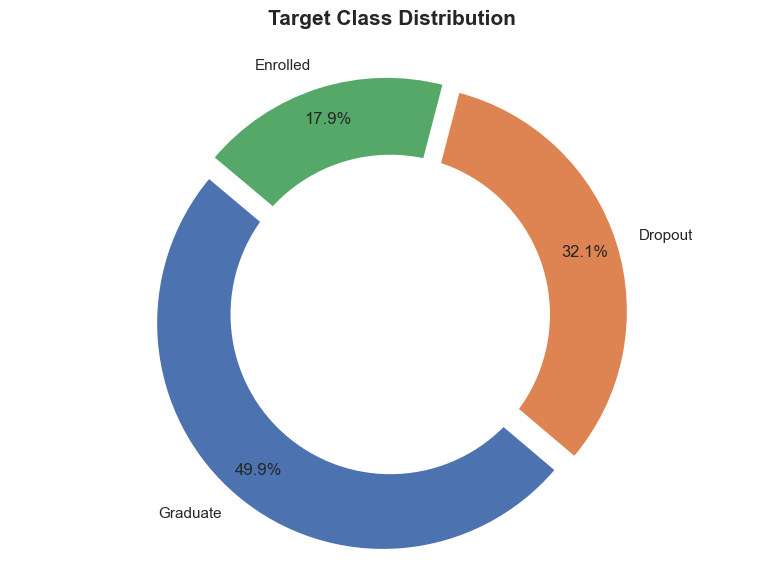

In [106]:

plot = data["Target"].value_counts()

plt.figure(figsize=(8, 6)) 
colors = sns.color_palette('pastel')[0:len(plot)] 

plt.pie(
    plot, 
    labels=plot.index, 
    autopct="%1.1f%%", 
    startangle=140,      
    explode=[0.05] * len(plot), 
    shadow=False,        
    pctdistance=0.85,   
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Garis putih antar potongan
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Target Class Distribution", fontsize=15, pad=20, fontweight='bold')
plt.axis('equal')
plt.tight_layout()

plt.show()

### 2.2 Univariate Numerical Variables

In [107]:
# Kelompok 1: Latar Belakang & Pendaftaran (Karakteristik Mahasiswa saat masuk)
academic_bg_cols = [
    'Application order', 'Previous qualification (grade)', 
    'Admission grade', 'Age at enrollment'
]

# Kelompok 2: Performa Akademik Semester 1
sem1_cols = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)'
]

# Kelompok 3: Performa Akademik Semester 2
sem2_cols = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]

macro_economic_cols = [
    'Unemployment rate', 'Inflation rate', 'GDP'
]


#### academic_bg_cols

##### BOXPLOT

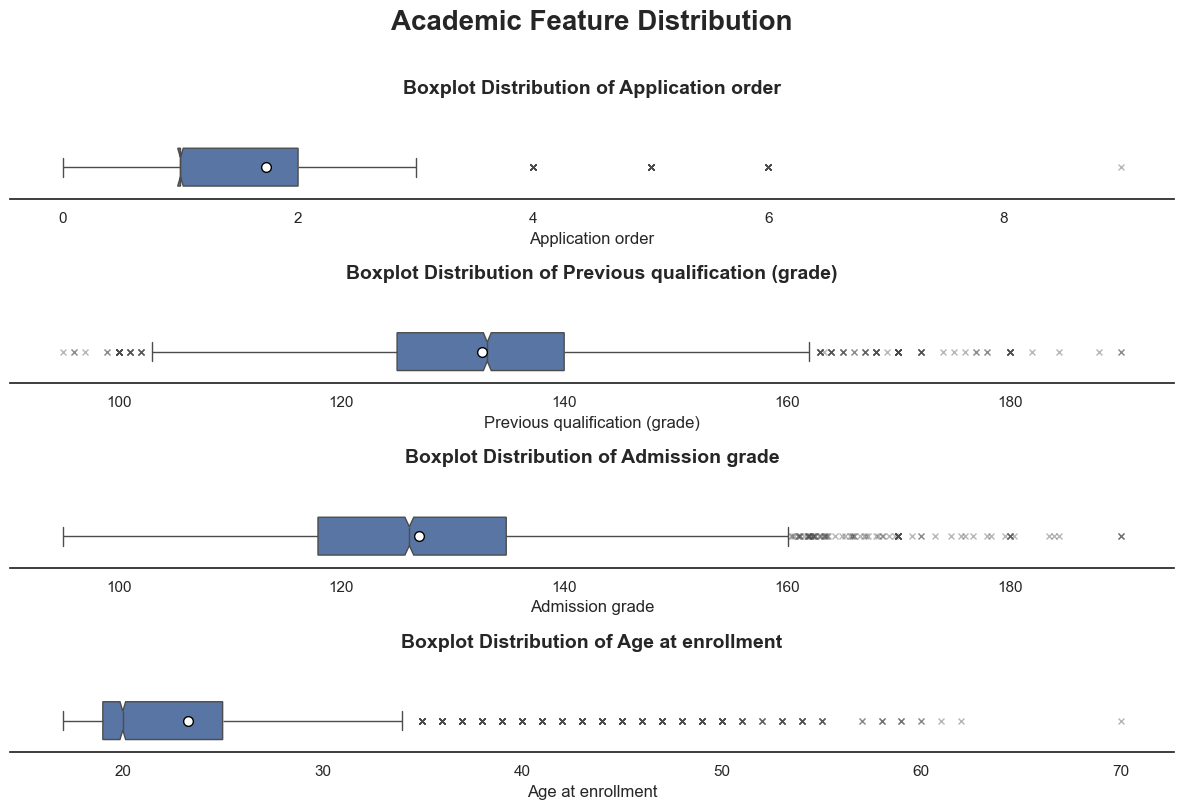

In [108]:
fig, ax = plt.subplots(4,1,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(academic_bg_cols):
    sns.boxplot(data=data, x =col,ax=ax[i], showmeans=True, width=0.6,
                notch = True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"},
                flierprops={"marker": "x", "markersize": 4, "alpha": 0.4})
    ax[i].set_title(f"Boxplot Distribution of {col}\n", fontsize=14, pad=15, fontweight='bold')
    sns.despine(left=True)
    
fig.suptitle("Academic Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()

##### HISTPLOT

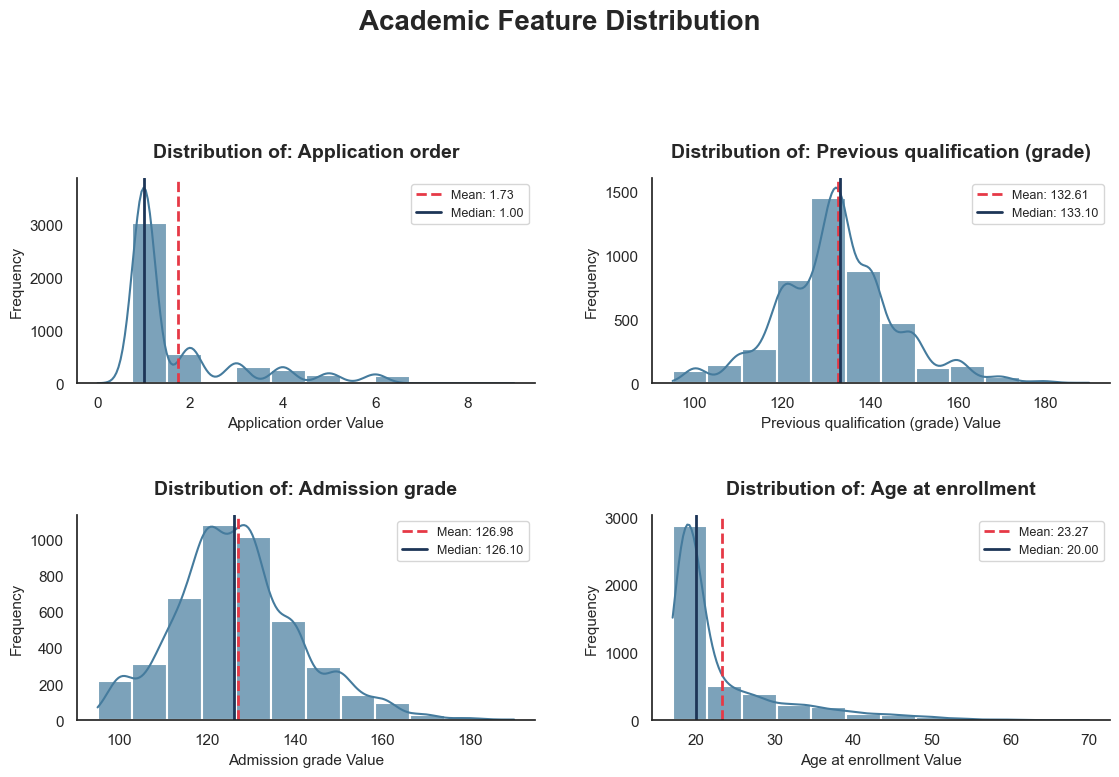

In [109]:
sns.set_theme(style="white")
fig, ax = plt.subplots(2,2,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(academic_bg_cols):
    sns.histplot(
        data=data, x=col, ax=ax[i], bins=12, 
        kde=True, color="#457B9D", alpha=0.7,
        edgecolor='white', linewidth=1.5
    )
    
    mean_val = data[col].mean()
    median_val = data[col].median()
    
    ax[i].axvline(mean_val, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax[i].axvline(median_val, color='#1D3557', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    ax[i].set_title(f"Distribution of: {col}", fontsize=14, fontweight='bold', pad=15)
    ax[i].set_xlabel(f"{col} Value", fontsize=11)
    ax[i].set_ylabel("Frequency", fontsize=11)
    ax[i].legend(loc='upper right', frameon=True, fontsize=9) 
    
    sns.despine(ax=ax[i])

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle("Academic Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.0) 
plt.show()

#### sem1_cols

##### BOXPLOT

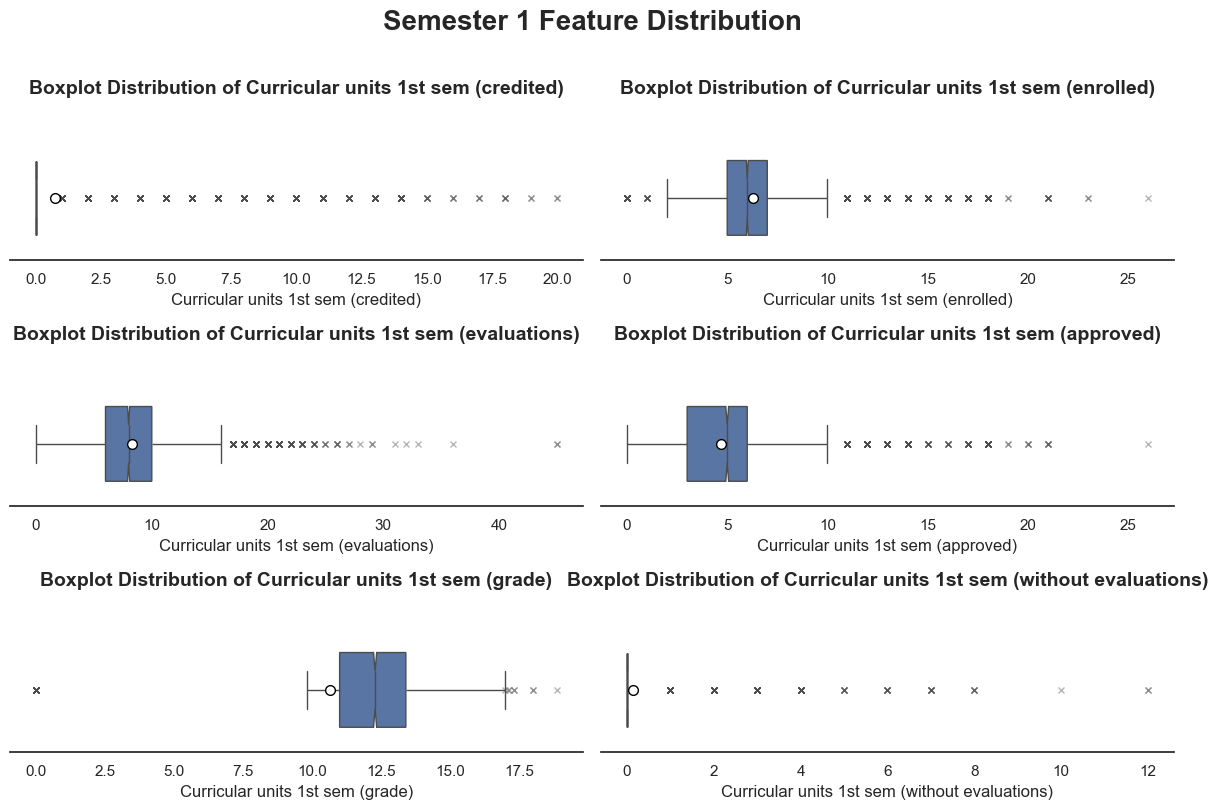

In [110]:
fig, ax = plt.subplots(3,2,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(sem1_cols):
    sns.boxplot(data=data, x =col,ax=ax[i], showmeans=True, width=0.6,
                notch = True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"},
                flierprops={"marker": "x", "markersize": 4, "alpha": 0.4})
    ax[i].set_title(f"Boxplot Distribution of {col}\n", fontsize=14, pad=15, fontweight='bold')
    sns.despine(left=True)

fig.suptitle("Semester 1 Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()

##### HISTPLOT

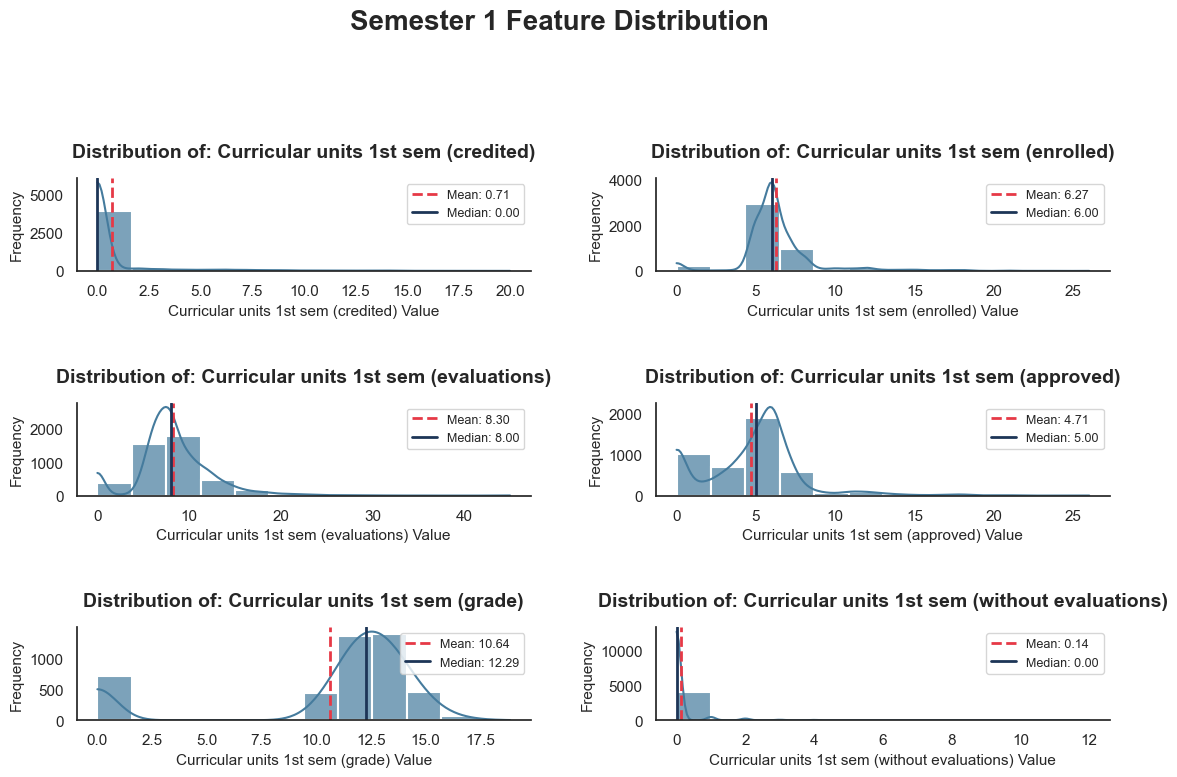

In [111]:
sns.set_theme(style="white")
fig, ax = plt.subplots(3,2,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(sem1_cols):
    sns.histplot(
        data=data, x=col, ax=ax[i], bins=12, 
        kde=True, color="#457B9D", alpha=0.7,
        edgecolor='white', linewidth=1.5
    )
    
    mean_val = data[col].mean()
    median_val = data[col].median()
    
    ax[i].axvline(mean_val, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax[i].axvline(median_val, color='#1D3557', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    ax[i].set_title(f"Distribution of: {col}", fontsize=14, fontweight='bold', pad=15)
    ax[i].set_xlabel(f"{col} Value", fontsize=11)
    ax[i].set_ylabel("Frequency", fontsize=11)
    ax[i].legend(loc='upper right', frameon=True, fontsize=9) 
    
    sns.despine(ax=ax[i])

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle("Semester 1 Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.0) 
plt.show()

#### sem2_cols

##### BOXPLOT

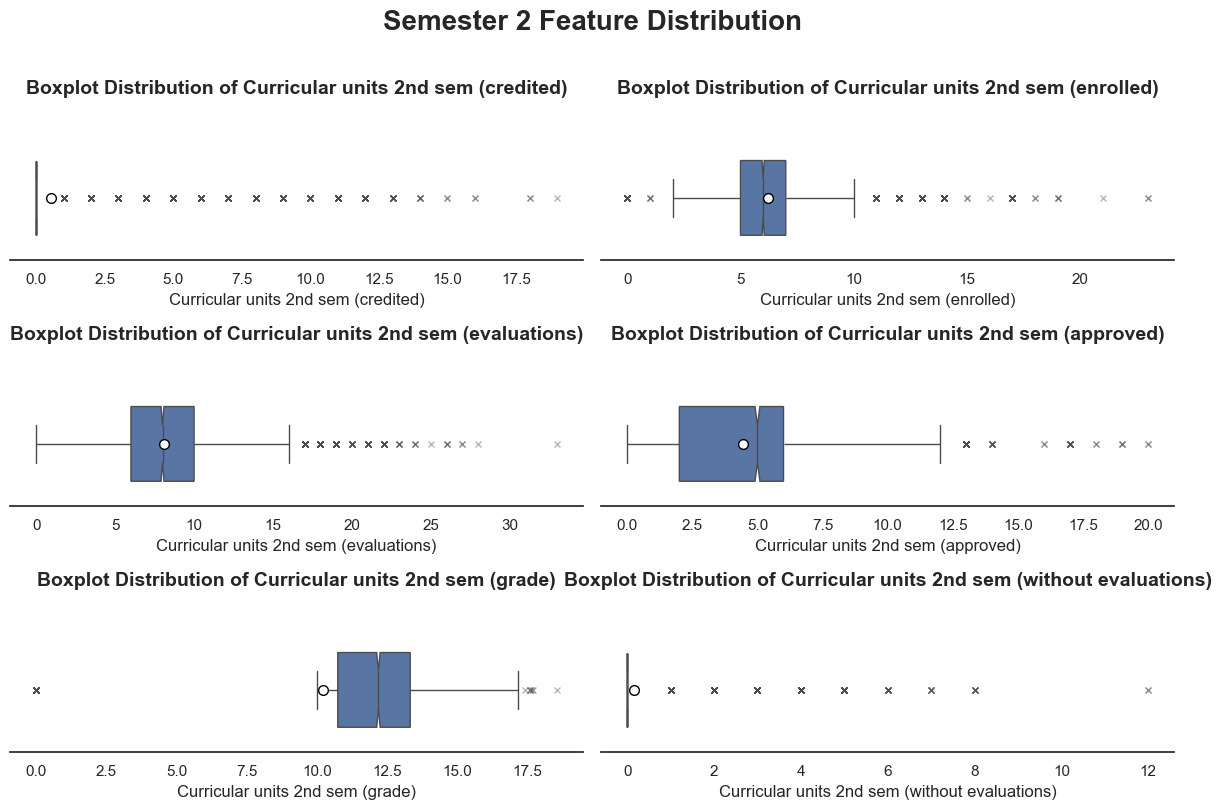

In [112]:
fig, ax = plt.subplots(3,2,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(sem2_cols):
    sns.boxplot(data=data, x =col,ax=ax[i], showmeans=True, width=0.6,
                notch = True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"},
                flierprops={"marker": "x", "markersize": 4, "alpha": 0.4})
    ax[i].set_title(f"Boxplot Distribution of {col}\n", fontsize=14, pad=15, fontweight='bold')
    sns.despine(left=True)

fig.suptitle("Semester 2 Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()

##### HISTPLOT

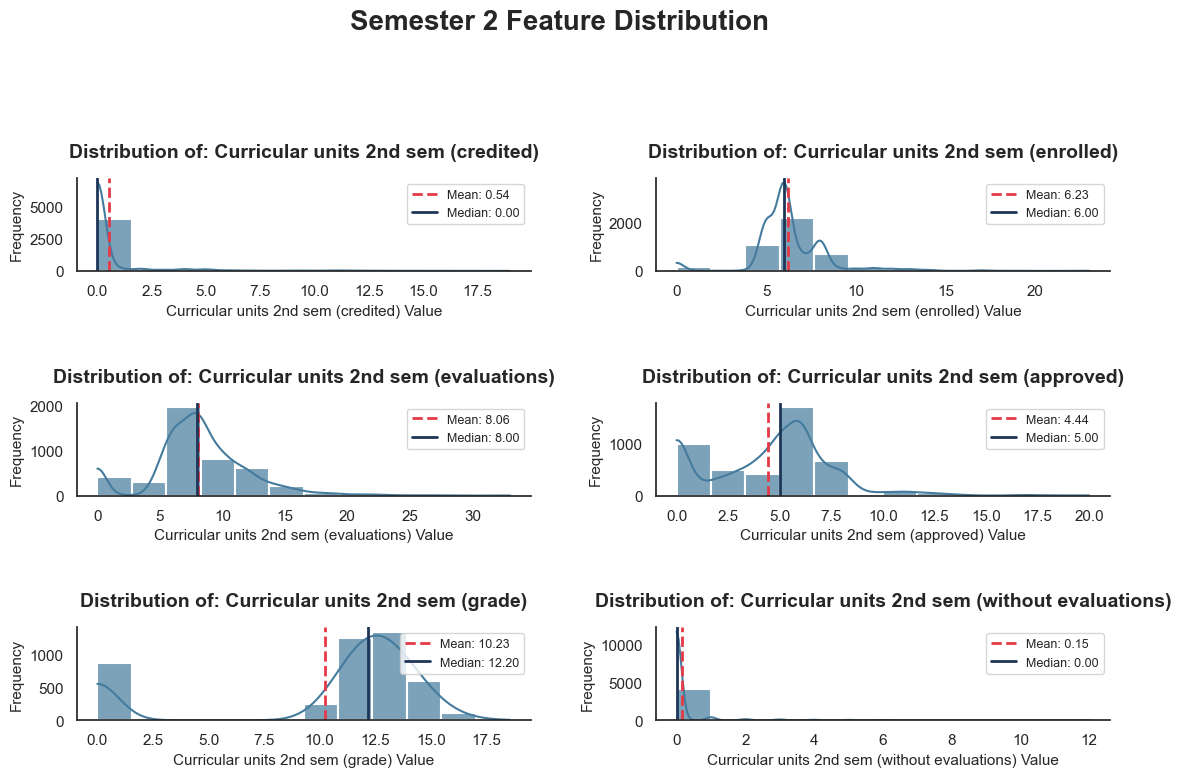

In [113]:
sns.set_theme(style="white")
fig, ax = plt.subplots(3,2,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(sem2_cols):
    sns.histplot(
        data=data, x=col, ax=ax[i], bins=12, 
        kde=True, color="#457B9D", alpha=0.7,
        edgecolor='white', linewidth=1.5
    )
    
    mean_val = data[col].mean()
    median_val = data[col].median()
    
    ax[i].axvline(mean_val, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax[i].axvline(median_val, color='#1D3557', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    ax[i].set_title(f"Distribution of: {col}", fontsize=14, fontweight='bold', pad=15)
    ax[i].set_xlabel(f"{col} Value", fontsize=11)
    ax[i].set_ylabel("Frequency", fontsize=11)
    ax[i].legend(loc='upper right', frameon=True, fontsize=9) 
    
    sns.despine(ax=ax[i])

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle("Semester 2 Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.0) 
plt.show()

#### macro_economic_cols

##### BOXPLOT

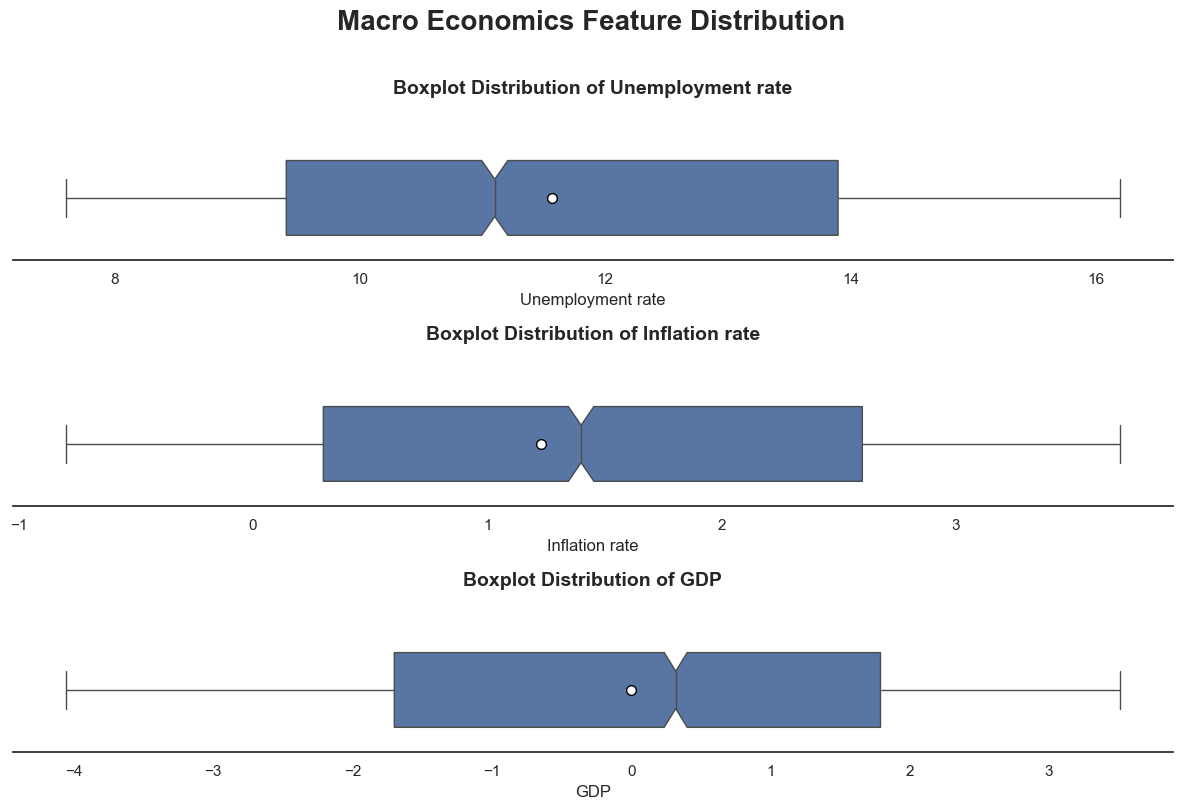

In [114]:
fig, ax = plt.subplots(3,1,figsize=(12,8))
ax = ax.flatten()

for i, col in enumerate(macro_economic_cols):
    sns.boxplot(data=data, x =col,ax=ax[i], showmeans=True, width=0.6,
                notch = True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"},
                flierprops={"marker": "x", "markersize": 4, "alpha": 0.4})
    ax[i].set_title(f"Boxplot Distribution of {col}\n", fontsize=14, pad=15, fontweight='bold')
    sns.despine(left=True)

fig.suptitle("Macro Economics Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()

##### HISTPLOT

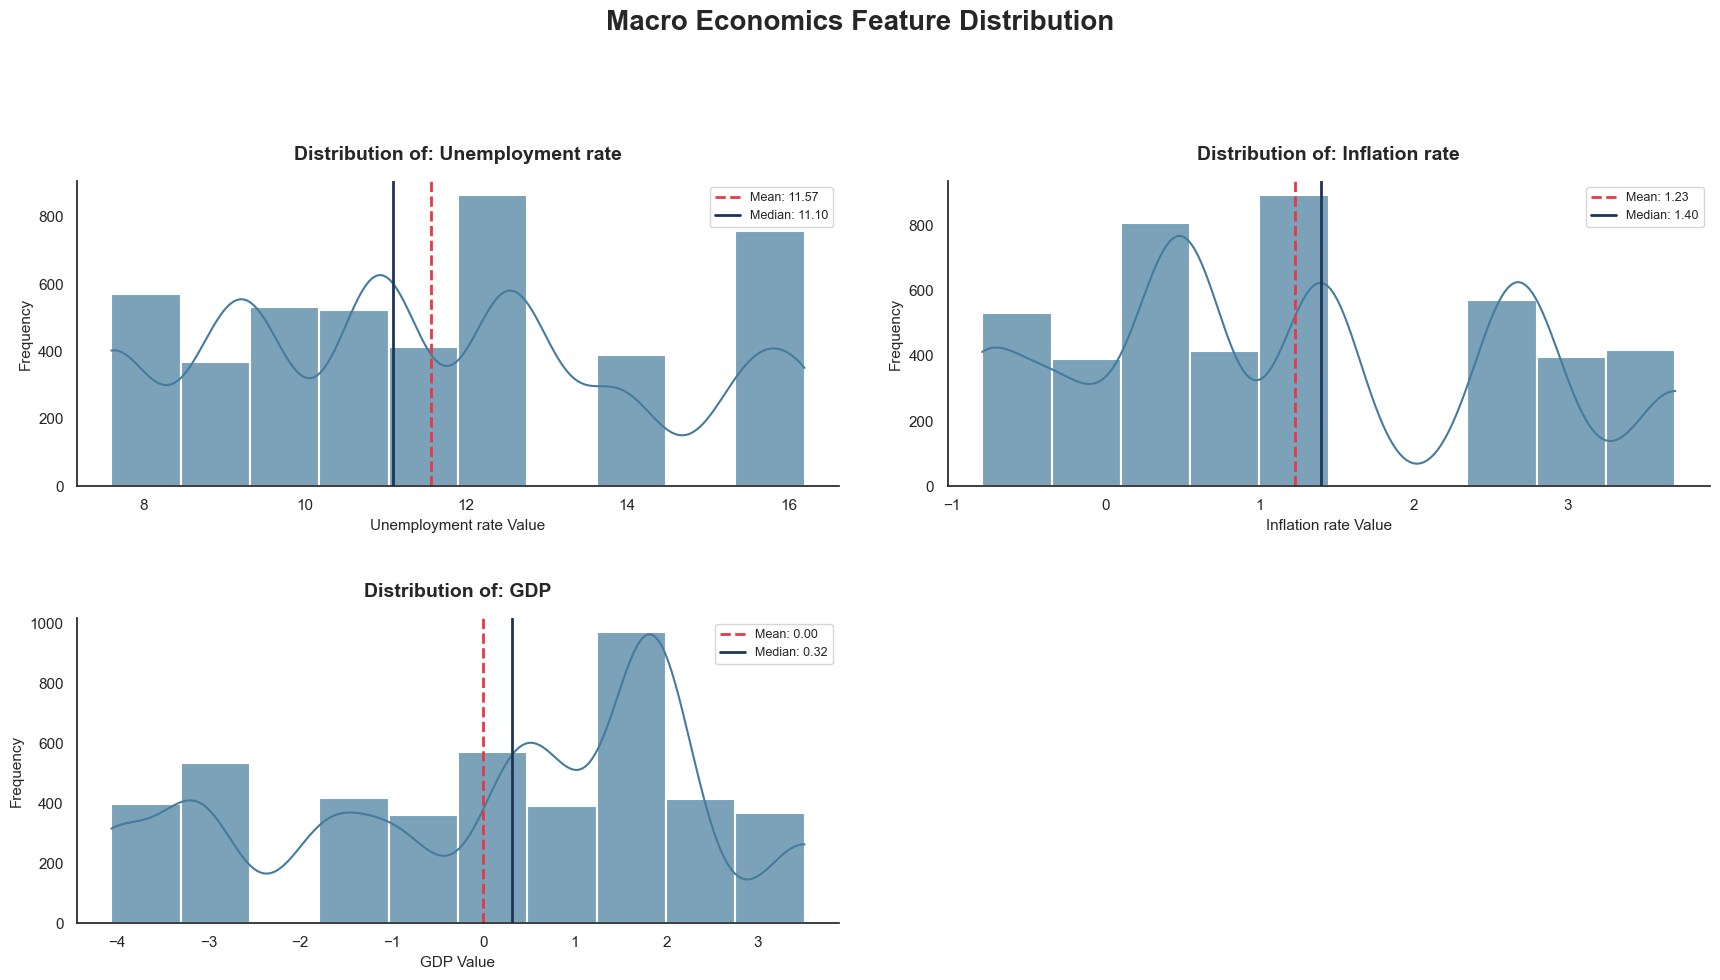

In [115]:
sns.set_theme(style="white")
fig, ax = plt.subplots(2,2,figsize=(18,10))
ax = ax.flatten()

for i, col in enumerate(macro_economic_cols):
    sns.histplot(
        data=data, x=col, ax=ax[i], bins=10, 
        kde=True, color="#457B9D", alpha=0.7,
        edgecolor='white', linewidth=1.5
    )
    
    mean_val = data[col].mean()
    median_val = data[col].median()
    
    ax[i].axvline(mean_val, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax[i].axvline(median_val, color='#1D3557', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    ax[i].set_title(f"Distribution of: {col}", fontsize=14, fontweight='bold', pad=15)
    ax[i].set_xlabel(f"{col} Value", fontsize=11)
    ax[i].set_ylabel("Frequency", fontsize=11)
    ax[i].legend(loc='upper right', frameon=True, fontsize=9) 
    
    sns.despine(ax=ax[i])

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle("Macro Economics Feature Distribution", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.0) 
plt.show()

### 2.3 Univariate Categorical Variables

In [116]:
for col in cat_cols:
    print(f"Total N unique {col}: {data[col].nunique()}")

Total N unique Marital status: 6
Total N unique Application mode: 18
Total N unique Course: 17
Total N unique Daytime/evening attendance: 2
Total N unique Previous qualification: 17
Total N unique Nacionality: 21
Total N unique Mother's qualification: 29
Total N unique Father's qualification: 34
Total N unique Mother's occupation: 32
Total N unique Father's occupation: 46
Total N unique Displaced: 2
Total N unique Educational special needs: 2
Total N unique Debtor: 2
Total N unique Tuition fees up to date: 2
Total N unique Gender: 2
Total N unique Scholarship holder: 2
Total N unique International: 2


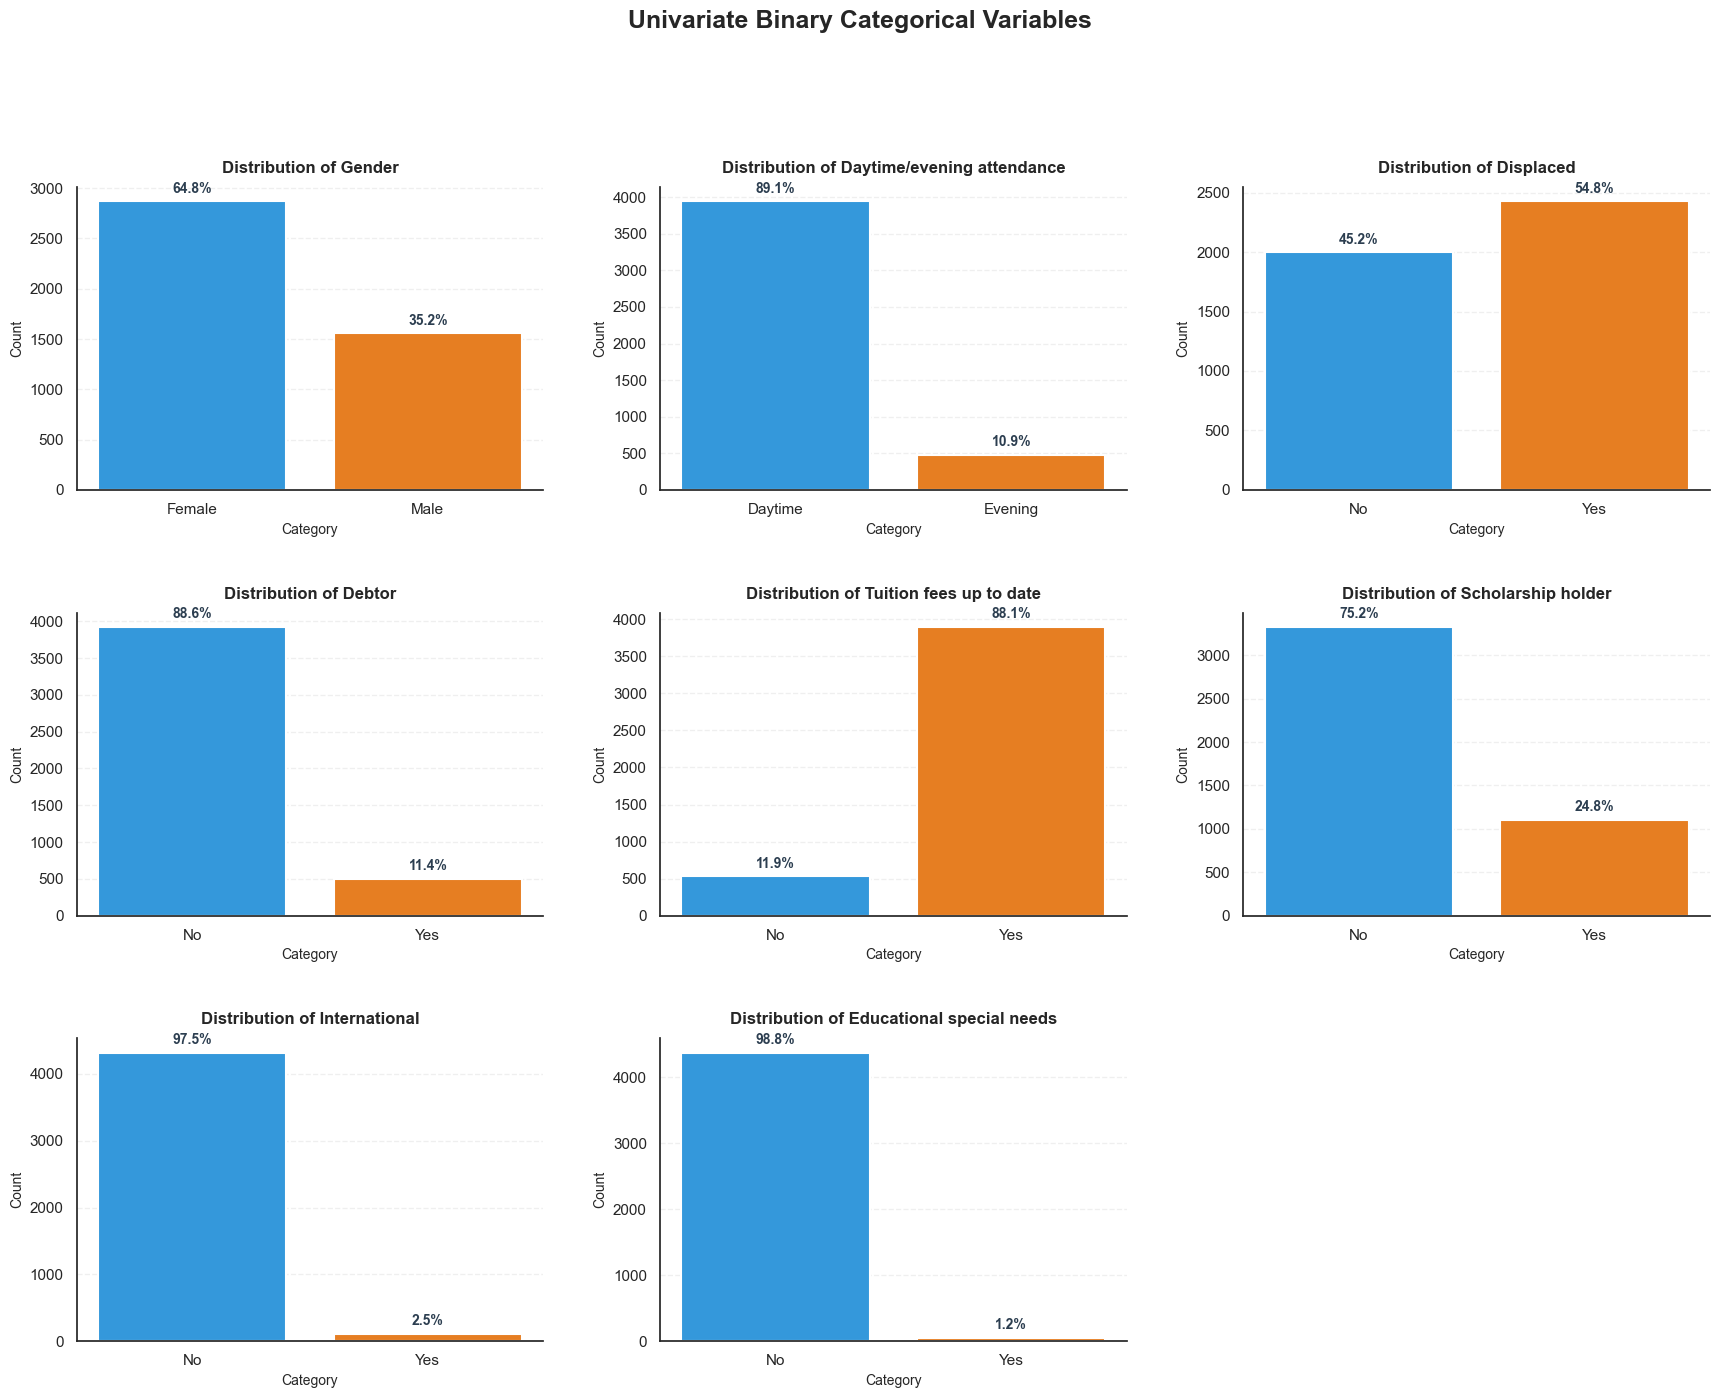

In [117]:
import matplotlib.pyplot as plt

binary_vars = ['Gender', 'Daytime/evening attendance', 'Displaced', 'Debtor',
               'Tuition fees up to date', 'Scholarship holder', 'International',
               'Educational special needs']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(binary_vars):
    counts = data[col].value_counts().sort_index() 
    pcts = counts / counts.sum() * 100

    bars = axes[i].bar(counts.index.astype(str), counts.values, 
                       color=['#3498db', '#e67e22'], 
                       edgecolor='white', linewidth=1.5)
    
    for bar, pct in zip(bars, pcts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (counts.max() * 0.02),
                     f'{pct:.1f}%', ha='center', va='bottom', 
                     fontsize=10, fontweight='bold', color='#2c3e50')

    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].set_xlabel('Category', fontsize=10)

    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3) 

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Univariate Binary Categorical Variables', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout(pad=3.0)
plt.show()

### 2.4 Univariate High-Cardinality Categorical Variables

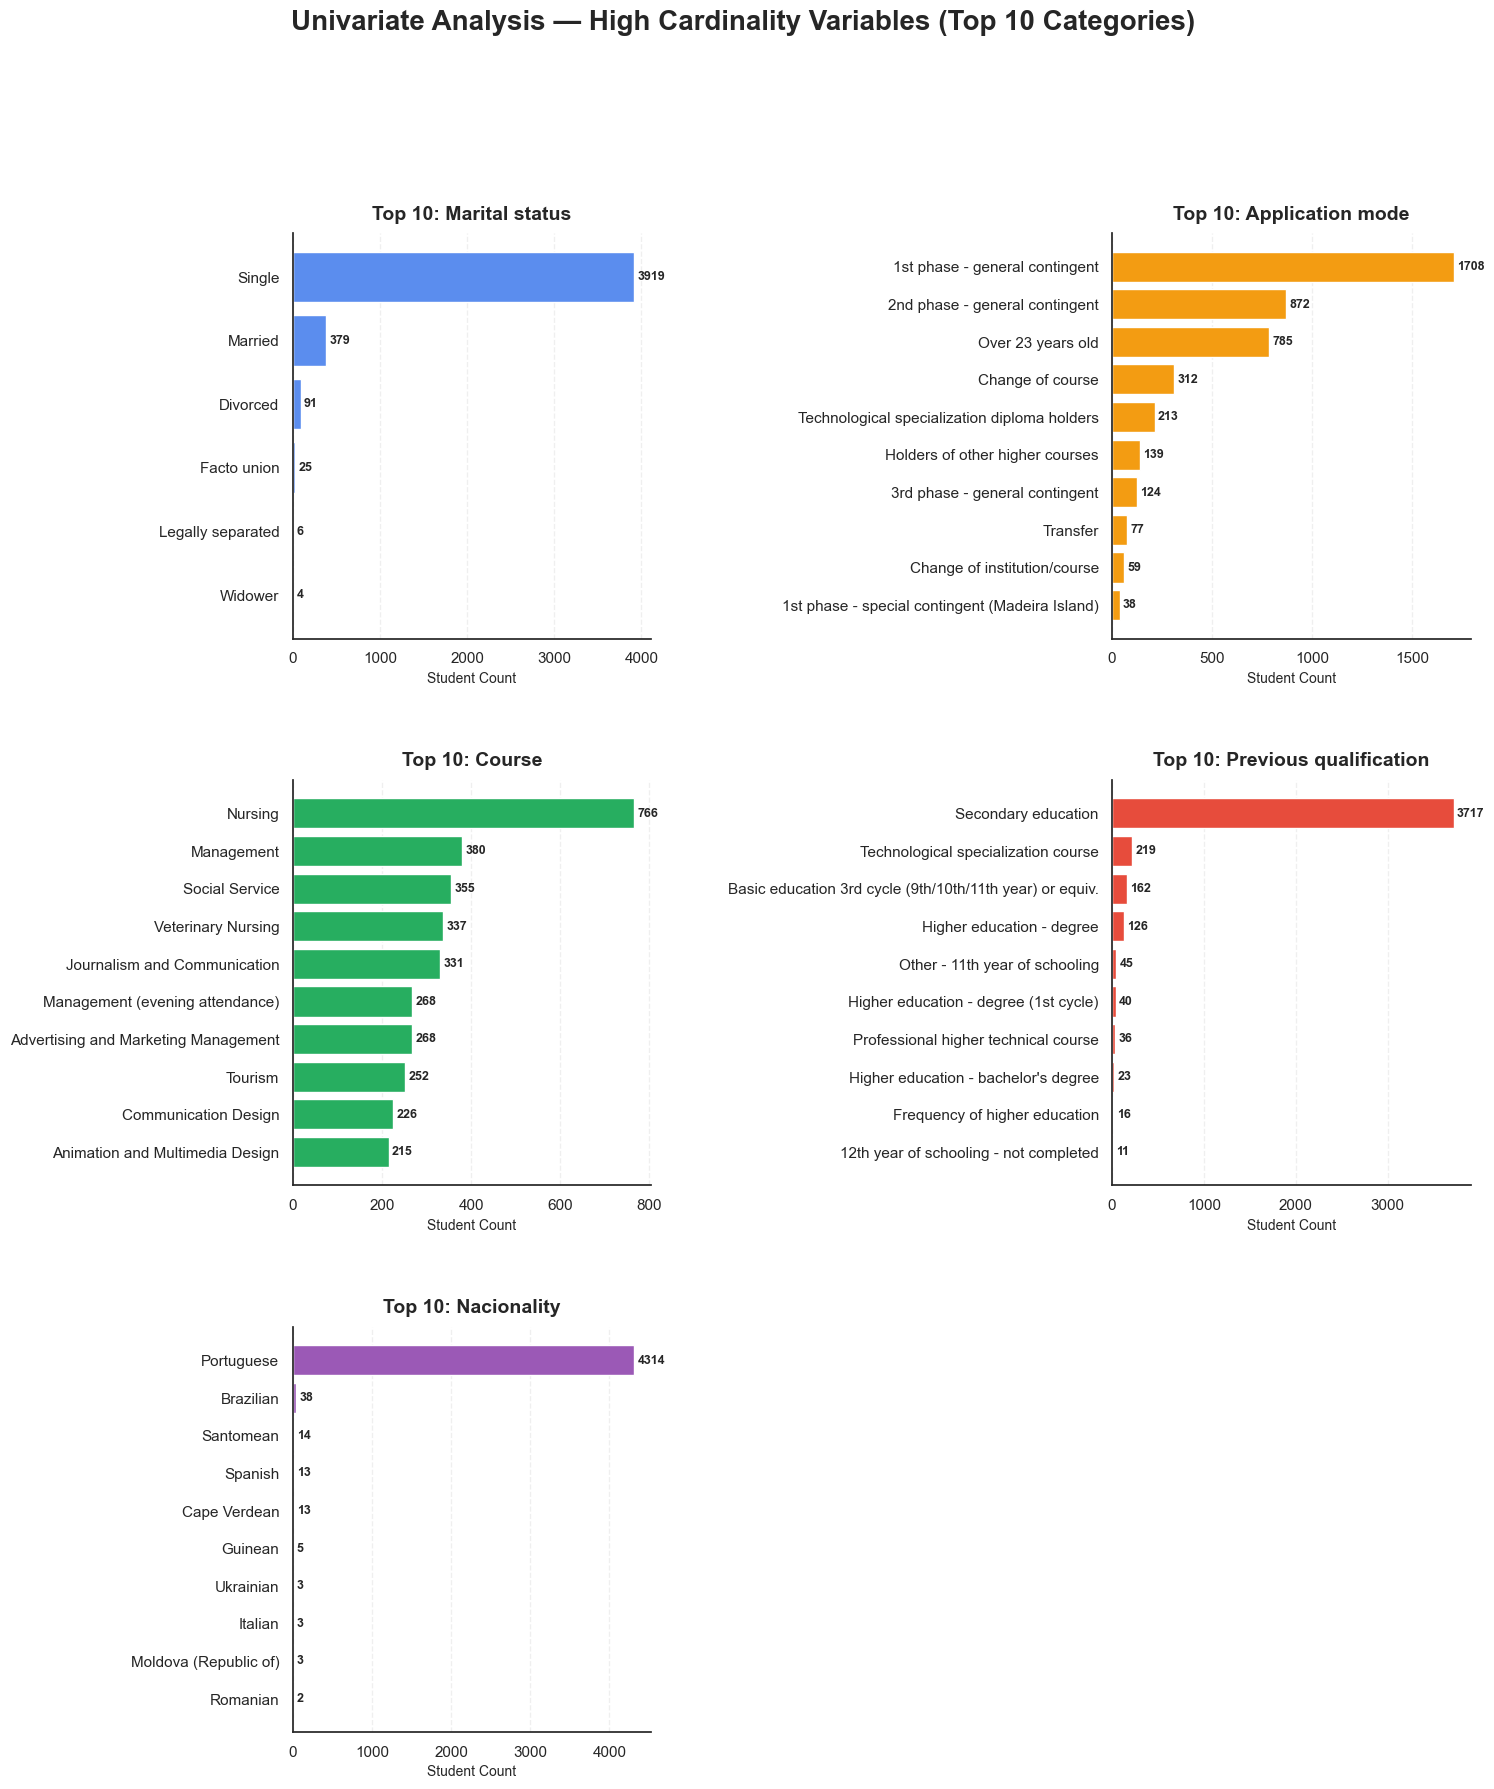

In [118]:
high_card_vars = [
    'Marital status', 'Application mode', 'Course', 
    'Previous qualification', 'Nacionality'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Palet warna agar tidak membosankan
colors = ['#5b8dee', '#f39c12', '#27ae60', '#e74c3c', '#9b59b6', '#1abc9c', '#34495e', '#d35400', '#7f8c8d']

for i, col in enumerate(high_card_vars):
    
    counts = data[col].value_counts().head(10)
    
    bars = axes[i].barh(counts.index.astype(str), counts.values, 
                        color=colors[i % len(colors)], edgecolor='white')
    
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + (counts.max() * 0.01), 
                     bar.get_y() + bar.get_height()/2,
                     f'{int(width)}', 
                     va='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'Top 10: {col}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Student Count', fontsize=10)
    axes[i].invert_yaxis()
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Univariate Analysis — High Cardinality Variables (Top 10 Categories)', 
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout(pad=4.0)
plt.show()

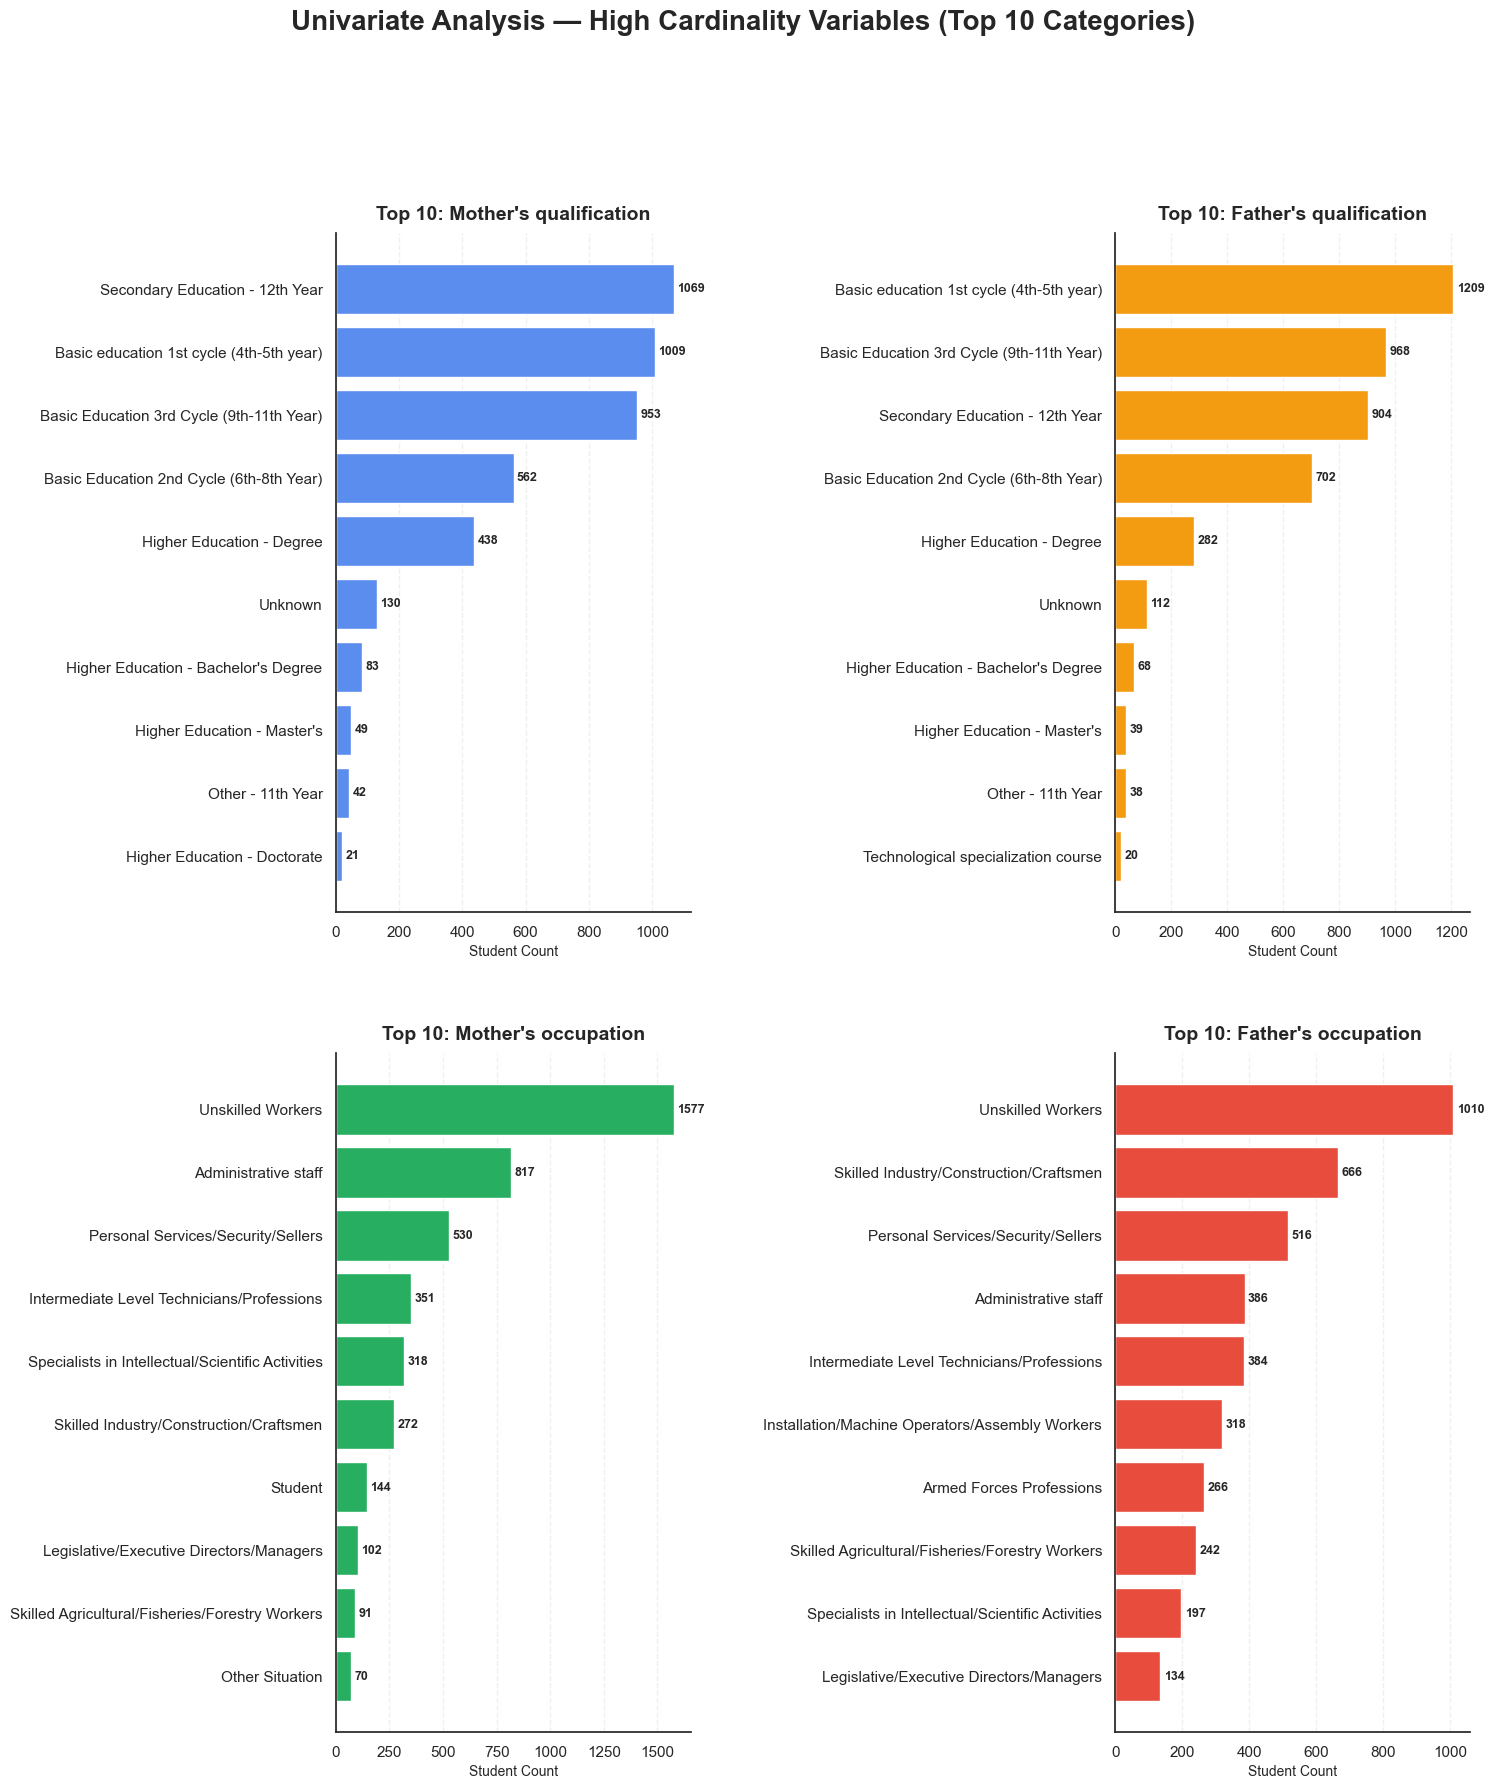

In [119]:
high_card_vars = [
   "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

colors = ['#5b8dee', '#f39c12', '#27ae60', '#e74c3c', '#9b59b6', '#1abc9c', '#34495e', '#d35400', '#7f8c8d']

for i, col in enumerate(high_card_vars):
    
    counts = data[col].value_counts().head(10)
    
    bars = axes[i].barh(counts.index.astype(str), counts.values, 
                        color=colors[i % len(colors)], edgecolor='white')
    
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + (counts.max() * 0.01), 
                     bar.get_y() + bar.get_height()/2,
                     f'{int(width)}', 
                     va='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'Top 10: {col}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Student Count', fontsize=10)
    axes[i].invert_yaxis()
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Univariate Analysis — High Cardinality Variables (Top 10 Categories)', 
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout(pad=4.0)
plt.show()

---
## 3. High Cardinality Categorial Data Correlation with Target

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\2132816528.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


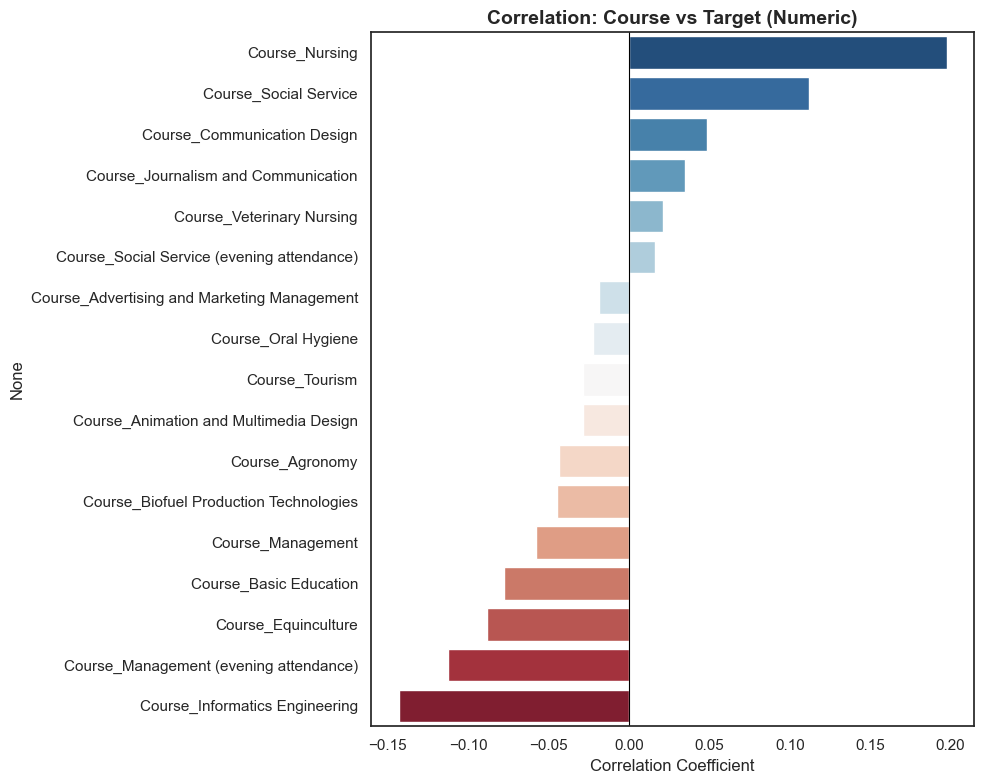

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pilih kolom
target_col = 'Target'
col_to_check = 'Course'

# 2. PAKSA konversi Target ke angka (Mapping Manual agar aman)
# Kita buat dictionary mapping: Dropout jadi 0, sisanya (Graduate/Enrolled) jadi 1 & 2
# Atau jika ingin biner, sesuaikan mappingnya
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
data_numeric_target = data[target_col].map(target_mapping)

# 3. Buat dummies (Gunakan dtype=int agar tidak ada data teks di sini)
dummies = pd.get_dummies(data[col_to_check], prefix=col_to_check, dtype=int)

# 4. Gabungkan (Gunakan dataframe baru agar data asli tidak rusak)
df_breakdown = pd.concat([data_numeric_target, dummies], axis=1)

# 5. Hitung korelasi dengan numeric_only=True sebagai pengaman tambahan
breakdown_corr = df_breakdown.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 6. Visualisasi
plt.figure(figsize=(10, 8))

# Hapus baris target itu sendiri agar tidak muncul korelasi 1.0
plot_data = breakdown_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: {col_to_check} vs {target_col} (Numeric)", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\4216969970.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


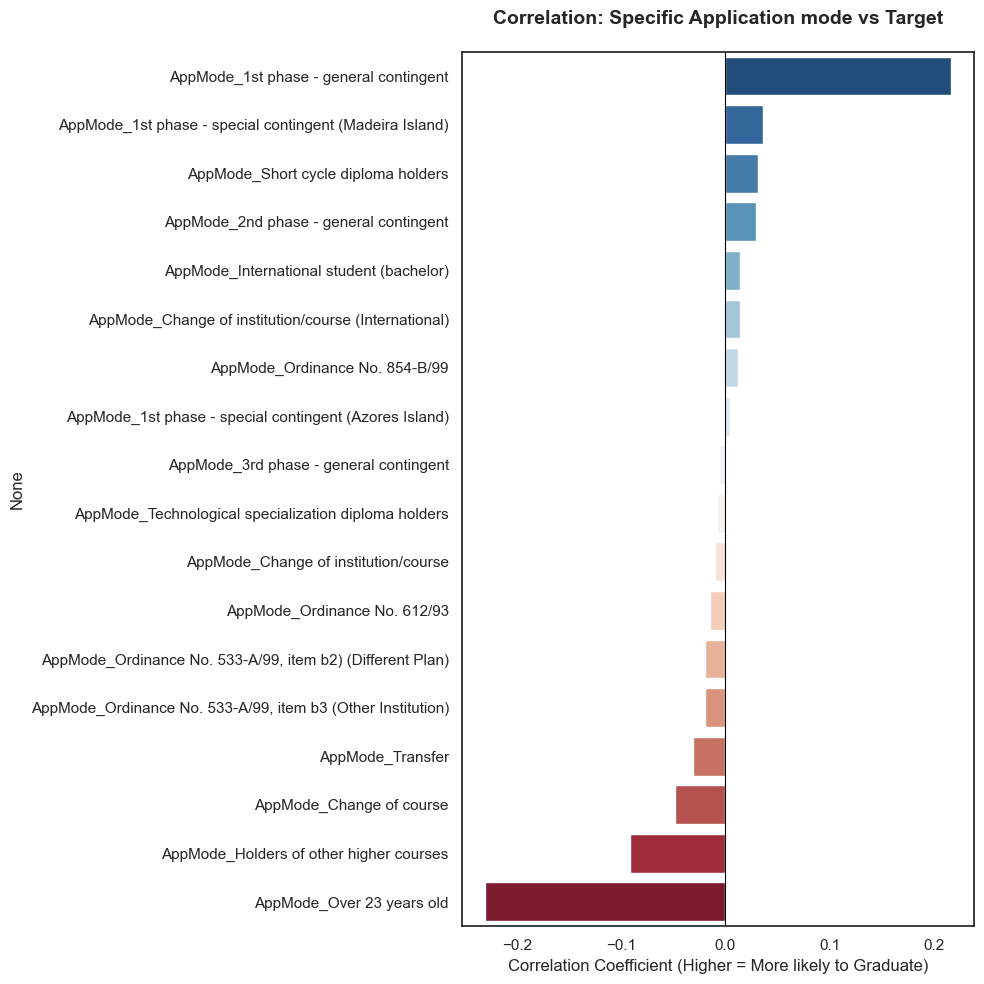

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Konfigurasi Kolom
target_col = 'Target'
col_to_check = 'Application mode'

# 2. Pastikan Target adalah Numerik (0: Dropout, 1: Enrolled, 2: Graduate)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
# Menggunakan .map() pada series sementara agar data asli tetap aman jika ingin diulang
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies untuk Application Mode (Gunakan top 10 atau semua)
# Kita gunakan dtype=int untuk memastikan tidak ada nilai boolean/string
dummies = pd.get_dummies(data[col_to_check], prefix='AppMode', dtype=int)

# 4. Gabungkan Target dan Dummies
df_app_mode = pd.concat([numeric_target, dummies], axis=1)

# 5. Hitung Korelasi
# numeric_only=True menjamin hanya angka yang diproses
app_mode_corr = df_app_mode.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 6. Visualisasi Bar Plot
plt.figure(figsize=(10, 10))

# Hapus baris target itu sendiri dari plot
plot_data = app_mode_corr.drop(target_col)

# Gunakan warna diverging (RdBu_r) untuk membedakan korelasi positif dan negatif
sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold', pad=20)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Higher = More likely to Graduate)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\1241105385.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


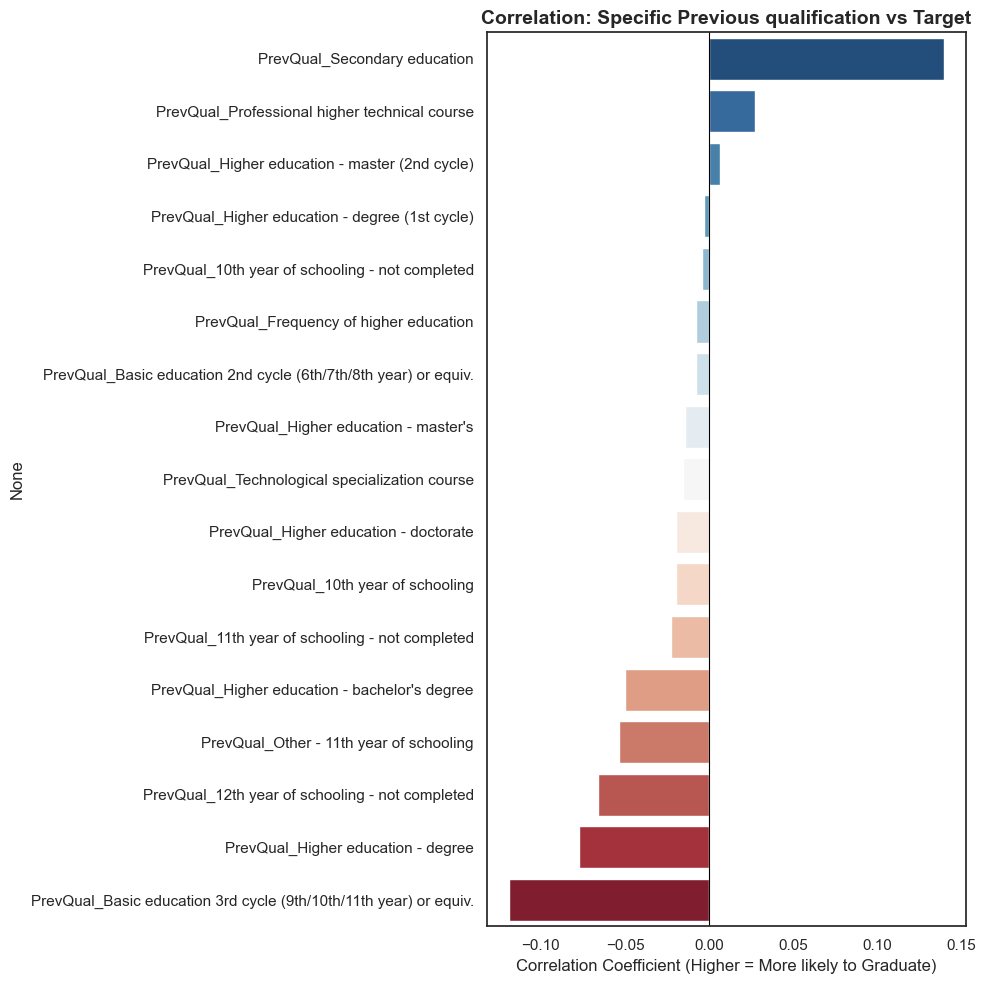

In [122]:

# 1. Konfigurasi
target_col = 'Target'
col_to_check = 'Previous qualification'

# 2. Mapping Target (Pastikan numerik)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies
dummies = pd.get_dummies(data[col_to_check], prefix='PrevQual', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_prev_qual = pd.concat([numeric_target, dummies], axis=1)
prev_qual_corr = df_prev_qual.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi
plt.figure(figsize=(10, 10))
plot_data = prev_qual_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Higher = More likely to Graduate)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\1414486593.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


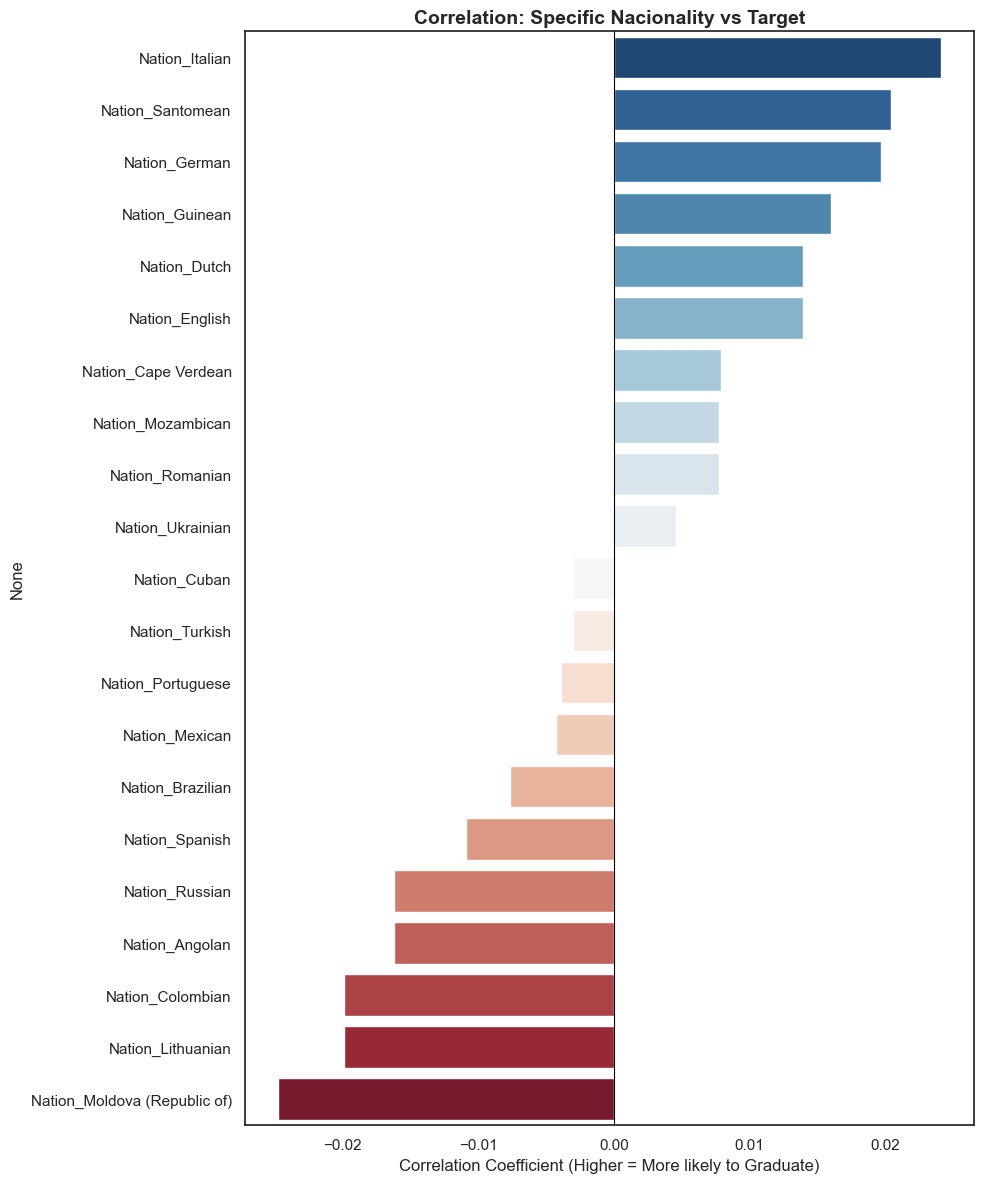

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Konfigurasi
target_col = 'Target'
col_to_check = 'Nacionality'

# 2. Mapping Target (Pastikan numerik)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies
dummies = pd.get_dummies(data[col_to_check], prefix='Nation', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_nation = pd.concat([numeric_target, dummies], axis=1)
nation_corr = df_nation.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi
plt.figure(figsize=(10, 12))
plot_data = nation_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Higher = More likely to Graduate)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\3671790476.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


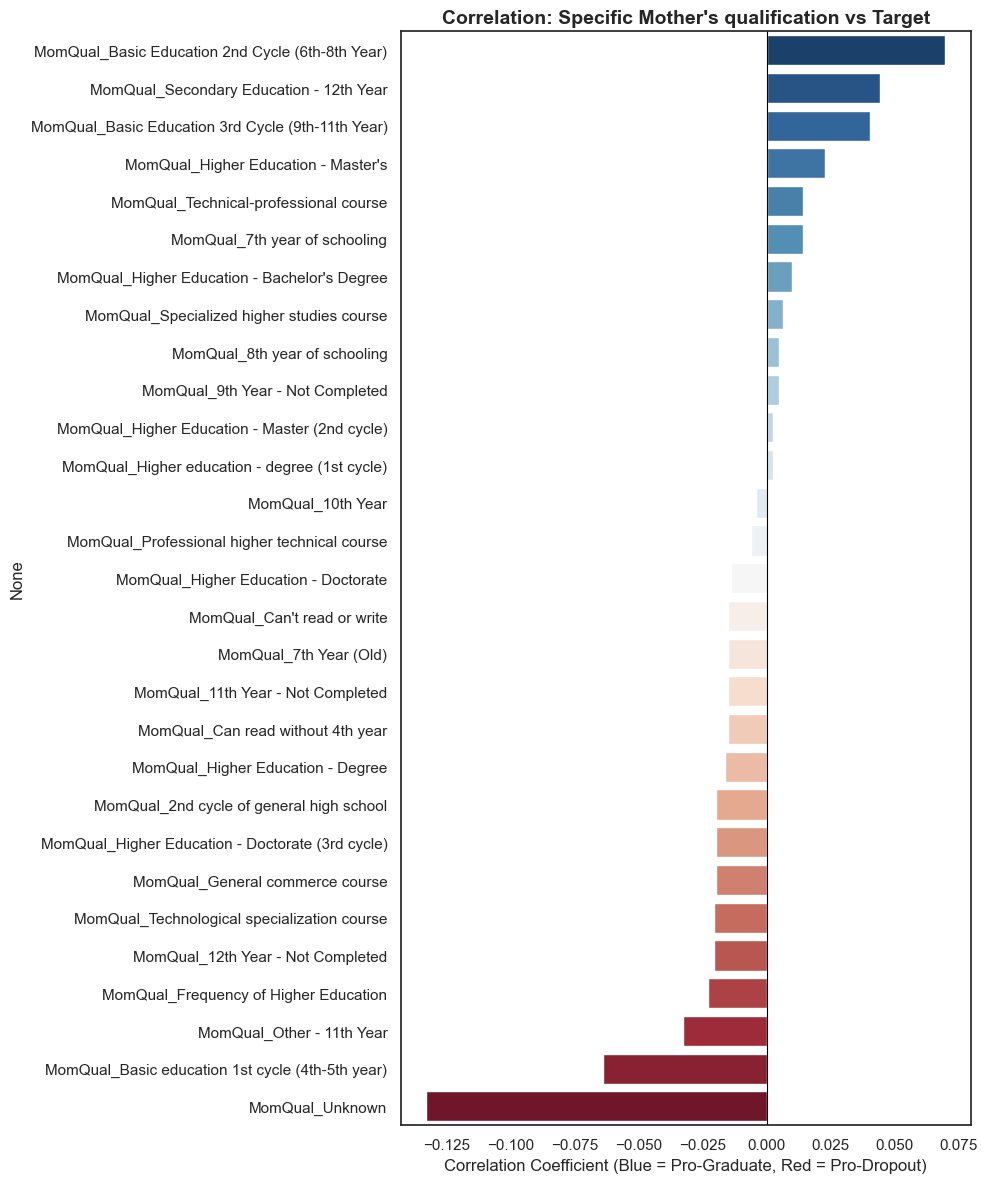

In [124]:

# 1. Konfigurasi
target_col = 'Target'
col_to_check = "Mother's qualification"

# 2. Mapping Target (Pastikan numerik)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies
dummies = pd.get_dummies(data[col_to_check], prefix='MomQual', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_mom_qual = pd.concat([numeric_target, dummies], axis=1)
mom_qual_corr = df_mom_qual.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi Bar Plot
plt.figure(figsize=(10, 12))
plot_data = mom_qual_corr.drop(target_col)

# Menggunakan palette RdBu_r agar korelasi positif (biru) dan negatif (merah) terlihat jelas
sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Blue = Pro-Graduate, Red = Pro-Dropout)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\4101371129.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


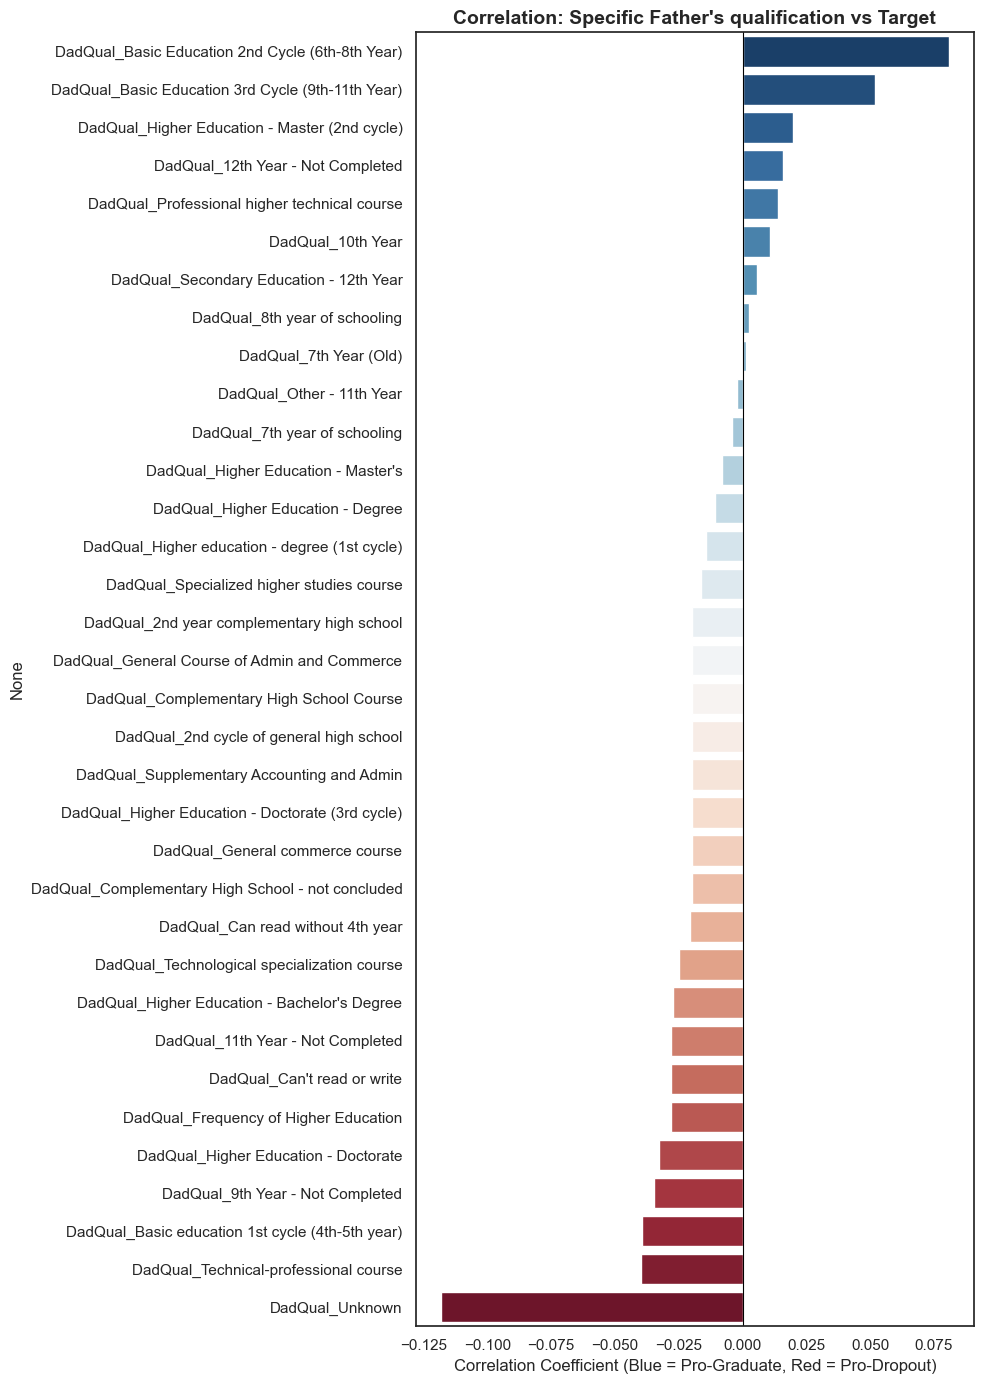

In [125]:


# 1. Konfigurasi
target_col = 'Target'
col_to_check = "Father's qualification"

# 2. Mapping Target (Numerik: 0=Dropout, 1=Enrolled, 2=Graduate)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies
dummies = pd.get_dummies(data[col_to_check], prefix='DadQual', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_dad_qual = pd.concat([numeric_target, dummies], axis=1)
dad_qual_corr = df_dad_qual.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi Bar Plot
plt.figure(figsize=(10, 14)) # Tinggi ditambah karena ada 34 kategori
plot_data = dad_qual_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Blue = Pro-Graduate, Red = Pro-Dropout)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\360065231.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


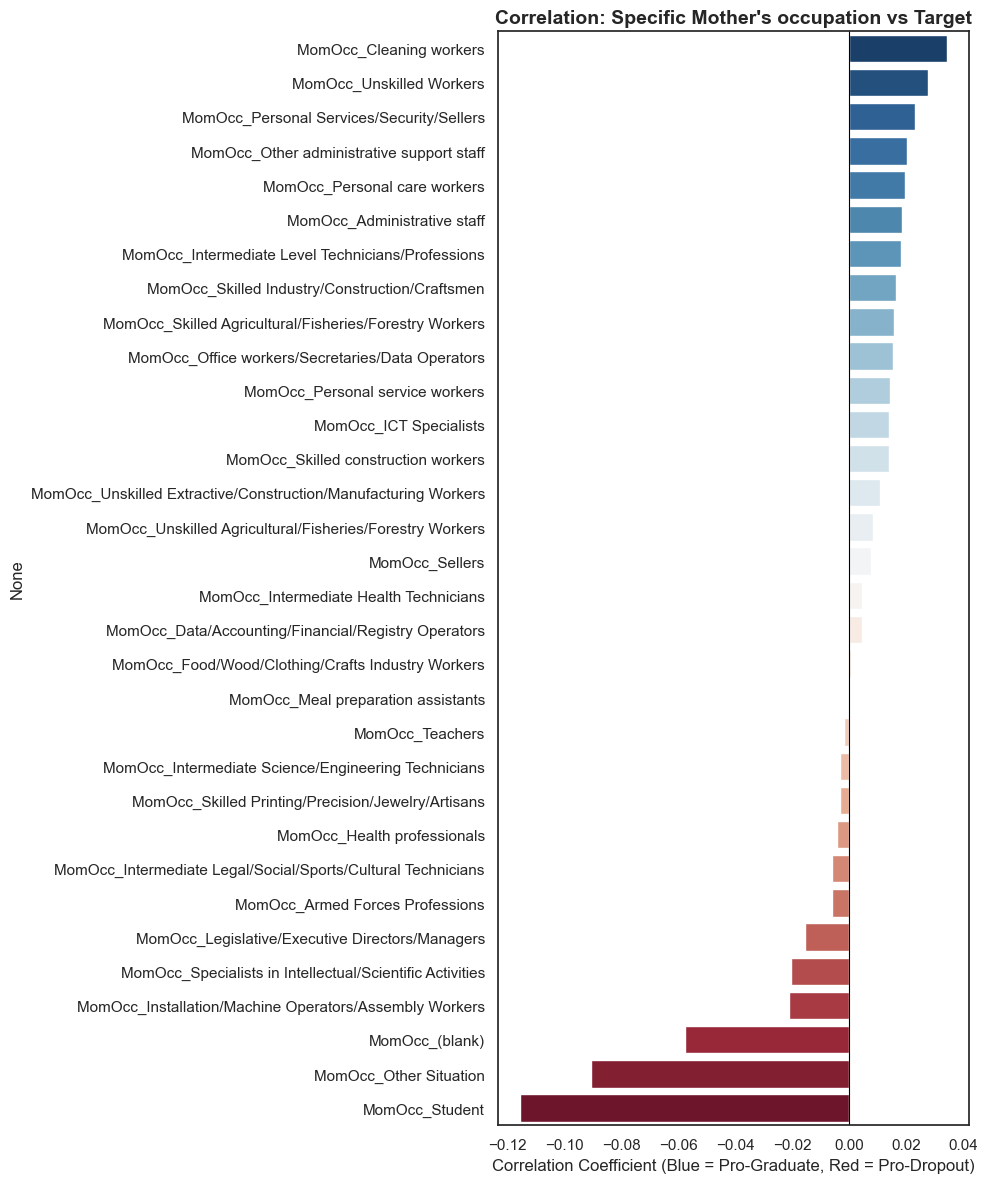

In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Konfigurasi
target_col = 'Target'
col_to_check = "Mother's occupation"

# 2. Mapping Target (0=Dropout, 1=Enrolled, 2=Graduate)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies
dummies = pd.get_dummies(data[col_to_check], prefix='MomOcc', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_mom_occ = pd.concat([numeric_target, dummies], axis=1)
mom_occ_corr = df_mom_occ.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi Bar Plot
plt.figure(figsize=(10, 12))
plot_data = mom_occ_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Blue = Pro-Graduate, Red = Pro-Dropout)")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\1563052540.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')


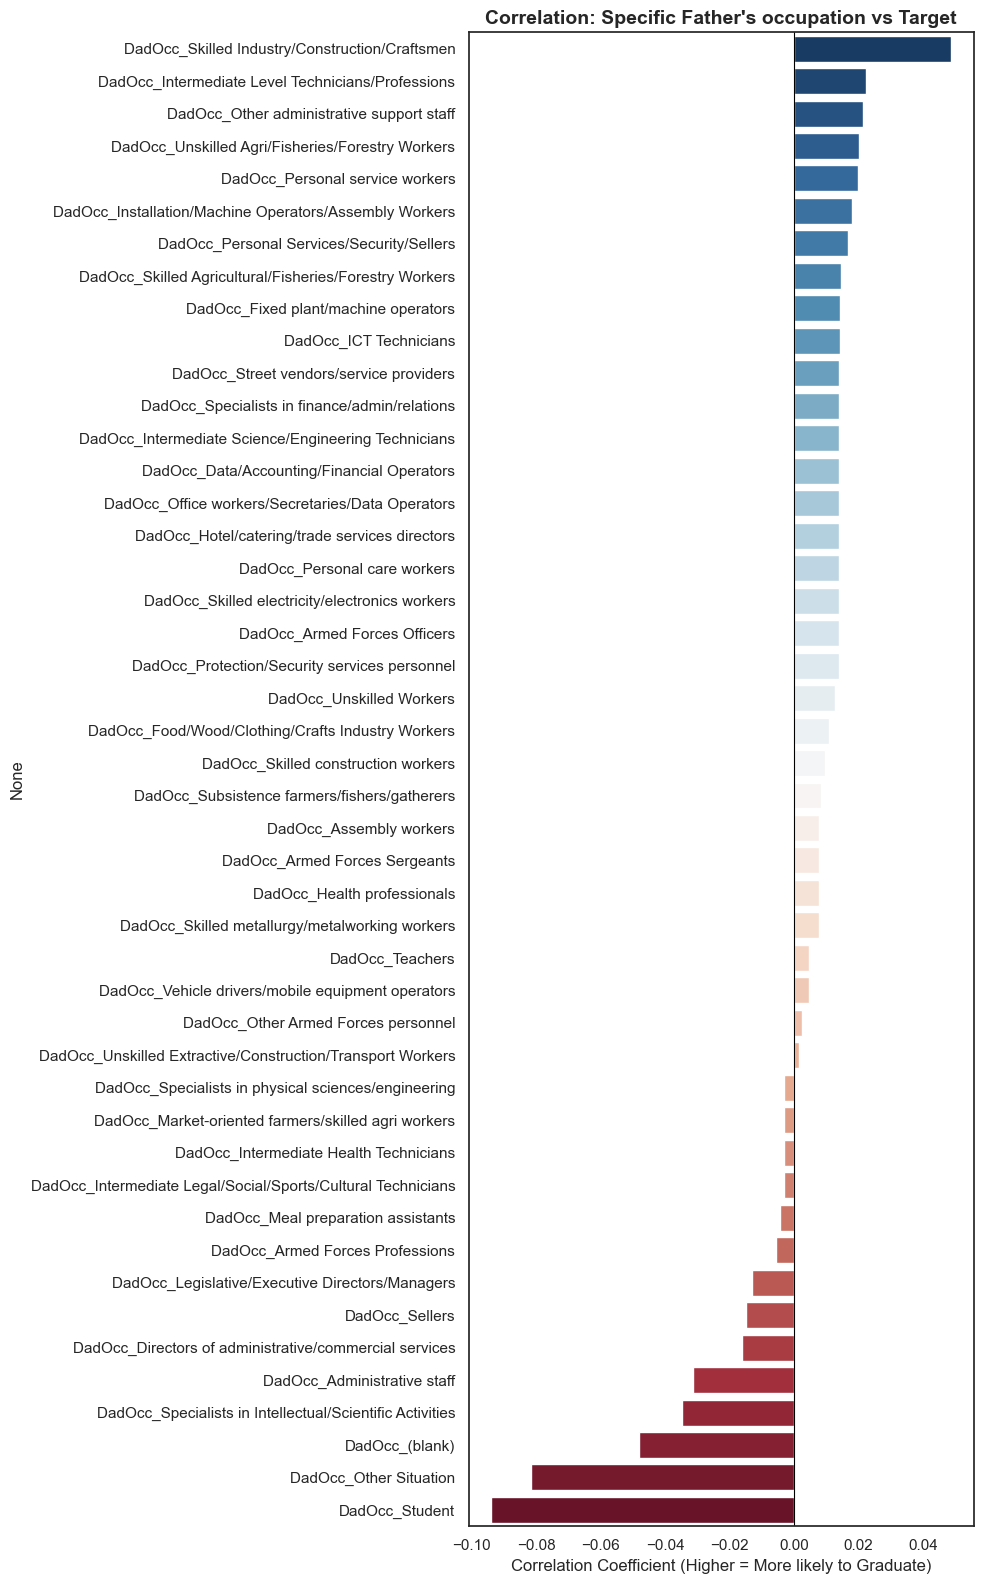

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Konfigurasi
target_col = 'Target'
col_to_check = "Father's occupation"

# 2. Mapping Target ke Numerik (0: Dropout, 1: Enrolled, 2: Graduate)
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
numeric_target = data[target_col].map(target_mapping)

# 3. Buat Dummies (Gunakan dtype=int agar aman dari error)
dummies = pd.get_dummies(data[col_to_check], prefix='DadOcc', dtype=int)

# 4. Gabungkan dan Hitung Korelasi
df_dad_occ = pd.concat([numeric_target, dummies], axis=1)
dad_occ_corr = df_dad_occ.corr(numeric_only=True)[target_col].sort_values(ascending=False)

# 5. Visualisasi Bar Plot
plt.figure(figsize=(10, 16)) # Tinggi 16 agar 46 kategori tidak menumpuk
plot_data = dad_occ_corr.drop(target_col)

sns.barplot(x=plot_data.values, y=plot_data.index, palette='RdBu_r')

plt.title(f"Correlation: Specific {col_to_check} vs Target", fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation Coefficient (Higher = More likely to Graduate)")
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering 

In [128]:
data['Debtor'] = data['Debtor'].map({
    'Yes': 1,
    'No': 0
})



In [129]:
data['Tuition fees up to date'] = data["Tuition fees up to date"].map({
    'Yes' : 1,
    'No' : 0
})

In [130]:
data["Scholarship holder"] = data["Scholarship holder"].map({
    'Yes' : 1,
    'No' : 0
})

In [131]:
data["Debtor"] = data["Debtor"].astype(int)
data["Tuition fees up to date"] = data["Tuition fees up to date"].astype(int)
data["Scholarship holder"] = data["Scholarship holder"].astype(int)

Menghitung Spearman Correlation untuk 32 fitur terhadap Target...

=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===
Curricular units 2nd sem (approved)    0.654049
Curricular units 1st sem (approved)    0.594194
Curricular units 2nd sem (grade)       0.559820
Curricular units 1st sem (grade)       0.497341
Tuition fees up to date                0.400283
Scholarship holder                     0.301103
Curricular units 2nd sem (enrolled)    0.241456
Curricular units 1st sem (enrolled)    0.230576
Gender_Female                          0.229616
Admission grade                        0.125791

=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===
Age at enrollment                                -0.284946
Debtor                                           -0.239002
Gender_Male                                      -0.229616
Displaced_No                                     -0.113241
Curricular units 2nd sem (without evaluations)   -0.089313
Curricular units 1st sem (without evaluations)   

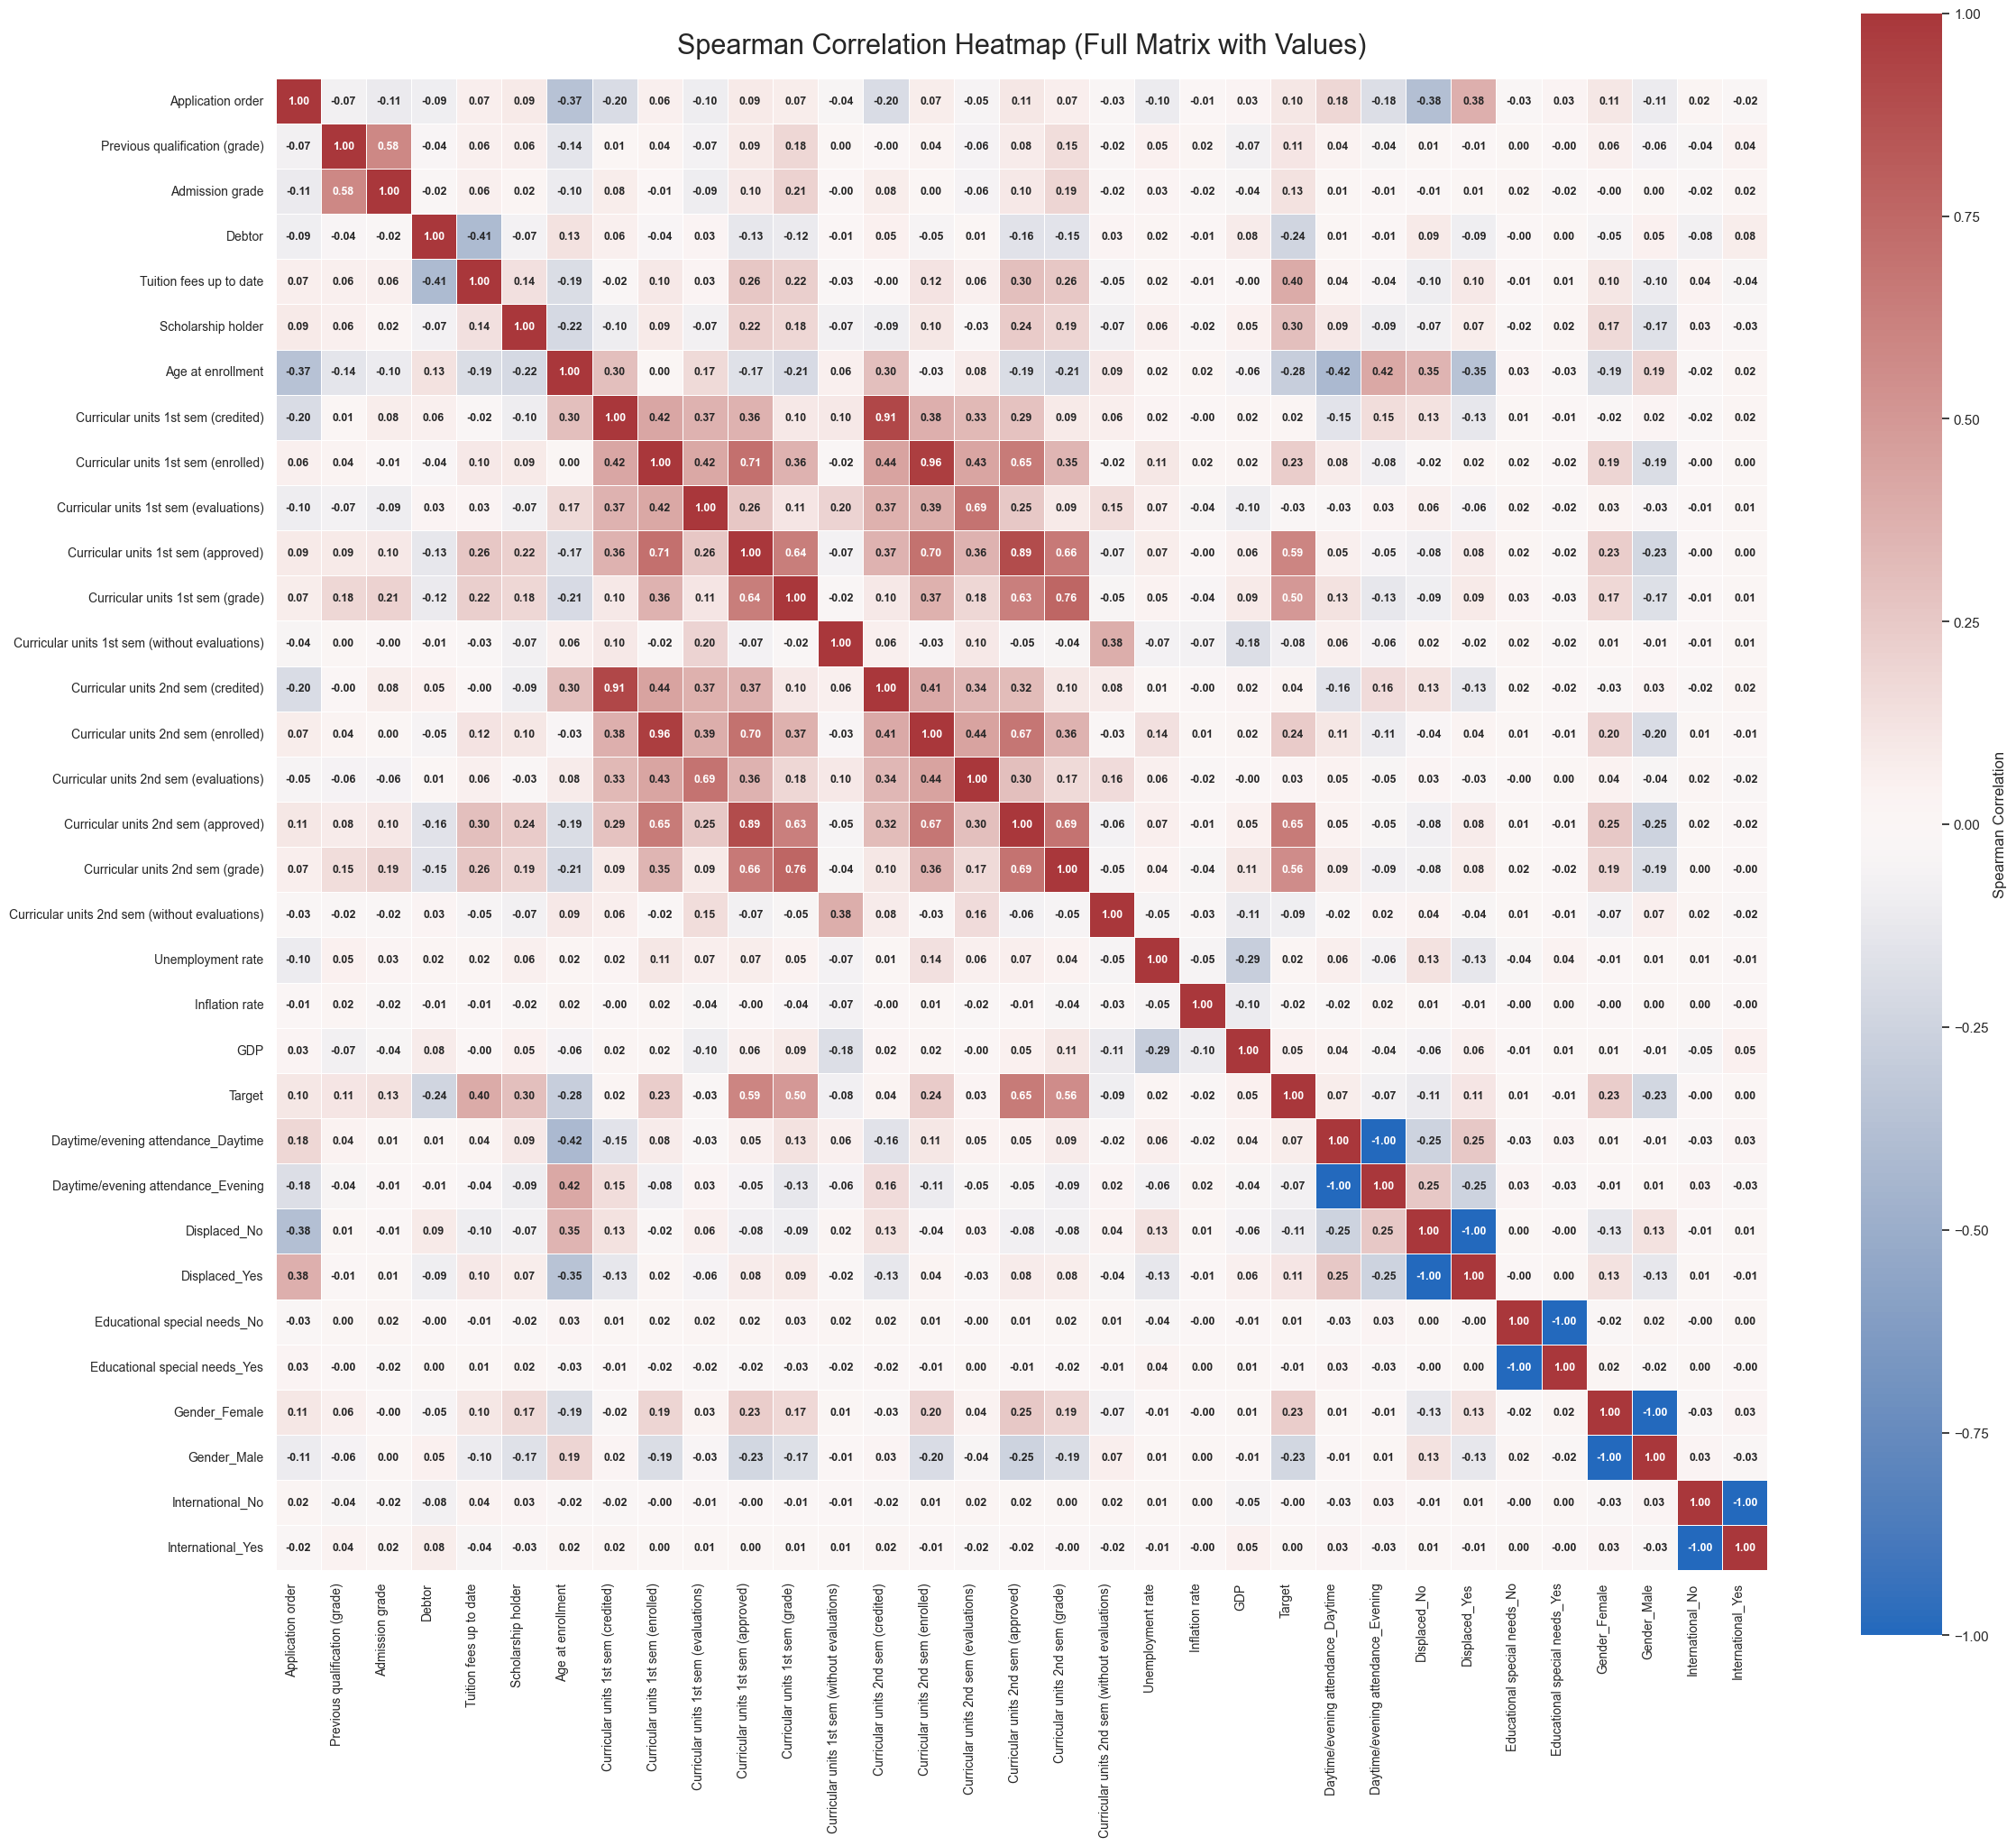

In [132]:
df_spearman = data.copy()

# ==========================================
# 1. ENCODE TARGET
# ==========================================
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_spearman['Target'] = df_spearman['Target'].replace(target_mapping)
df_spearman['Target'] = pd.to_numeric(df_spearman['Target'], errors='coerce')

# ==========================================
# 2. PISAHKAN NUMERIK & KATEGORIKAL (FILTER HIGH CARDINALITY)
# ==========================================
numeric_cols = df_spearman.select_dtypes(include="number").columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

categorical_cols = [col for col in df_spearman.columns if col not in numeric_cols and col != 'Target']

# Tentukan batas high cardinality
THRESHOLD = 5 
high_card_cols = [col for col in categorical_cols if df_spearman[col].nunique() > THRESHOLD]
low_card_cols = [col for col in categorical_cols if col not in high_card_cols]

# Buang sementara kolom high cardinality
df_spearman = df_spearman.drop(columns=high_card_cols)

# ==========================================
# 3. ONE-HOT ENCODING (Hanya untuk Low Cardinality)
# ==========================================
for col in low_card_cols:
    df_spearman[col] = df_spearman[col].astype(str)

df_encoded = pd.get_dummies(df_spearman, columns=low_card_cols, drop_first=False, dtype=int)

# ==========================================
# 4. HITUNG KORELASI SPEARMAN
# ==========================================
print(f"Menghitung Spearman Correlation untuk {df_encoded.shape[1] - 1} fitur terhadap Target...\n")
corr_matrix = df_encoded.corr(method='spearman', numeric_only=True)

# ==========================================
# 5. EKSTRAK TOP 10 POSITIF & NEGATIF
# ==========================================
target_corr = corr_matrix['Target'].drop('Target')

top_10_positive = target_corr.sort_values(ascending=False).head(10)
top_10_negative = target_corr.sort_values(ascending=True).head(10)

print("=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===")
print(top_10_positive.to_string())
print("\n=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===")
print(top_10_negative.to_string())
print("\nMenampilkan Heatmap...")

# ==========================================
# 6. VISUALISASI HEATMAP FULL KOTAK DENGAN ANGKA
# ==========================================
plt.figure(figsize=(24, 24)) # Ukuran diperbesar sedikit agar angka muat

# Render Heatmap (Tanpa Mask)
sns.heatmap(corr_matrix, 
            mask=None,        # Dibuat None agar tampil full satu kotak
            annot=True,       # Memunculkan angka
            fmt=".2f",        # Membatasi 2 angka di belakang koma agar rapi
            annot_kws={"weight": "bold", "size": 9}, # Membuat angka BOLD dan mengatur ukuran font
            cmap="vlag", 
            vmin=-1, vmax=1, 
            center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8, 'label': 'Spearman Correlation'})

# Styling Label dan Judul
plt.title('Spearman Correlation Heatmap (Full Matrix with Values)', fontsize=22, pad=20)

plt.xticks(rotation=90, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [133]:
# A. Rasio Kelulusan SKS (Academic Performance)

data['Pass_Rate_Sem1'] = np.where(data['Curricular units 1st sem (enrolled)'] == 0, 0, 
                                data['Curricular units 1st sem (approved)'] / data['Curricular units 1st sem (enrolled)'])

data['Pass_Rate_Sem2'] = np.where(data['Curricular units 2nd sem (enrolled)'] == 0, 0, 
                                data['Curricular units 2nd sem (approved)'] / data['Curricular units 2nd sem (enrolled)'])

# B. Tren Performa Akademik (Delta Features)
data['Grade_Trend'] = data['Curricular units 2nd sem (grade)'] - data['Curricular units 1st sem (grade)']
data['Approved_Units_Trend'] = data['Curricular units 2nd sem (approved)'] - data['Curricular units 1st sem (approved)']

# C. Indikator Tekanan Finansial (Financial Stress Proxy)
# Membuat fitur tingkat stres finansial (skala 0-3, semakin tinggi semakin berisiko)
# Debtor bernilai 1 jika berhutang, Tuition fees 0 jika telat bayar, Scholarship 0 jika tidak ada beasiswa
data['Financial_Stress_Index'] = data['Debtor'] + (1 - data['Tuition fees up to date']) + (1 - data['Scholarship holder'])

# D. Rasio Beban Akademik Tanpa Evaluasi (Pasif)
data['Unevaluated_Ratio_Sem1'] = np.where(data['Curricular units 1st sem (enrolled)'] == 0, 0, 
                                        data['Curricular units 1st sem (without evaluations)'] / data['Curricular units 1st sem (enrolled)'])

In [134]:
# SKS yang gagal di tiap semester
data['Failed_Units_Sem1'] = data['Curricular units 1st sem (enrolled)'] - data['Curricular units 1st sem (approved)']
data['Failed_Units_Sem2'] = data['Curricular units 2nd sem (enrolled)'] - data['Curricular units 2nd sem (approved)']

# Total akumulasi SKS gagal di tahun pertama
data['Total_Failed_Units'] = data['Failed_Units_Sem1'] + data['Failed_Units_Sem2']

In [135]:
# Semakin tinggi nilainya, semakin rentan mahasiswa tersebut
data['Vulnerability_Score'] = data['Age at enrollment'] * data['Financial_Stress_Index']

In [136]:
# Bernilai 1 jika di semester 2 dia tidak lulus SATU SKS pun dari yang didaftarkan
data['Zero_Approval_Sem2_Flag'] = np.where(data['Curricular units 2nd sem (approved)'] == 0, 1, 0)

In [137]:
data['Academic_Financial_Efficiency'] = data['Pass_Rate_Sem2'] * data['Tuition fees up to date']

In [138]:
data['Quality_Credit_Load'] = data['Pass_Rate_Sem2'] * data['Curricular units 2nd sem (approved)']

In [139]:
data['Scholarship_Performance_Boost'] = data['Pass_Rate_Sem2'] * (1 + data['Scholarship holder'])

In [140]:
data['Academic_Momentum'] = data['Pass_Rate_Sem1'] * data['Pass_Rate_Sem2']

In [141]:
# Mengurangi Pass_Rate jika Debtor = 1
data['Adjusted_Academic_Success'] = data['Pass_Rate_Sem2'] * (1 - (data['Debtor'] * 0.5))

In [142]:
# Mahasiswa dengan Pass Rate di area abu-abu (dekat 0.5)
data['Academic_Ambiguity'] = 1 - abs(data['Pass_Rate_Sem2'] - 0.5)

In [143]:
# 1. Fitur Biner: Membayar sendiri dan sudah lunas
data['Self_Funded_Lunas'] = ((data['Tuition fees up to date'] == 1) & (data['Scholarship holder'] == 0)).astype(int)

# 2. Interaksi dengan Pass Rate (Untuk mempertajam sinyal)
# Ini akan mendeteksi mahasiswa mandiri yang akademiknya "aman" tapi tidak "istimewa"
data['Self_Funded_Academic_Pace'] = data['Self_Funded_Lunas'] * data['Pass_Rate_Sem2']

In [144]:
# Mengukur penurunan atau kenaikan performa antar semester
data['Academic_Fatigue_Index'] = data['Pass_Rate_Sem2'] - data['Pass_Rate_Sem1']

In [145]:
# Mengukur efisiensi ujian: seberapa banyak ujian yang dikonversi jadi kelulusan
data['Evaluation_Efficiency_Sem2'] = data['Curricular units 2nd sem (approved)'] / (data['Curricular units 2nd sem (evaluations)'] + 1)
data['Evaluation_Efficiency_Sem1'] = data['Curricular units 1st sem (approved)'] / (data['Curricular units 1st sem (evaluations)'] + 1)


In [146]:

# 2. Buat fitur biner khusus untuk "Zona Enrolled"
data['is_enrolled_trend'] = ((data['Evaluation_Efficiency_Sem2'] >= 0.2) & 
                             (data['Evaluation_Efficiency_Sem2'] <= 0.6) & 
                             (data['Evaluation_Efficiency_Sem1'] >= 0.2) & 
                             (data['Evaluation_Efficiency_Sem1'] <= 0.6)).astype(int)

In [147]:
data['Enrolled_Strategic_Anchor'] = (data['is_enrolled_trend'] & data['Self_Funded_Lunas']).astype(int)

In [148]:
ct_trend = pd.crosstab(data['is_enrolled_trend'], data['Target'], normalize='index')

print("=== PROPORSI TARGET BERDASARKAN IS_ENROLLED_TREND ===")
print(ct_trend)

=== PROPORSI TARGET BERDASARKAN IS_ENROLLED_TREND ===
Target              Dropout  Enrolled  Graduate
is_enrolled_trend                              
0                  0.329942  0.125872  0.544186
1                  0.290650  0.366870  0.342480


In [149]:
ct_academic = pd.crosstab(data['Academic_Ambiguity'], data['Target'], normalize='index')

print("=== PROPORSI TARGET BERDASARKAN Academic_Ambiguity===")
print(ct_academic)

=== PROPORSI TARGET BERDASARKAN Academic_Ambiguity===
Target               Dropout  Enrolled  Graduate
Academic_Ambiguity                              
0.500000            0.333876  0.078081  0.588044
0.558824            1.000000  0.000000  0.000000
0.571429            0.500000  0.000000  0.500000
0.576923            0.000000  0.250000  0.750000
0.583333            0.000000  0.000000  1.000000
0.590909            0.200000  0.333333  0.466667
0.600000            0.000000  0.500000  0.500000
0.611111            0.250000  0.083333  0.666667
0.625000            0.050584  0.108949  0.840467
0.630435            0.000000  0.000000  1.000000
0.633333            0.000000  0.000000  1.000000
0.642857            1.000000  0.000000  0.000000
0.642857            0.097744  0.263158  0.639098
0.653846            0.142857  0.000000  0.857143
0.666667            0.246851  0.249370  0.503778
0.681818            0.250000  0.250000  0.500000
0.681818            1.000000  0.000000  0.000000
0.700000       

In [150]:
ct_academic = pd.crosstab(data['Academic_Financial_Efficiency'], data['Target'], normalize='index')

print("=== PROPORSI TARGET BERDASARKAN Academic_Financial_Efficiency ===")
print(ct_academic)

=== PROPORSI TARGET BERDASARKAN Academic_Financial_Efficiency ===
Target                          Dropout  Enrolled  Graduate
Academic_Financial_Efficiency                              
0.000000                       0.818182  0.092674  0.089144
0.125000                       0.333333  0.666667  0.000000
0.142857                       1.000000  0.000000  0.000000
0.166667                       0.744186  0.255814  0.000000
0.181818                       1.000000  0.000000  0.000000
0.200000                       0.650000  0.350000  0.000000
0.250000                       0.400000  0.400000  0.200000
0.285714                       0.500000  0.500000  0.000000
0.300000                       0.000000  1.000000  0.000000
0.333333                       0.542857  0.400000  0.057143
0.363636                       1.000000  0.000000  0.000000
0.375000                       0.500000  0.500000  0.000000
0.400000                       0.472973  0.513514  0.013514
0.416667                       1.0

In [151]:
ct_combined = pd.crosstab(index=[data['is_enrolled_trend'], data['Self_Funded_Lunas']], 
                          columns=data['Target'], 
                          normalize='index')

print("=== PERSILANGAN TREND X SELF-FUNDED TERHADAP TARGET ===")
print(ct_combined)

=== PERSILANGAN TREND X SELF-FUNDED TERHADAP TARGET ===
Target                                Dropout  Enrolled  Graduate
is_enrolled_trend Self_Funded_Lunas                              
0                 0                  0.347222  0.072531  0.580247
                  1                  0.319496  0.158116  0.522388
1                 0                  0.396491  0.242105  0.361404
                  1                  0.247496  0.417740  0.334764


In [152]:
# Menampilkan counts untuk persilangan Trend (Double Check) dan Self-Funded
ct_final_counts = pd.crosstab(
    index=[data['is_enrolled_trend'], data['Self_Funded_Lunas']], 
    columns=data['Target']
)

print("=== JUMLAH SAMPEL (COUNTS): TREND X SELF-FUNDED ===")
print(ct_final_counts)

print("\n=== TOTAL SAMPEL PER BARIS ===")
print(ct_final_counts.sum(axis=1))

=== JUMLAH SAMPEL (COUNTS): TREND X SELF-FUNDED ===
Target                               Dropout  Enrolled  Graduate
is_enrolled_trend Self_Funded_Lunas                             
0                 0                      450        94       752
                  1                      685       339      1120
1                 0                      113        69       103
                  1                      173       292       234

=== TOTAL SAMPEL PER BARIS ===
is_enrolled_trend  Self_Funded_Lunas
0                  0                    1296
                   1                    2144
1                  0                     285
                   1                     699
dtype: int64


---
## 5. Correlation

### Spearman

Menghitung Spearman Correlation untuk 56 fitur terhadap Target...

=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===
Academic_Financial_Efficiency          0.721909
Academic_Momentum                      0.709807
Pass_Rate_Sem2                         0.705157
Adjusted_Academic_Success              0.704204
Scholarship_Performance_Boost          0.686107
Evaluation_Efficiency_Sem2             0.684274
Quality_Credit_Load                    0.676082
Curricular units 2nd sem (approved)    0.654049
Pass_Rate_Sem1                         0.643078
Evaluation_Efficiency_Sem1             0.625172

=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===
Total_Failed_Units        -0.683227
Failed_Units_Sem2         -0.680709
Failed_Units_Sem1         -0.617555
Zero_Approval_Sem2_Flag   -0.504053
Vulnerability_Score       -0.472376
Financial_Stress_Index    -0.451876
Age at enrollment         -0.284946
Debtor                    -0.239002
Gender_Male               -0.229616
Academic_Ambiguity  

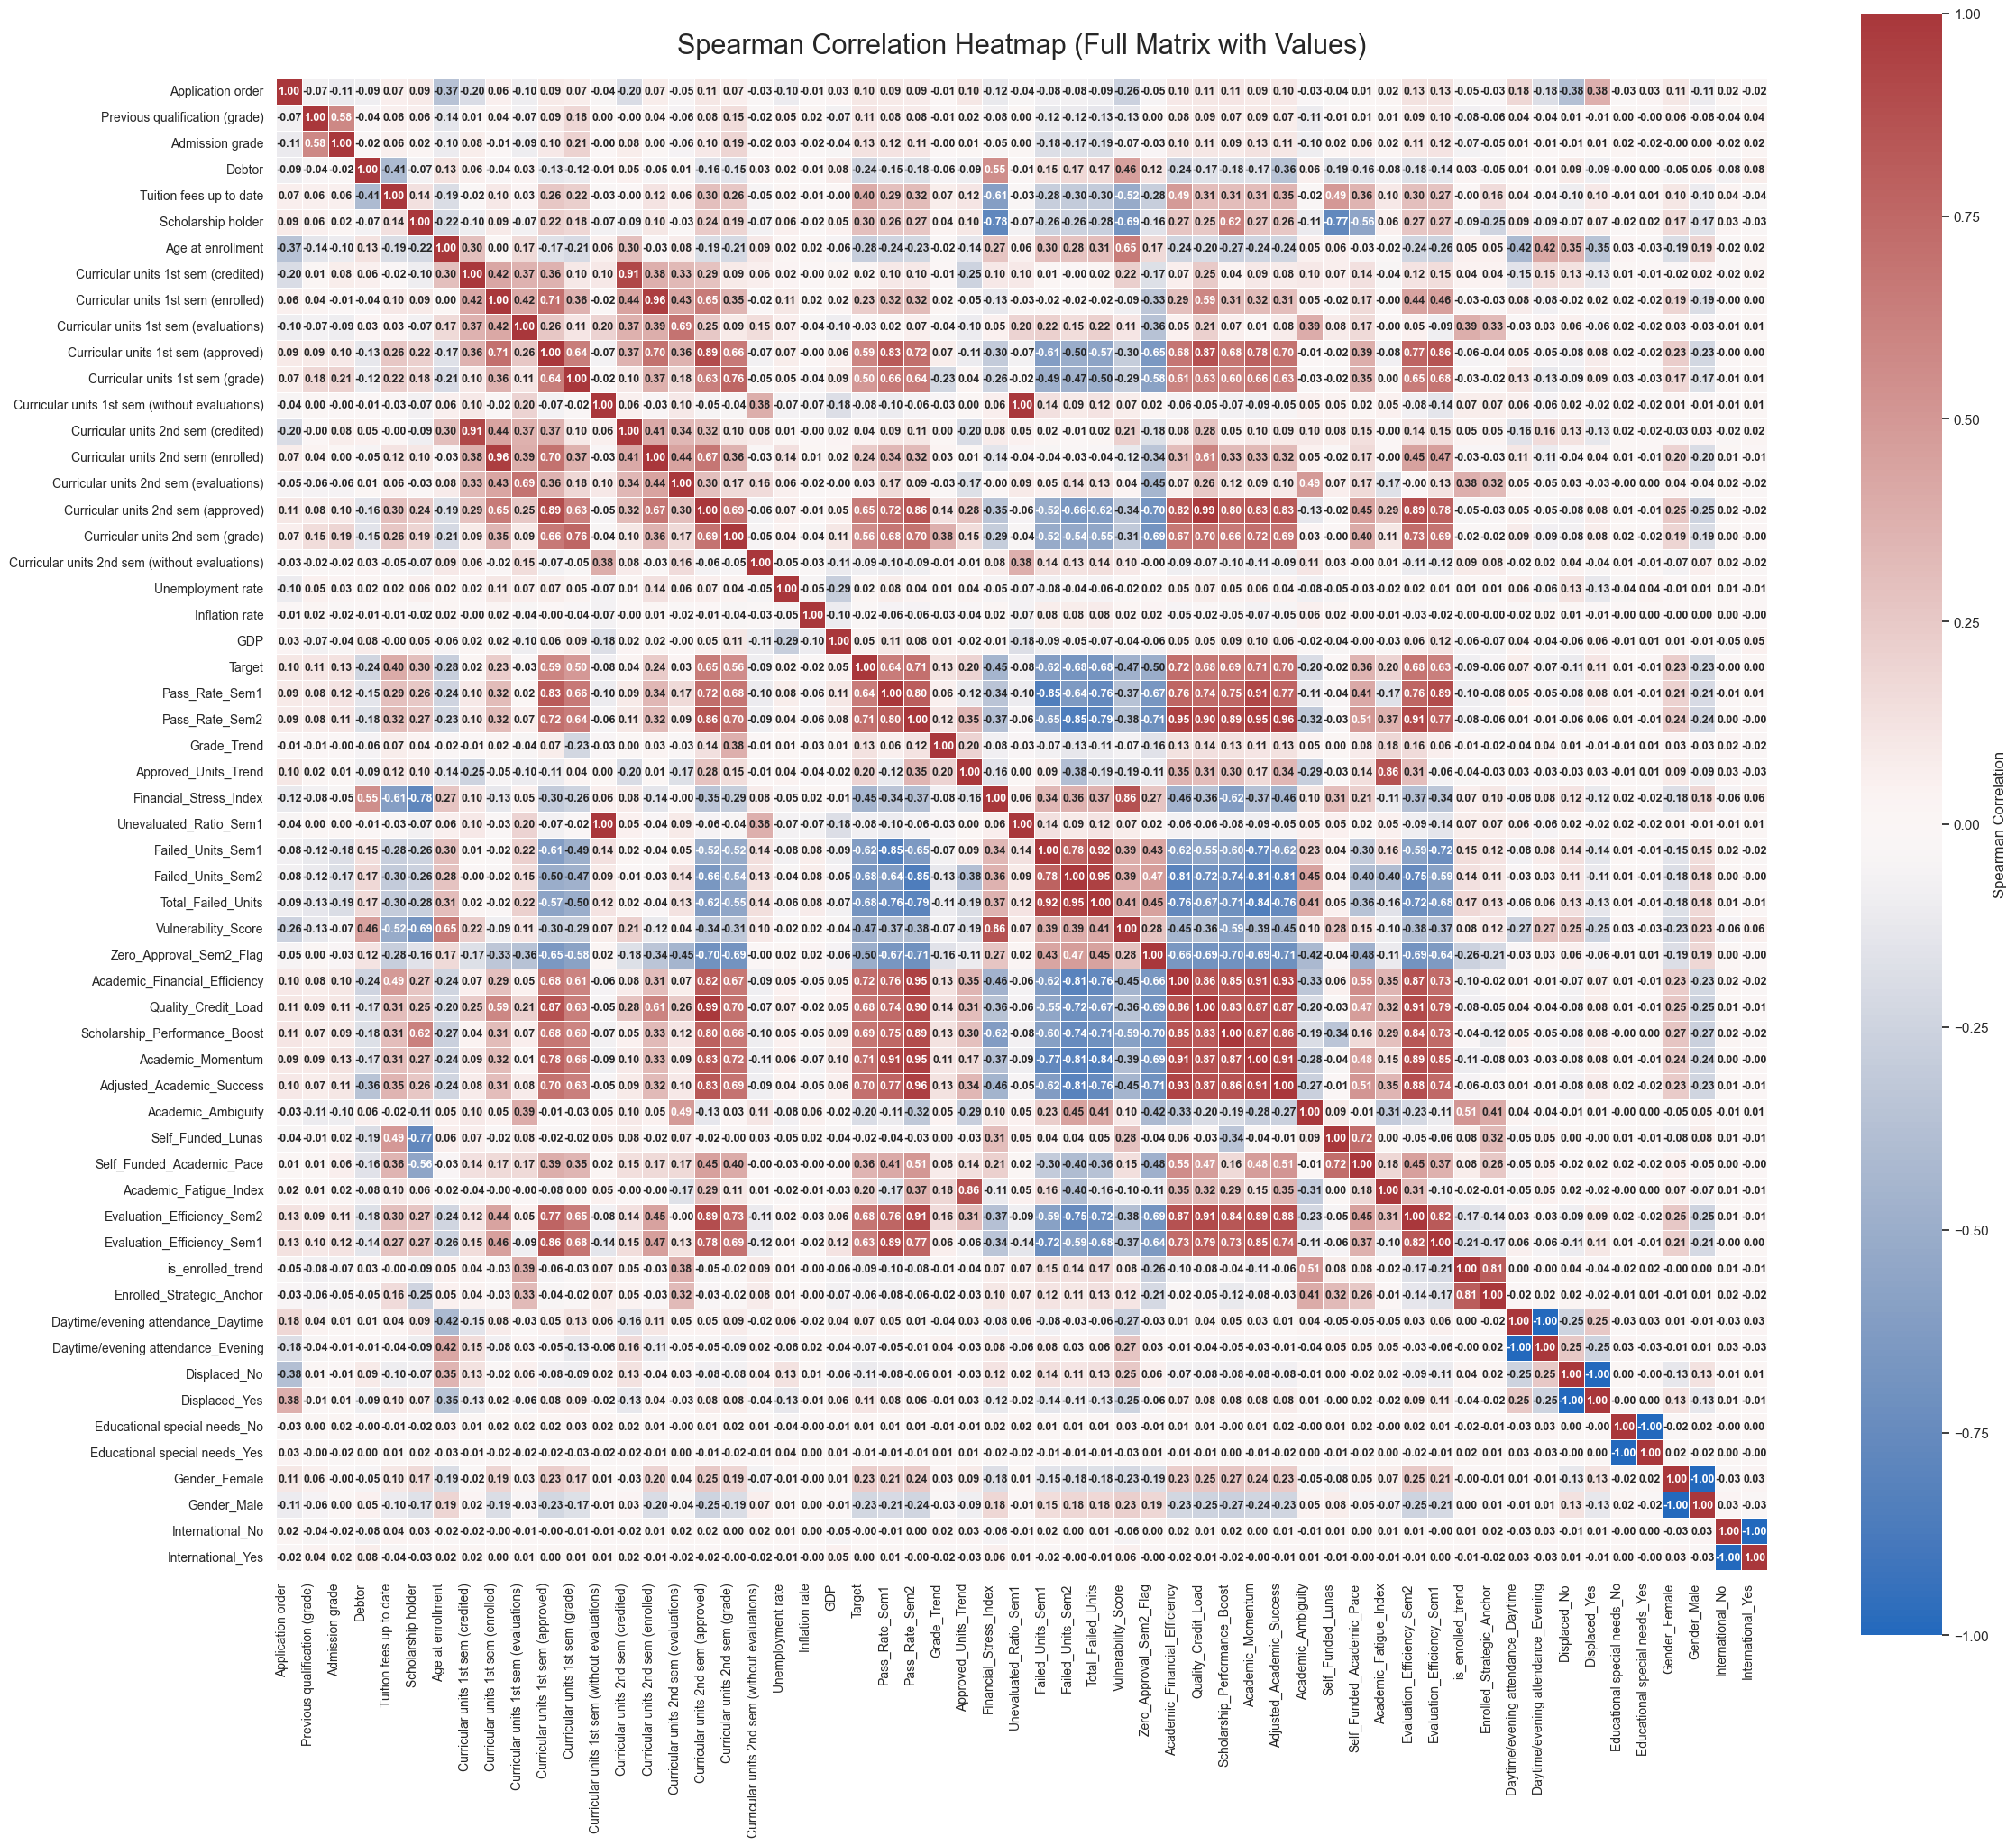

In [153]:
df_spearman = data.copy()

# ==========================================
# 1. ENCODE TARGET
# ==========================================
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_spearman['Target'] = df_spearman['Target'].replace(target_mapping)
df_spearman['Target'] = pd.to_numeric(df_spearman['Target'], errors='coerce')

# ==========================================
# 2. PISAHKAN NUMERIK & KATEGORIKAL (FILTER HIGH CARDINALITY)
# ==========================================
numeric_cols = df_spearman.select_dtypes(include="number").columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

categorical_cols = [col for col in df_spearman.columns if col not in numeric_cols and col != 'Target']

# Tentukan batas high cardinality
THRESHOLD = 5 
high_card_cols = [col for col in categorical_cols if df_spearman[col].nunique() > THRESHOLD]
low_card_cols = [col for col in categorical_cols if col not in high_card_cols]

# Buang sementara kolom high cardinality
df_spearman = df_spearman.drop(columns=high_card_cols)

# ==========================================
# 3. ONE-HOT ENCODING (Hanya untuk Low Cardinality)
# ==========================================
for col in low_card_cols:
    df_spearman[col] = df_spearman[col].astype(str)

df_encoded = pd.get_dummies(df_spearman, columns=low_card_cols, drop_first=False, dtype=int)

# ==========================================
# 4. HITUNG KORELASI SPEARMAN
# ==========================================
print(f"Menghitung Spearman Correlation untuk {df_encoded.shape[1] - 1} fitur terhadap Target...\n")
corr_matrix = df_encoded.corr(method='spearman', numeric_only=True)

# ==========================================
# 5. EKSTRAK TOP 10 POSITIF & NEGATIF
# ==========================================
target_corr = corr_matrix['Target'].drop('Target')

top_10_positive = target_corr.sort_values(ascending=False).head(10)
top_10_negative = target_corr.sort_values(ascending=True).head(10)

print("=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===")
print(top_10_positive.to_string())
print("\n=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===")
print(top_10_negative.to_string())
print("\nMenampilkan Heatmap...")

# ==========================================
# 6. VISUALISASI HEATMAP FULL KOTAK DENGAN ANGKA
# ==========================================
plt.figure(figsize=(24, 24)) # Ukuran diperbesar sedikit agar angka muat

# Render Heatmap (Tanpa Mask)
sns.heatmap(corr_matrix, 
            mask=None,        # Dibuat None agar tampil full satu kotak
            annot=True,       # Memunculkan angka
            fmt=".2f",        # Membatasi 2 angka di belakang koma agar rapi
            annot_kws={"weight": "bold", "size": 9}, # Membuat angka BOLD dan mengatur ukuran font
            cmap="vlag", 
            vmin=-1, vmax=1, 
            center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8, 'label': 'Spearman Correlation'})

# Styling Label dan Judul
plt.title('Spearman Correlation Heatmap (Full Matrix with Values)', fontsize=22, pad=20)

plt.xticks(rotation=90, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### MI Score

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\691926059.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


Menghitung Mutual Information Score untuk 60 fitur...

=== TOP 15 FITUR TERPENTING (MUTUAL INFORMATION) ===
                                Feature  MI_Score
0         Academic_Financial_Efficiency  0.366354
1                     Academic_Momentum  0.358997
2         Scholarship_Performance_Boost  0.352790
3                        Pass_Rate_Sem2  0.341800
4                    Total_Failed_Units  0.339672
5             Adjusted_Academic_Success  0.339373
6                   Quality_Credit_Load  0.338696
7            Evaluation_Efficiency_Sem2  0.327660
8                     Failed_Units_Sem2  0.319410
9   Curricular units 2nd sem (approved)  0.311873
10                       Pass_Rate_Sem1  0.280829
11           Evaluation_Efficiency_Sem1  0.269003
12                    Failed_Units_Sem1  0.244395
13  Curricular units 1st sem (approved)  0.239370
14     Curricular units 2nd sem (grade)  0.236097


C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\691926059.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_scores_df.head(30), palette='magma')


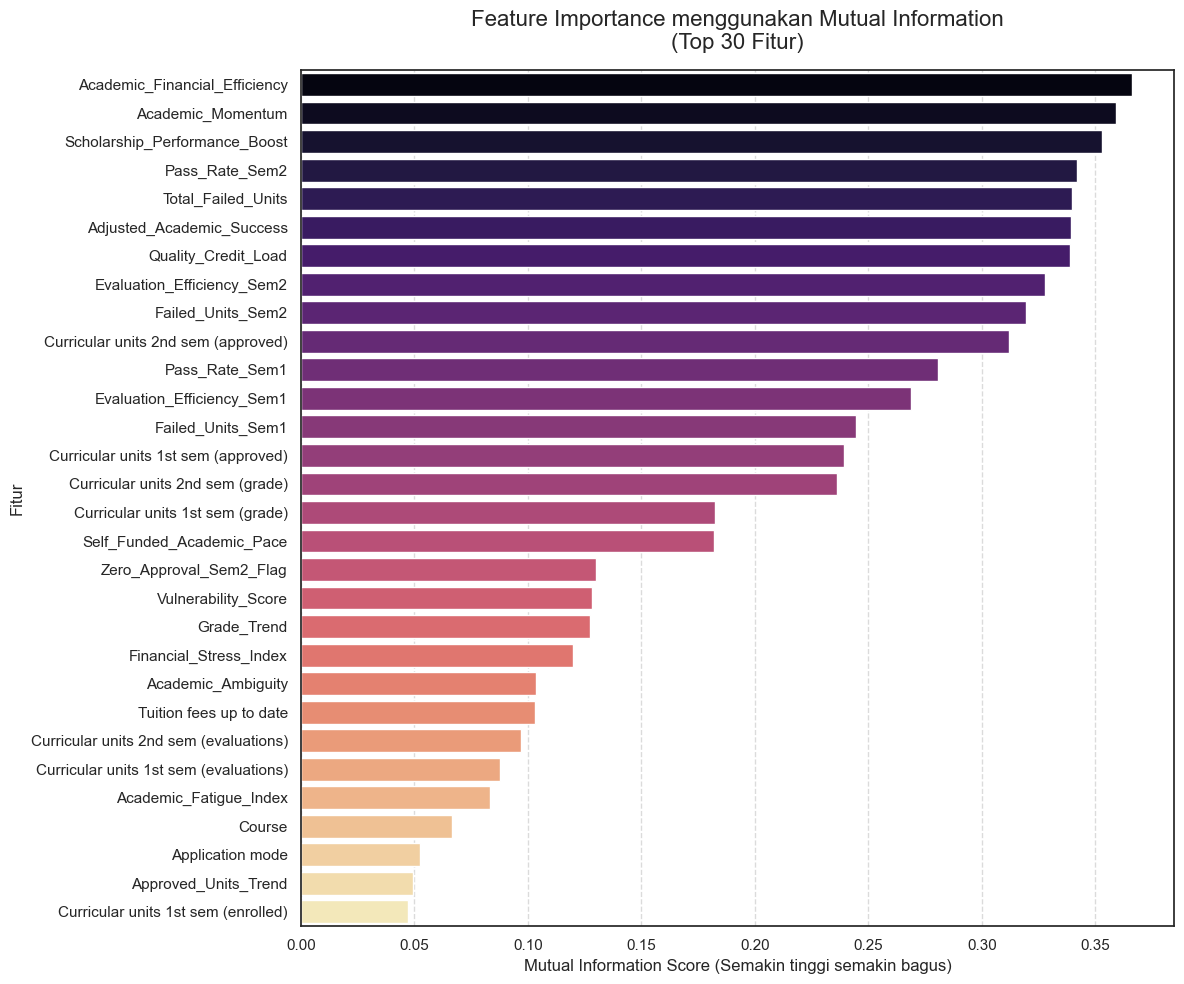

In [154]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
df_mi = data.copy()

# ==========================================
# 2. ENCODE TARGET
# ==========================================
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_mi['Target'] = df_mi['Target'].astype(str).str.strip().str.title()
df_mi['Target'] = df_mi['Target'].map(target_mapping)
df_mi = df_mi.dropna(subset=['Target']) # Buang jika ada yang gagal map

# ==========================================
# 3. PERSIAPAN FITUR (LABEL ENCODING UNTUK KATEGORIKAL)
# ==========================================
X = df_mi.drop(columns=['Target'])
y = df_mi['Target']

# Identifikasi kolom kategorikal (termasuk yang high cardinality)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Encode HANYA kolom kategorikal menggunakan LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Membuat mask boolean: True untuk kolom diskrit (kategorikal), False untuk kontinu (numerik)
# Ini membantu algoritma MI berhitung dengan jauh lebih akurat
discrete_features_mask = [col in categorical_cols for col in X.columns]

# ==========================================
# 4. HITUNG MUTUAL INFORMATION (MI)
# ==========================================
print(f"Menghitung Mutual Information Score untuk {X.shape[1]} fitur...")
# random_state dipasang agar hasilnya konsisten jika di-run berulang kali
mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features_mask, random_state=42)

# ==========================================
# 5. FORMAT HASIL & VISUALISASI
# ==========================================
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

print("\n=== TOP 15 FITUR TERPENTING (MUTUAL INFORMATION) ===")
print(mi_scores_df.head(15).to_string())

# Plot Top 30 Fitur Teratas
plt.figure(figsize=(12, 10))
sns.barplot(x='MI_Score', y='Feature', data=mi_scores_df.head(30), palette='magma')

plt.title('Feature Importance menggunakan Mutual Information\n(Top 30 Fitur)', fontsize=16, pad=15)
plt.xlabel('Mutual Information Score (Semakin tinggi semakin bagus)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Selection

##### Using MI Score

In [155]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Asumsi df_master adalah dataframe Anda yang sudah berisi target dan fitur engineering
df_clean = data.copy()

# 1. Pastikan Target sudah di-encode ke (0, 1, 2)
if df_clean['Target'].dtype == 'object':
    target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
    df_clean['Target'] = df_clean['Target'].astype(str).str.strip().str.title().map(target_mapping)
    df_clean = df_clean.dropna(subset=['Target'])

# 2. Siapkan X dan y
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

# 3. Label Encoding sementara HANYA untuk menghitung MI (seperti yang kita bahas sebelumnya)
X_mi = X.copy()
categorical_cols = X_mi.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    X_mi[col] = le.fit_transform(X_mi[col].astype(str))

discrete_mask = [col in categorical_cols for col in X_mi.columns]

# 4. Hitung MI Score
print("Menghitung Mutual Information Scores...")
mi_scores = mutual_info_classif(X_mi, y, discrete_features=discrete_mask, random_state=42)

mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI_Score': mi_scores})

# ==========================================
# PROSES DROP FITUR BERDASARKAN THRESHOLD
# ==========================================
# Kita set batas bawah (threshold). Misalnya 0.005. 
# Fitur di bawah ini dianggap "Noise"
THRESHOLD_MI = 0.005

fitur_penting = mi_df[mi_df['MI_Score'] >= THRESHOLD_MI]['Feature'].tolist()
fitur_sampah = mi_df[mi_df['MI_Score'] < THRESHOLD_MI]['Feature'].tolist()

print(f"\nMenemukan {len(fitur_sampah)} fitur 'sampah' (MI Score < {THRESHOLD_MI}):")
for f in fitur_sampah:
    print(f"- {f}")

print(f"\nMenyisakan {len(fitur_penting)} fitur penting untuk model XGBoost.")

# 5. Buat DataFrame Final yang sudah bersih
# Perhatikan: Kita mengambil fitur_penting dari dataframe asli (X), BUKAN dari X_mi
# Sehingga fitur kategorikalnya tetap dalam bentuk aslinya untuk diproses XGBoost nanti
X_final = X[fitur_penting]
df_final = pd.concat([X_final, y], axis=1)

print(f"\nUkuran Dataset sekarang: {df_final.shape}")

C:\Users\ACER\AppData\Local\Temp\ipykernel_9328\3870800186.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_mi.select_dtypes(include=['object', 'category']).columns.tolist()


Menghitung Mutual Information Scores...

Menemukan 7 fitur 'sampah' (MI Score < 0.005):
- Application order
- Daytime/evening attendance
- Educational special needs
- International
- Curricular units 1st sem (credited)
- Unemployment rate
- Unevaluated_Ratio_Sem1

Menyisakan 53 fitur penting untuk model XGBoost.

Ukuran Dataset sekarang: (4424, 54)


Menghitung Spearman Correlation untuk 46 fitur terhadap Target...

=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===
Academic_Financial_Efficiency          0.721909
Academic_Momentum                      0.709807
Pass_Rate_Sem2                         0.705157
Adjusted_Academic_Success              0.704204
Scholarship_Performance_Boost          0.686107
Evaluation_Efficiency_Sem2             0.684274
Quality_Credit_Load                    0.676082
Curricular units 2nd sem (approved)    0.654049
Pass_Rate_Sem1                         0.643078
Evaluation_Efficiency_Sem1             0.625172

=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===
Total_Failed_Units        -0.683227
Failed_Units_Sem2         -0.680709
Failed_Units_Sem1         -0.617555
Zero_Approval_Sem2_Flag   -0.504053
Vulnerability_Score       -0.472376
Financial_Stress_Index    -0.451876
Age at enrollment         -0.284946
Debtor                    -0.239002
Gender_Male               -0.229616
Academic_Ambiguity  

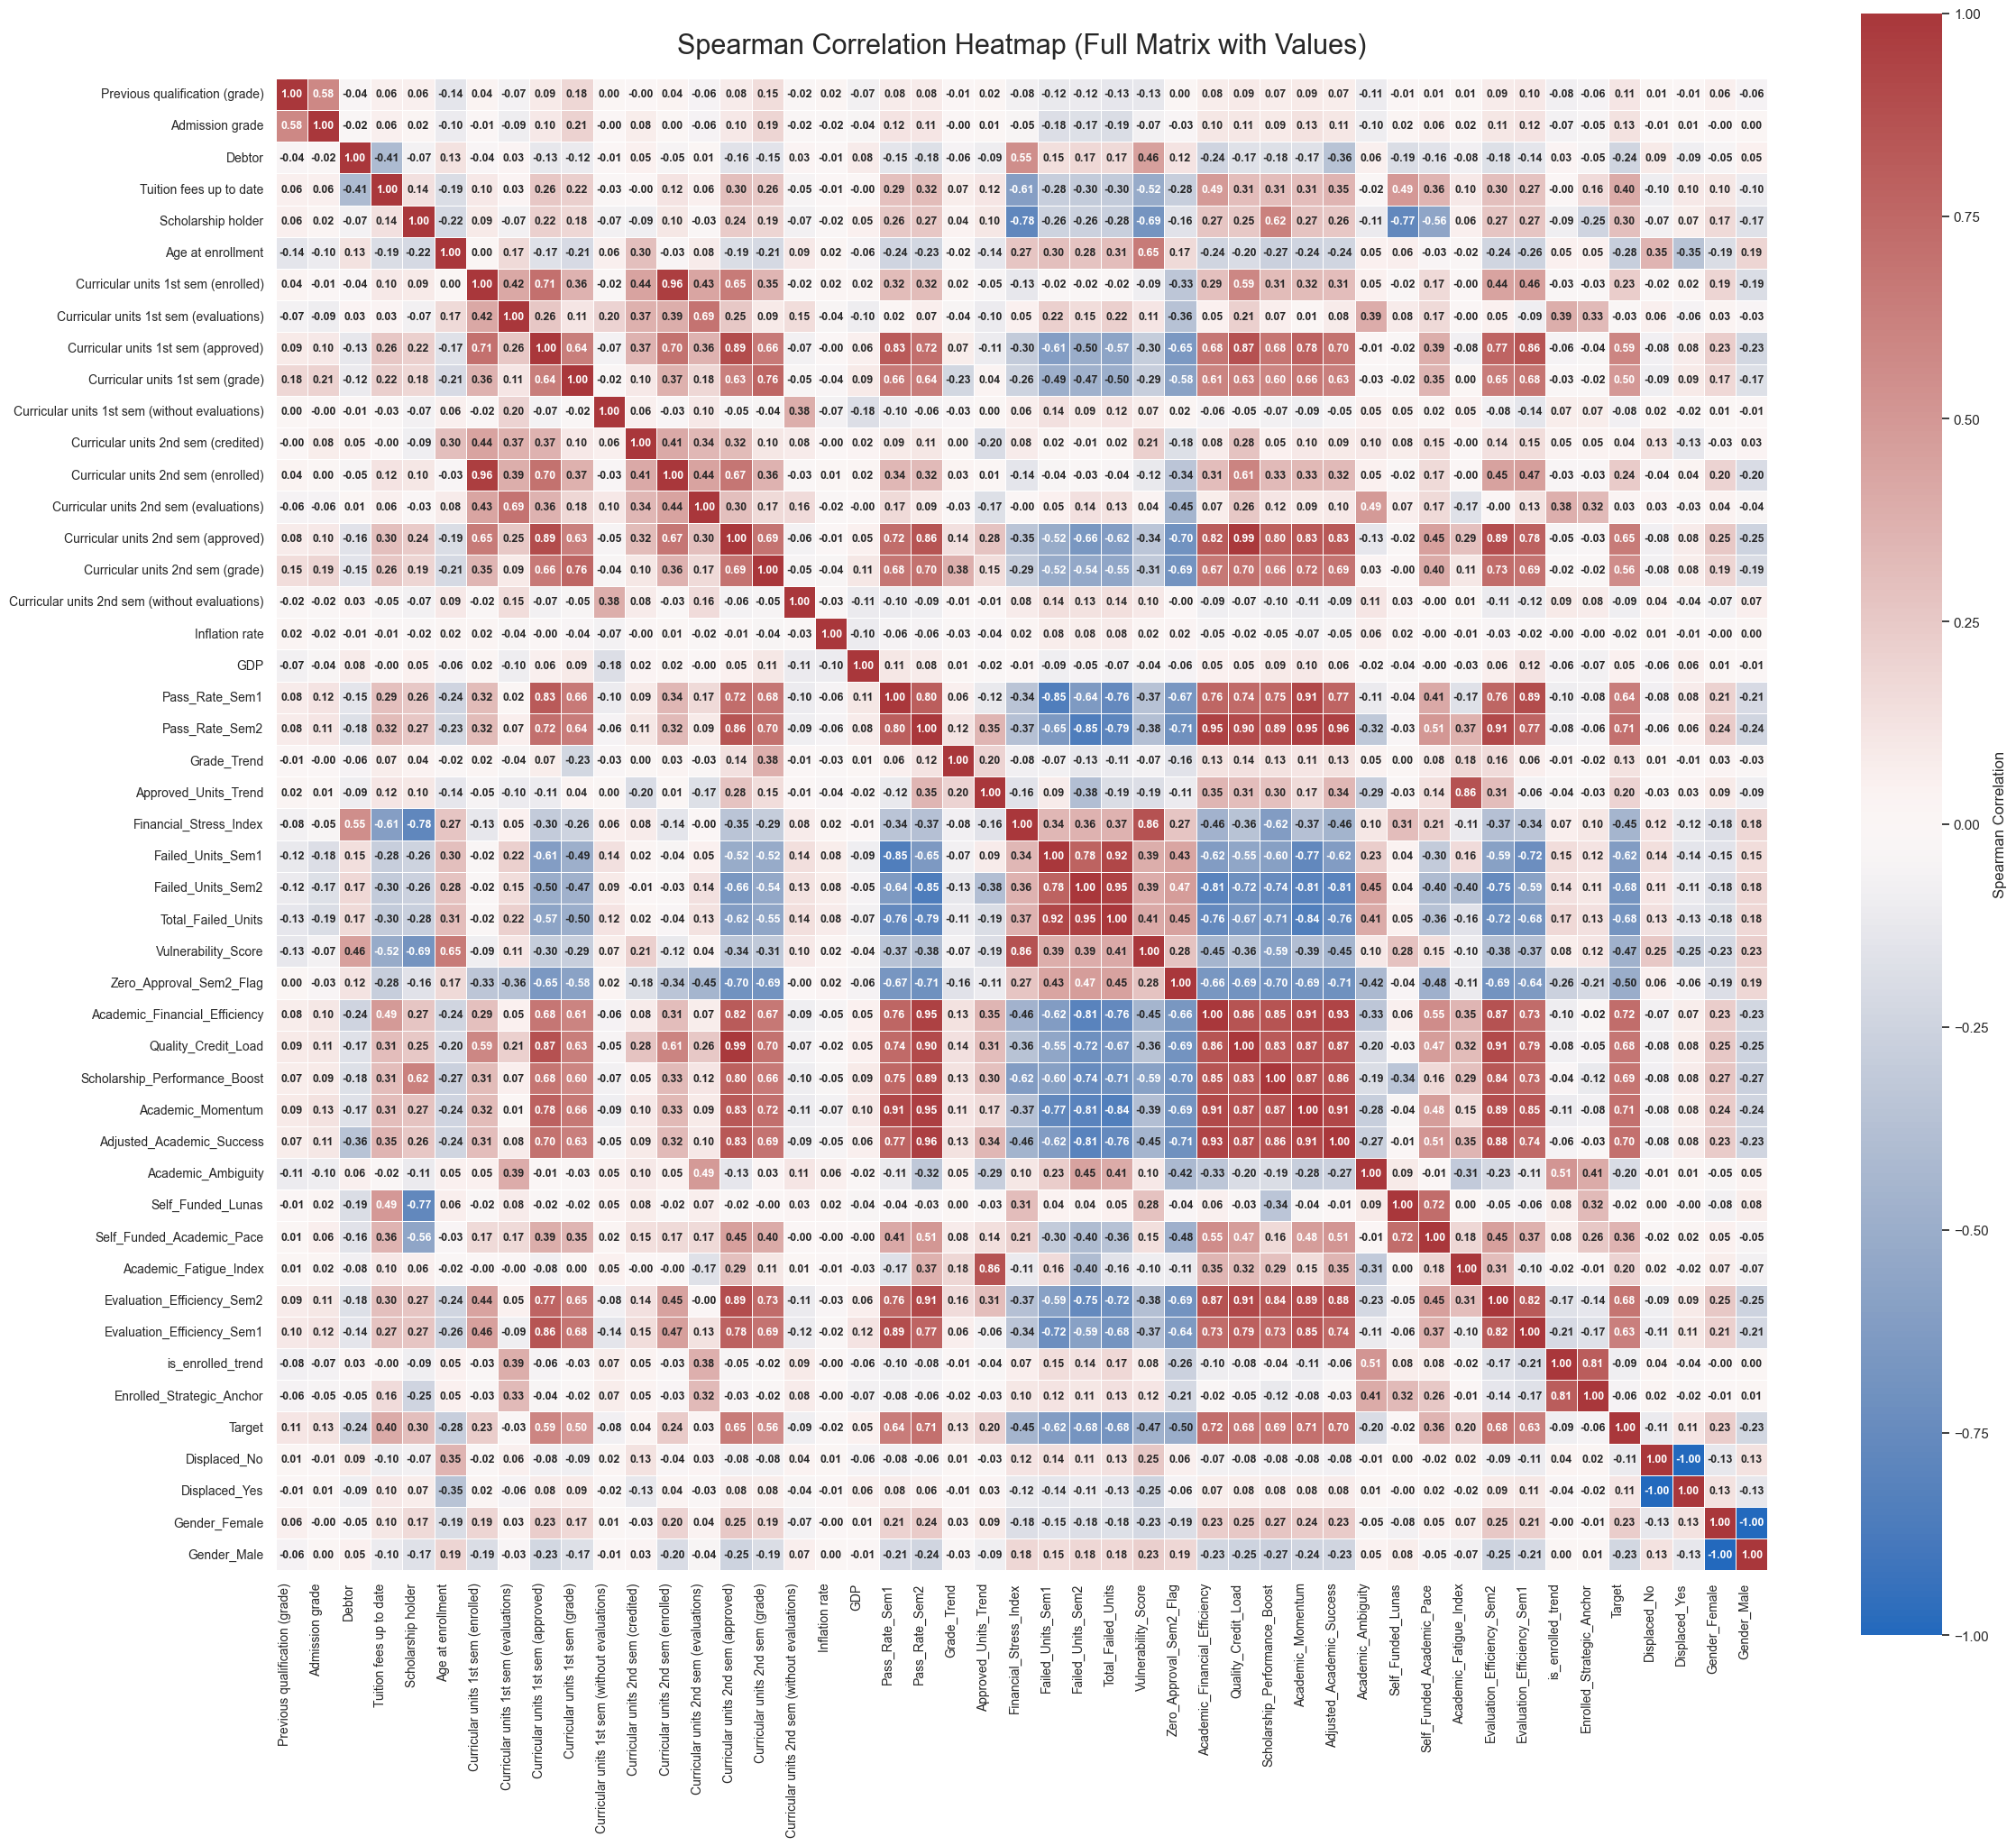

In [156]:
df_spearman = df_final.copy()

# ==========================================
# 1. ENCODE TARGET
# ==========================================
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_spearman['Target'] = df_spearman['Target'].replace(target_mapping)
df_spearman['Target'] = pd.to_numeric(df_spearman['Target'], errors='coerce')

# ==========================================
# 2. PISAHKAN NUMERIK & KATEGORIKAL (FILTER HIGH CARDINALITY)
# ==========================================
numeric_cols = df_spearman.select_dtypes(include="number").columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

categorical_cols = [col for col in df_spearman.columns if col not in numeric_cols and col != 'Target']

# Tentukan batas high cardinality
THRESHOLD = 5 
high_card_cols = [col for col in categorical_cols if df_spearman[col].nunique() > THRESHOLD]
low_card_cols = [col for col in categorical_cols if col not in high_card_cols]

# Buang sementara kolom high cardinality
df_spearman = df_spearman.drop(columns=high_card_cols)

# ==========================================
# 3. ONE-HOT ENCODING (Hanya untuk Low Cardinality)
# ==========================================
for col in low_card_cols:
    df_spearman[col] = df_spearman[col].astype(str)

df_encoded = pd.get_dummies(df_spearman, columns=low_card_cols, drop_first=False, dtype=int)

# ==========================================
# 4. HITUNG KORELASI SPEARMAN
# ==========================================
print(f"Menghitung Spearman Correlation untuk {df_encoded.shape[1] - 1} fitur terhadap Target...\n")
corr_matrix = df_encoded.corr(method='spearman', numeric_only=True)

# ==========================================
# 5. EKSTRAK TOP 10 POSITIF & NEGATIF
# ==========================================
target_corr = corr_matrix['Target'].drop('Target')

top_10_positive = target_corr.sort_values(ascending=False).head(10)
top_10_negative = target_corr.sort_values(ascending=True).head(10)

print("=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===")
print(top_10_positive.to_string())
print("\n=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===")
print(top_10_negative.to_string())
print("\nMenampilkan Heatmap...")

# ==========================================
# 6. VISUALISASI HEATMAP FULL KOTAK DENGAN ANGKA
# ==========================================
plt.figure(figsize=(24, 24)) # Ukuran diperbesar sedikit agar angka muat

# Render Heatmap (Tanpa Mask)
sns.heatmap(corr_matrix, 
            mask=None,        # Dibuat None agar tampil full satu kotak
            annot=True,       # Memunculkan angka
            fmt=".2f",        # Membatasi 2 angka di belakang koma agar rapi
            annot_kws={"weight": "bold", "size": 9}, # Membuat angka BOLD dan mengatur ukuran font
            cmap="vlag", 
            vmin=-1, vmax=1, 
            center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8, 'label': 'Spearman Correlation'})

# Styling Label dan Judul
plt.title('Spearman Correlation Heatmap (Full Matrix with Values)', fontsize=22, pad=20)

plt.xticks(rotation=90, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

##### Using Analysis

In [157]:
features_to_drop = [ 
    'Inflation rate', 
    'GDP', 
    "Failed_Units_Sem1",
    "Failed_Units_Sem2",
    
    "Academic_Momentum",
    # "Self_Funded_Academic_Pace",
    # "Total_Failed_Units",
    "Enrolled_Strategic_Anchor",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 2nd sem (enrolled)",
    'Curricular units 2nd sem (evaluations)', 
    'Curricular units 1st sem (evaluations)',
    "Curricular units 2nd sem (without evaluations)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (credited)",
    'Displaced_No',
    "Gender_Female"
]

# Menghapus fitur dari df_final
# errors='ignore' digunakan agar kode tidak crash jika kolom sudah terlanjur terhapus sebelumnya
df_final = df_final.drop(columns=features_to_drop, errors='ignore')

In [158]:
df_final.shape

(4424, 39)

In [159]:
df_final.columns

Index(['Marital status', 'Application mode', 'Course',
       'Previous qualification', 'Previous qualification (grade)',
       'Nacionality', 'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender',
       'Scholarship holder', 'Age at enrollment',
       'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
       'Pass_Rate_Sem1', 'Pass_Rate_Sem2', 'Grade_Trend',
       'Approved_Units_Trend', 'Financial_Stress_Index', 'Total_Failed_Units',
       'Vulnerability_Score', 'Zero_Approval_Sem2_Flag',
       'Academic_Financial_Efficiency', 'Quality_Credit_Load',
       'Scholarship_Performance_Boost', 'Adjusted_Academic_Success',
       'Academic_Ambiguity', 'Self_Funded_Lunas', 'Self_Funded_Academic_Pace',
       'Academic_Fatigue_Index', 'Evaluation_Efficiency_Sem2',
       'Evaluation_Efficiency_Sem1', 'is_enrolled_trend', 'Target'],

['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Menghitung Spearman Correlation untuk 31 fitur terhadap Target...

=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===
Academic_Financial_Efficiency       0.721909
Pass_Rate_Sem2                      0.705157
Adjusted_Academic_Success           0.704204
Scholarship_Performance_Boost       0.686107
Evaluation_Efficiency_Sem2          0.684274
Quality_Credit_Load                 0.676082
Pass_Rate_Sem1                      0.643078
Evaluation_Efficiency_Sem1          0.625172
Curricular units 2nd sem (grade)    0.559820
Curricular units 1st sem (grade)    0.497341

=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===
Total_Failed_Units        -0.683227
Zero_Approval_Sem2_Flag   -0.504053
Vulnerability_Score       -0.472376
Financial_Stress_Index    -0.451876
Age at enrollment         -0.284946
Debtor

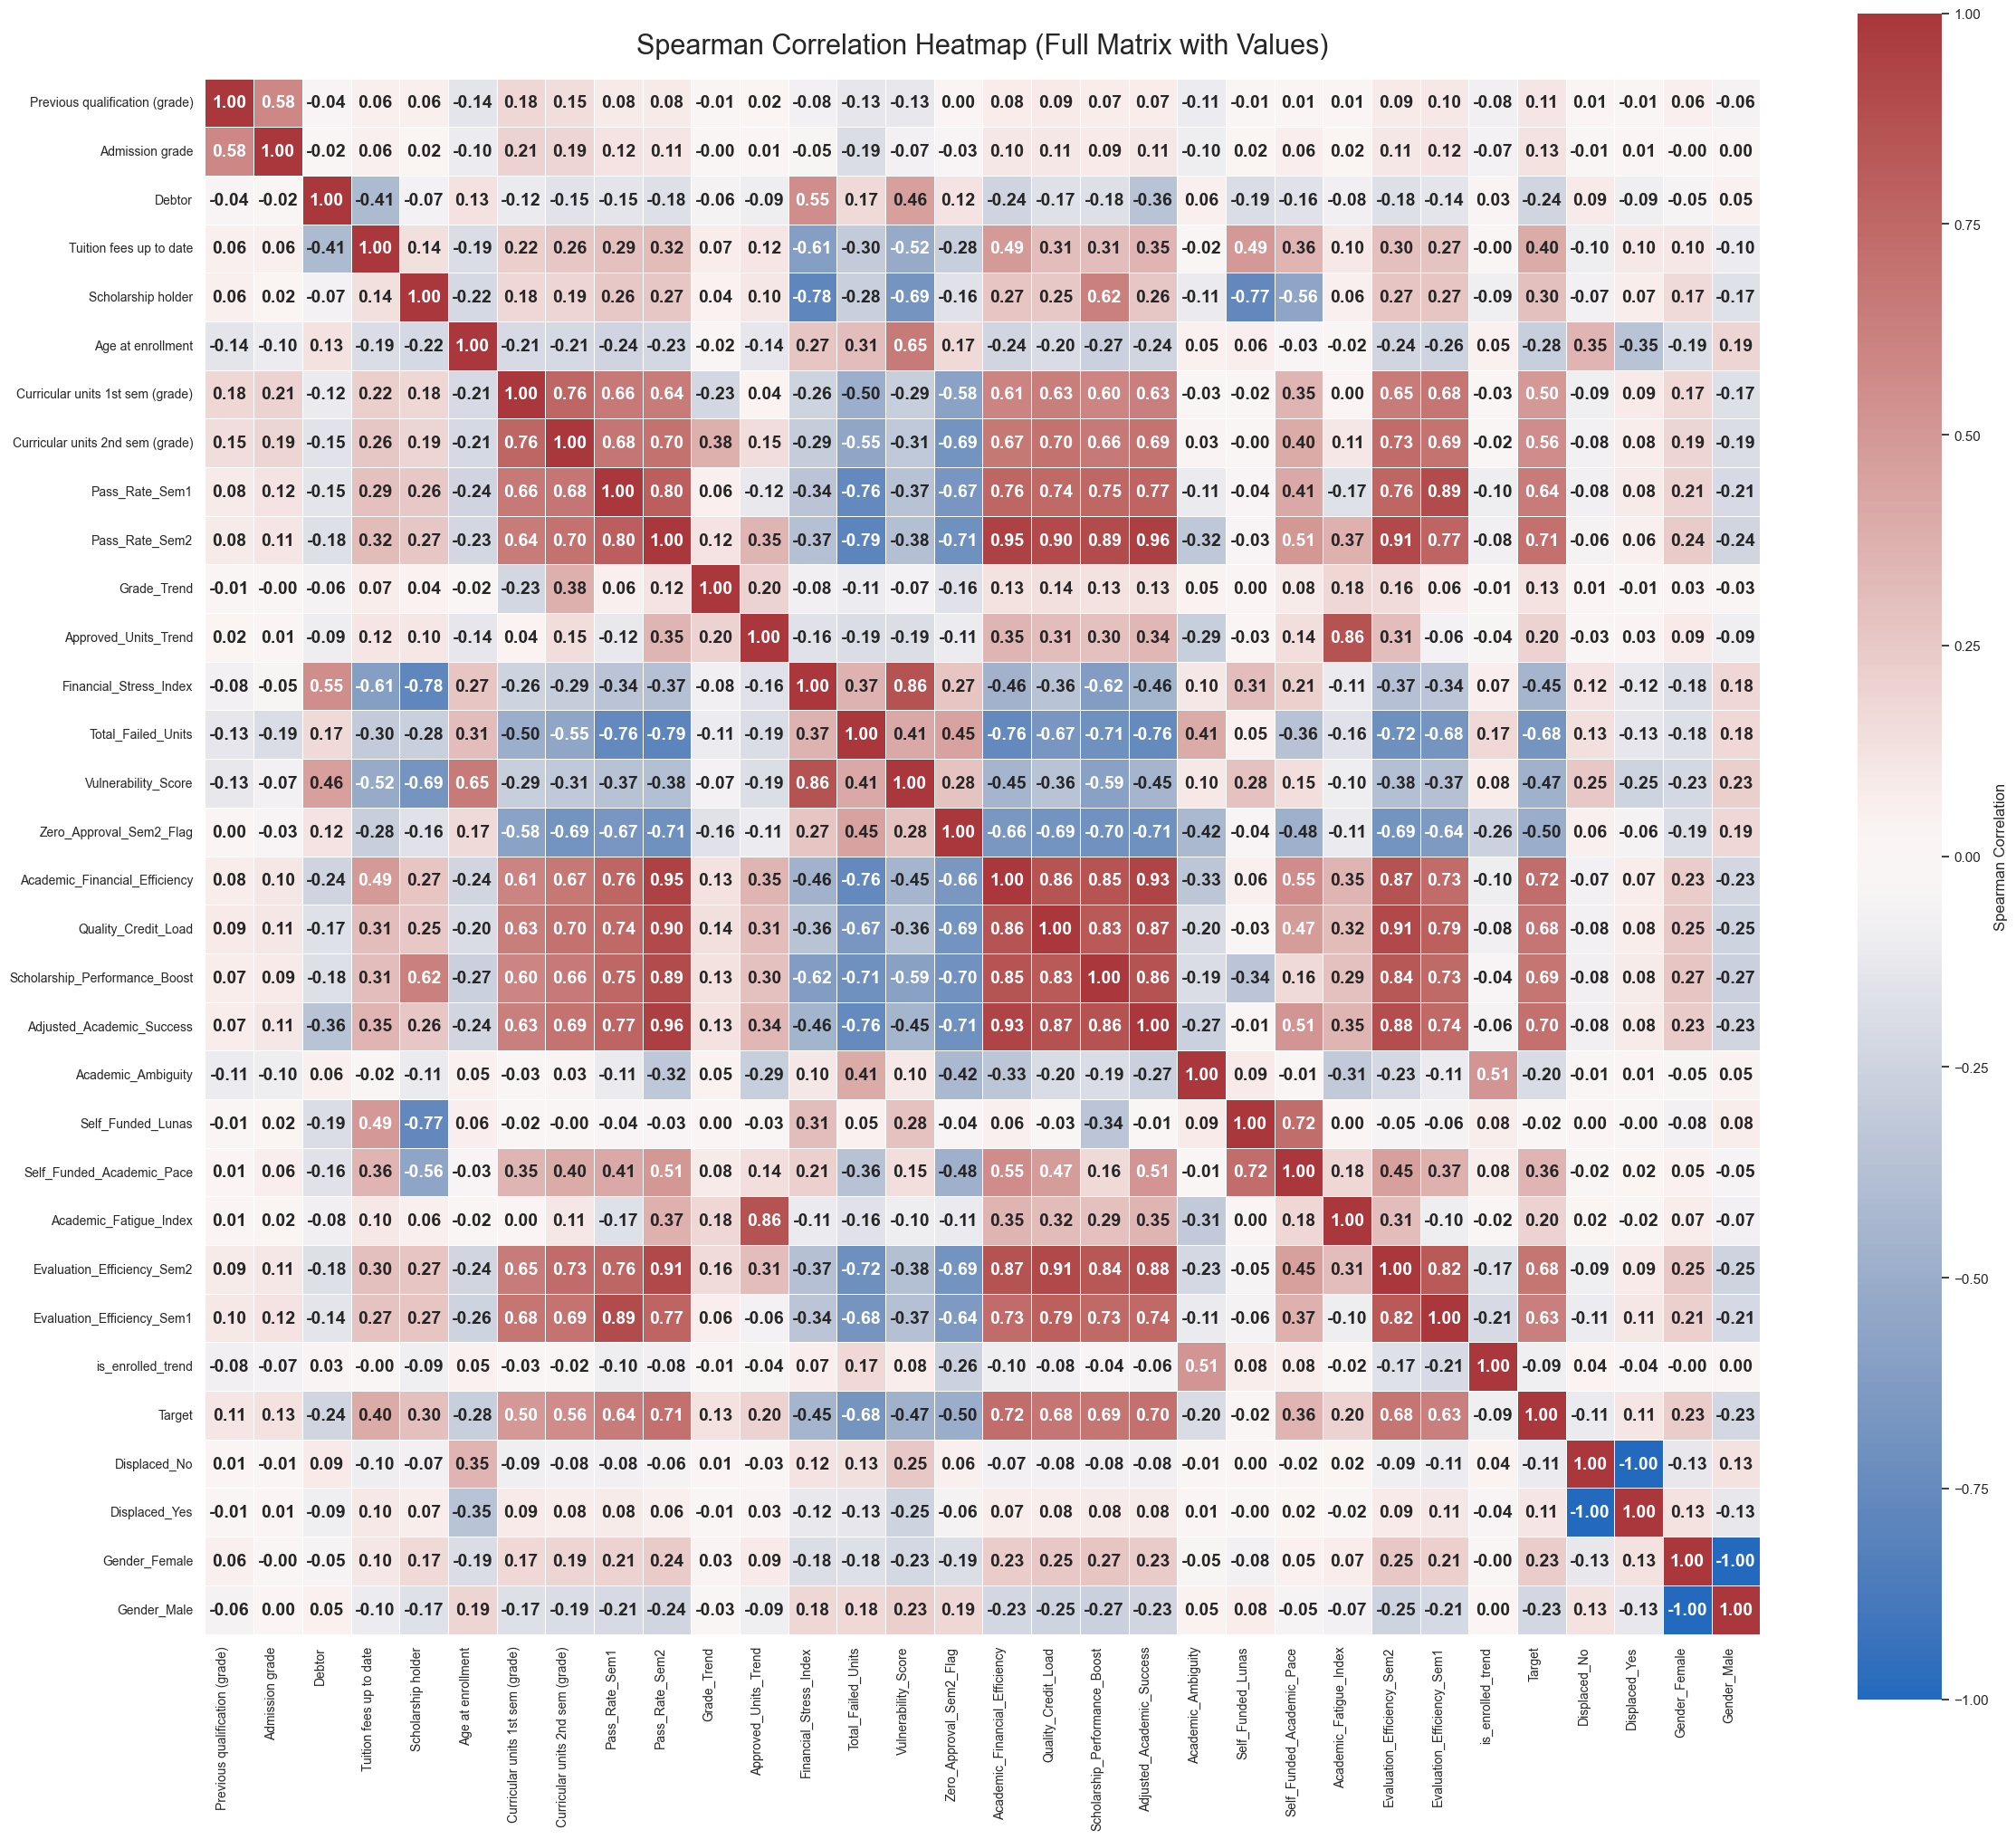

In [160]:
df_spearman = df_final.copy()

# ==========================================
# 1. ENCODE TARGET
# ==========================================
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_spearman['Target'] = df_spearman['Target'].replace(target_mapping)
df_spearman['Target'] = pd.to_numeric(df_spearman['Target'], errors='coerce')

# ==========================================
# 2. PISAHKAN NUMERIK & KATEGORIKAL (FILTER HIGH CARDINALITY)
# ==========================================
numeric_cols = df_spearman.select_dtypes(include="number").columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

categorical_cols = [col for col in df_spearman.columns if col not in numeric_cols and col != 'Target']

# Tentukan batas high cardinality
THRESHOLD = 5 
high_card_cols = [col for col in categorical_cols if df_spearman[col].nunique() > THRESHOLD]
low_card_cols = [col for col in categorical_cols if col not in high_card_cols]
print(high_card_cols)

# Buang sementara kolom high cardinality
df_spearman = df_spearman.drop(columns=high_card_cols)

# ==========================================
# 3. ONE-HOT ENCODING (Hanya untuk Low Cardinality)
# ==========================================
for col in low_card_cols:
    df_spearman[col] = df_spearman[col].astype(str)

df_encoded = pd.get_dummies(df_spearman, columns=low_card_cols, drop_first=False, dtype=int)

# ==========================================
# 4. HITUNG KORELASI SPEARMAN
# ==========================================
print(f"Menghitung Spearman Correlation untuk {df_encoded.shape[1] - 1} fitur terhadap Target...\n")
corr_matrix = df_encoded.corr(method='spearman', numeric_only=True)

# ==========================================
# 5. EKSTRAK TOP 10 POSITIF & NEGATIF
# ==========================================
target_corr = corr_matrix['Target'].drop('Target')

top_10_positive = target_corr.sort_values(ascending=False).head(10)
top_10_negative = target_corr.sort_values(ascending=True).head(10)

print("=== TOP 10 FITUR KORELASI POSITIF TERHADAP TARGET ===")
print(top_10_positive.to_string())
print("\n=== TOP 10 FITUR KORELASI NEGATIF TERHADAP TARGET ===")
print(top_10_negative.to_string())
print("\nMenampilkan Heatmap...")

# ==========================================
# 6. VISUALISASI HEATMAP FULL KOTAK DENGAN ANGKA
# ==========================================
plt.figure(figsize=(24, 24)) # Ukuran diperbesar sedikit agar angka muat

# Render Heatmap (Tanpa Mask)
sns.heatmap(corr_matrix, 
            mask=None,        # Dibuat None agar tampil full satu kotak
            annot=True,       # Memunculkan angka
            fmt=".2f",        # Membatasi 2 angka di belakang koma agar rapi
            annot_kws={"weight": "bold", "size": 14}, # Membuat angka BOLD dan mengatur ukuran font
            cmap="vlag", 
            vmin=-1, vmax=1, 
            center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8, 'label': 'Spearman Correlation'})

# Styling Label dan Judul
plt.title('Spearman Correlation Heatmap (Full Matrix with Values)', fontsize=22, pad=20)

plt.xticks(rotation=90, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

## EDA TIPIS

=== PROPORSI TARGET PER COURSE (sorted by Graduate%) ===
Target                                Dropout  Enrolled  Graduate  n_students
Course                                                                       
Nursing                                 0.154     0.131     0.715         766
Social Service                          0.183     0.118     0.699         355
Journalism and Communication            0.305     0.103     0.592         331
Communication Design                    0.226     0.186     0.588         226
Social Service (evening attendance)     0.330     0.098     0.572         215
Veterinary Nursing                      0.267     0.223     0.510         337
Advertising and Marketing Management    0.354     0.179     0.466         268
Tourism                                 0.381     0.163     0.456         252
Animation and Multimedia Design         0.381     0.172     0.447         215
Oral Hygiene                            0.384     0.198     0.419          86
Agronom

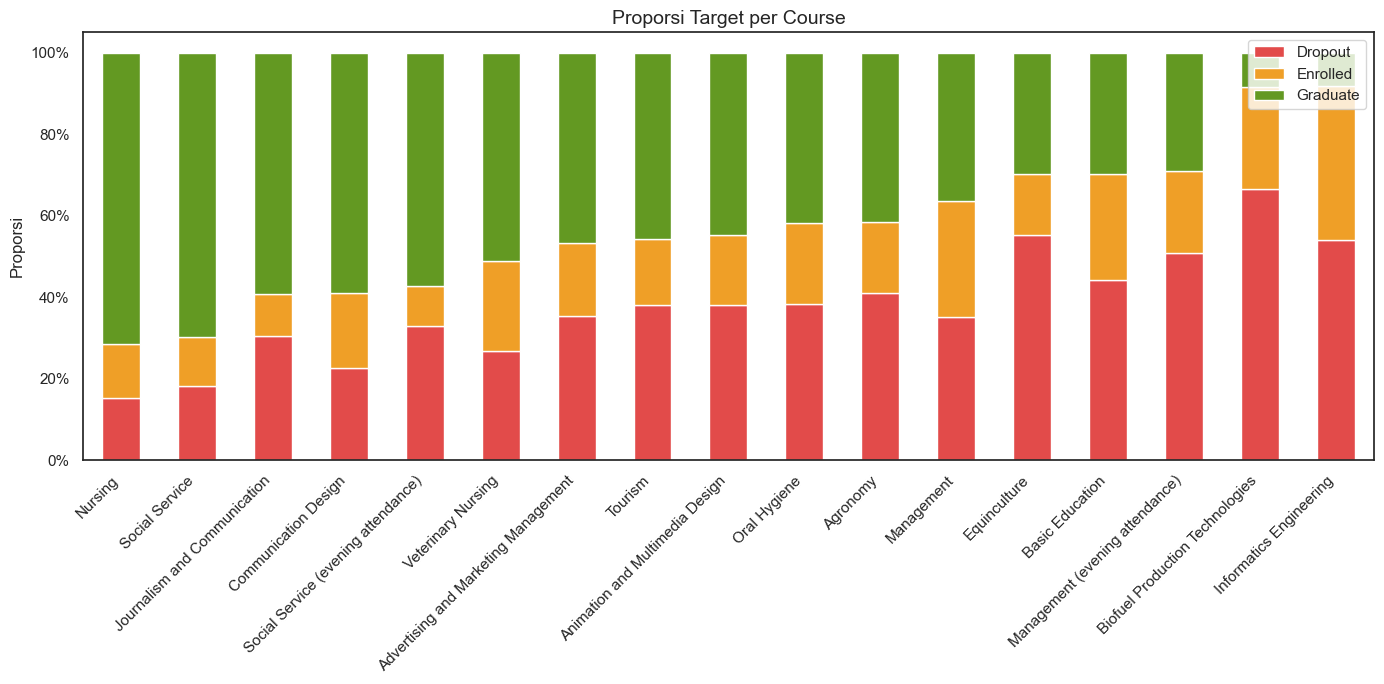

In [161]:
import matplotlib.ticker as mtick
# ============================================================
# EDA 1: PROPORSI TARGET PER COURSE
# ============================================================
course_target = (
    df_final.groupby('Course')['Target']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .sort_values('Graduate', ascending=False)
)

# Tambahkan kolom count untuk context
course_target['n_students'] = df_final.groupby('Course')['Target'].count()

print("=== PROPORSI TARGET PER COURSE (sorted by Graduate%) ===")
print(course_target.round(3).to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
course_target[['Dropout', 'Enrolled', 'Graduate']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#E24B4A', '#EF9F27', '#639922']
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Proporsi Target per Course', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Proporsi')
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [162]:
# ============================================================
# EDA 2: PROPORSI TARGET PER MOTHER'S OCCUPATION
# ============================================================
mom_occ_target = (
    df_final.groupby("Mother's occupation")['Target']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .sort_values('Dropout', ascending=False)
)
mom_occ_target['n_students'] = df_final.groupby("Mother's occupation")['Target'].count()

print("\n=== PROPORSI TARGET PER MOTHER'S OCCUPATION (sorted by Dropout%) ===")
print(mom_occ_target.round(3).to_string())


=== PROPORSI TARGET PER MOTHER'S OCCUPATION (sorted by Dropout%) ===
Target                                                   Dropout  Enrolled  Graduate  n_students
Mother's occupation                                                                             
(blank)                                                    0.765     0.118     0.118          17
Other Situation                                            0.729     0.000     0.271          70
Student                                                    0.688     0.007     0.306         144
Installation/Machine Operators/Assembly Workers            0.417     0.194     0.389          36
Legislative/Executive Directors/Managers                   0.382     0.147     0.471         102
Specialists in Intellectual/Scientific Activities          0.321     0.245     0.434         318
Unskilled Workers                                          0.311     0.167     0.522        1577
Administrative staff                                     

In [163]:
# ============================================================
# EDA 3: PROPORSI TARGET PER FATHER'S OCCUPATION
# ============================================================
dad_occ_target = (
    df_final.groupby("Father's occupation")['Target']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .sort_values('Dropout', ascending=False)
)
dad_occ_target['n_students'] = df_final.groupby("Father's occupation")['Target'].count()

print("\n=== PROPORSI TARGET PER FATHER'S OCCUPATION (sorted by Dropout%) ===")
print(dad_occ_target.round(3).to_string())


=== PROPORSI TARGET PER FATHER'S OCCUPATION (sorted by Dropout%) ===
Target                                                 Dropout  Enrolled  Graduate  n_students
Father's occupation                                                                           
Other Situation                                          0.708     0.000     0.292          65
(blank)                                                  0.684     0.105     0.211          19
Student                                                  0.641     0.023     0.336         128
Meal preparation assistants                              0.500     0.000     0.500           2
Directors of administrative/commercial services          0.500     0.500     0.000           2
Administrative staff                                     0.360     0.192     0.448         386
Legislative/Executive Directors/Managers                 0.358     0.172     0.470         134
Specialists in Intellectual/Scientific Activities        0.355     0.254   

In [164]:

import matplotlib.ticker as mtick

features_to_eda = [
    'Marital status',
    'Application mode', 
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification"
]

fig_data = {}

for feat in features_to_eda:
    proportions = (
        df_final.groupby(feat)['Target']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
        .sort_values('Dropout', ascending=False)
    )
    proportions['n_students'] = df_final.groupby(feat)['Target'].count()
    fig_data[feat] = proportions
    
    print(f"\n{'='*70}")
    print(f"=== PROPORSI TARGET PER {feat.upper()} (sorted by Dropout%) ===")
    print(proportions.round(3).to_string())


=== PROPORSI TARGET PER MARITAL STATUS (sorted by Dropout%) ===
Target             Dropout  Enrolled  Graduate  n_students
Marital status                                            
Legally separated    0.667     0.167     0.167           6
Married              0.472     0.137     0.391         379
Divorced             0.462     0.176     0.363          91
Facto union          0.440     0.120     0.440          25
Single               0.302     0.184     0.514        3919
Widower              0.250     0.500     0.250           4

=== PROPORSI TARGET PER APPLICATION MODE (sorted by Dropout%) ===
Target                                               Dropout  Enrolled  Graduate  n_students
Application mode                                                                            
Ordinance No. 533-A/99, item b2) (Different Plan)      1.000     0.000     0.000           1
Ordinance No. 533-A/99, item b3 (Other Institution)    1.000     0.000     0.000           1
Ordinance No. 612/93    

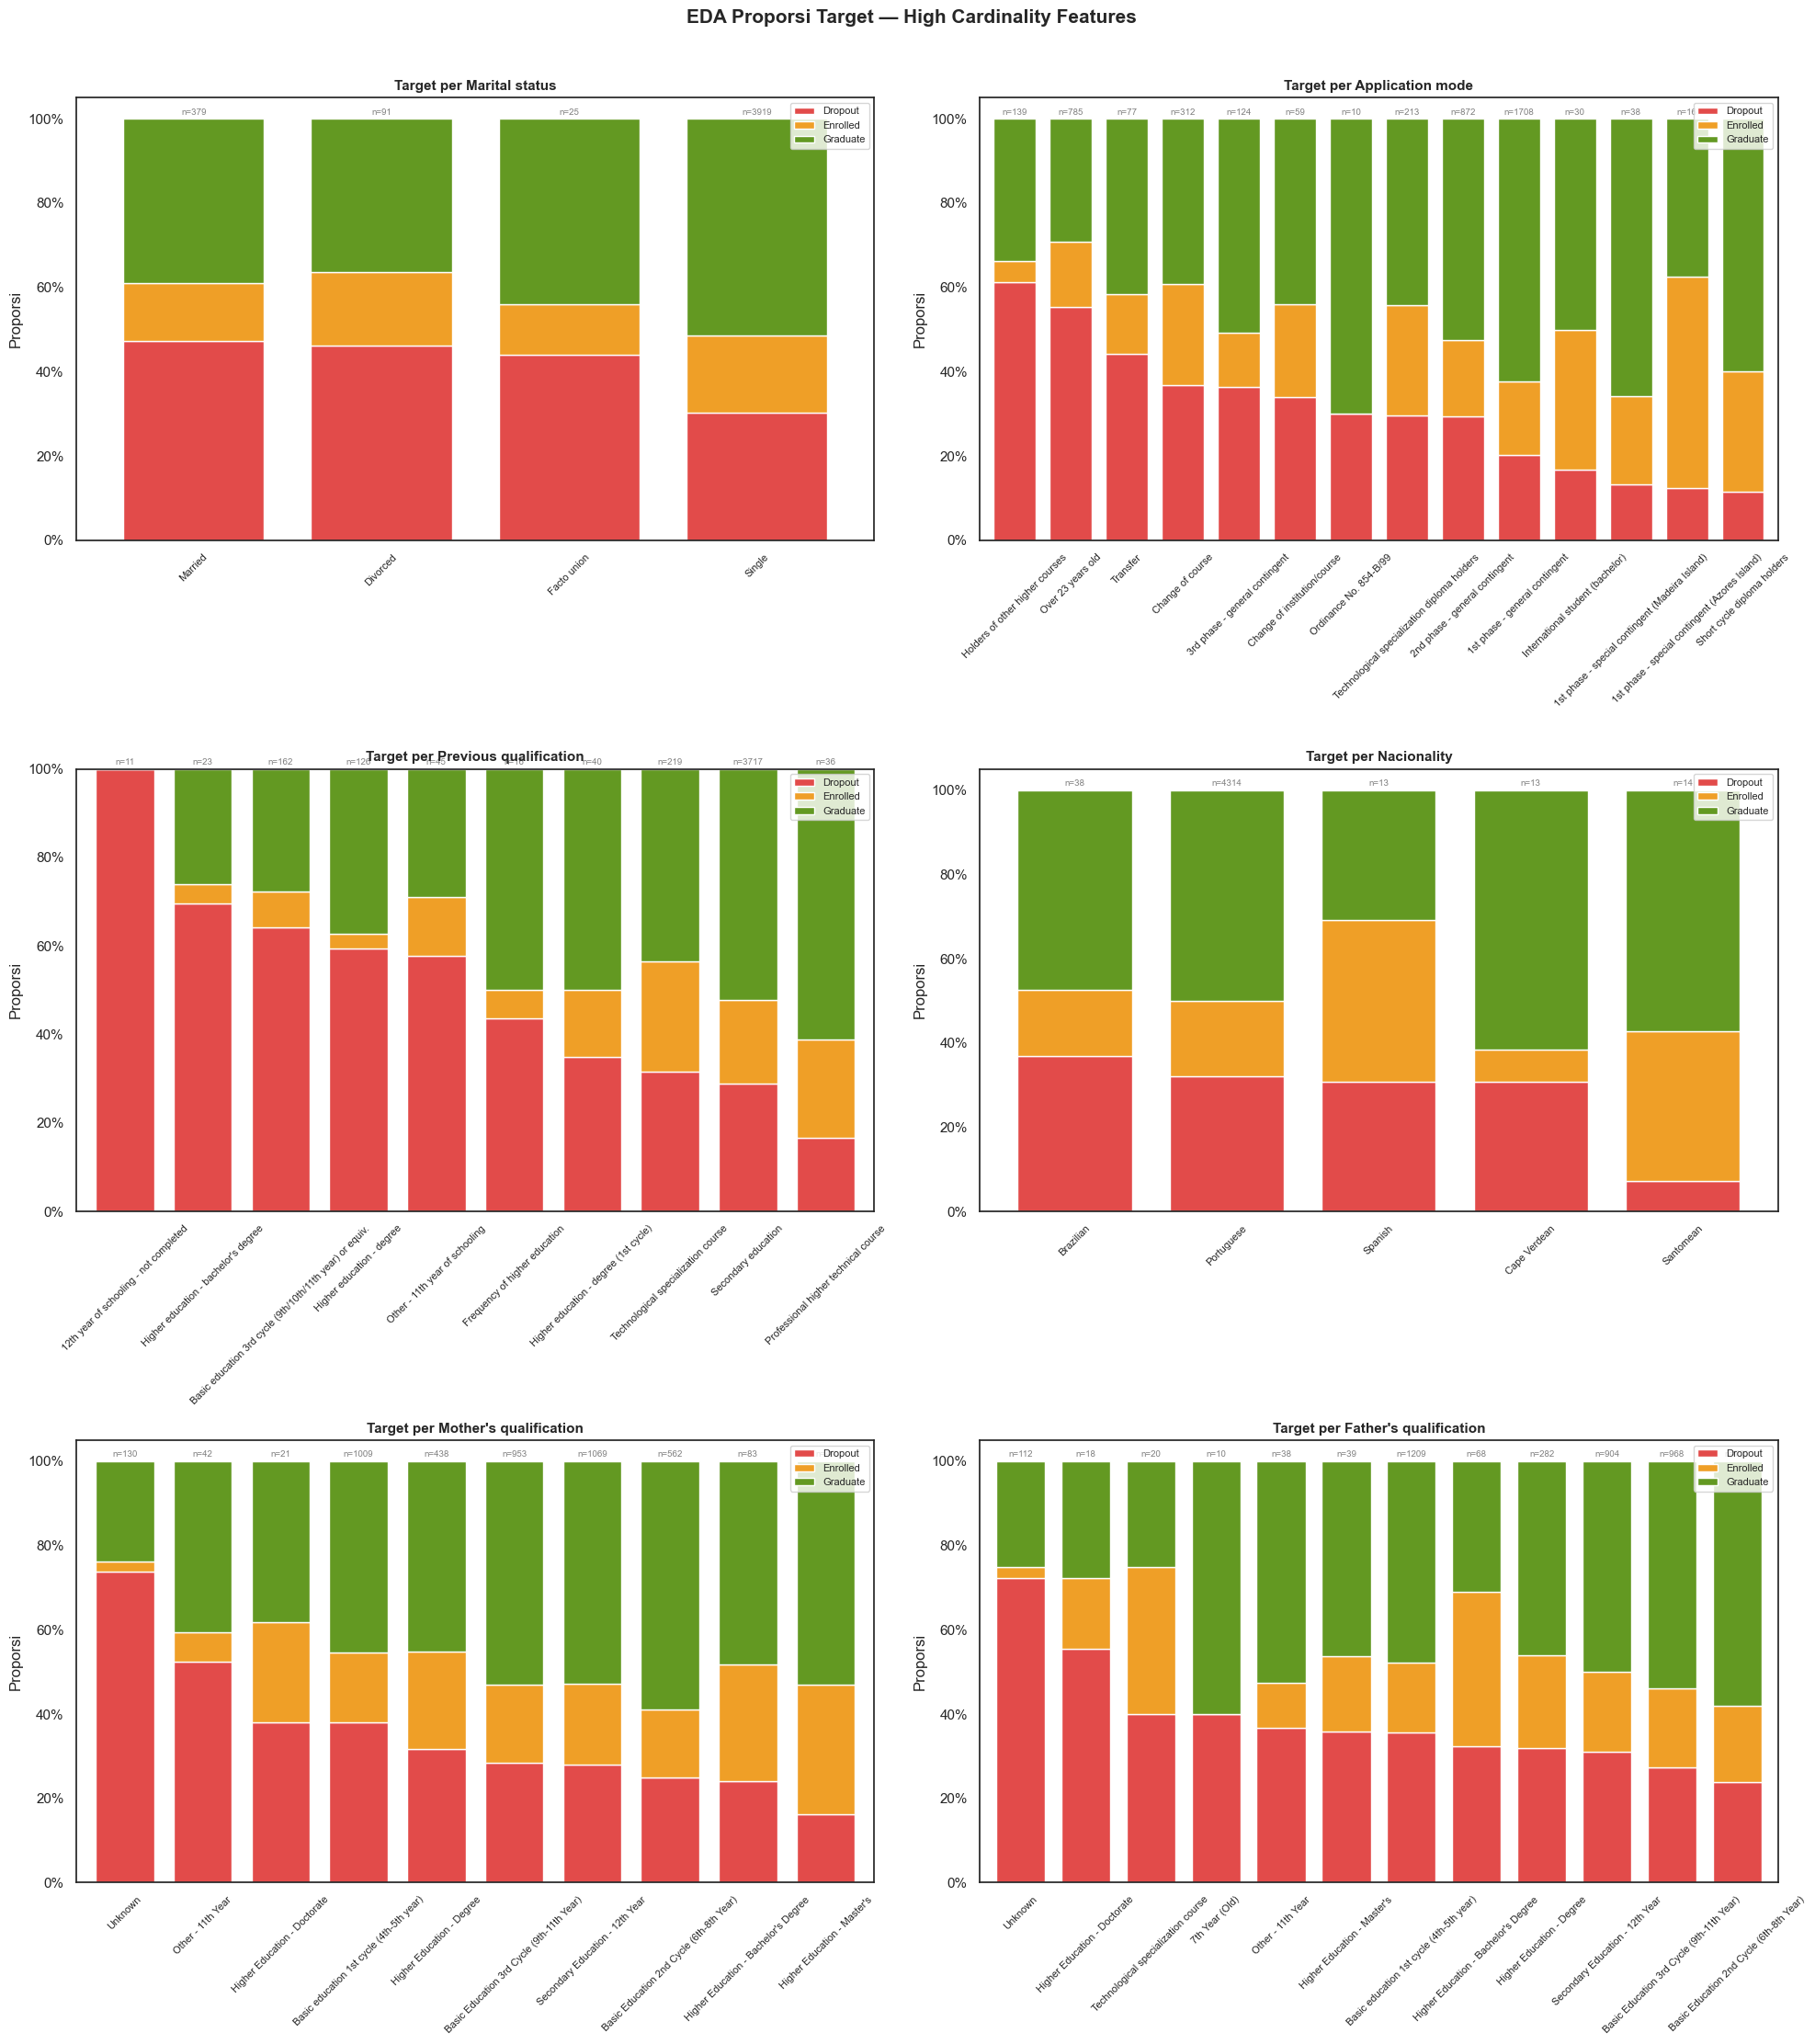

In [165]:
# ============================================================
# VISUALISASI SEMUA SEKALIGUS
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
axes = axes.flatten()

for idx, feat in enumerate(features_to_eda):
    df_plot = fig_data[feat][['Dropout', 'Enrolled', 'Graduate']]
    
    # Filter kategori dengan n < 10 agar tidak noise
    valid_idx = fig_data[feat]['n_students'] >= 10
    df_plot = df_plot[valid_idx]
    
    df_plot.plot(
        kind='bar', stacked=True, ax=axes[idx],
        color=['#E24B4A', '#EF9F27', '#639922'],
        width=0.75
    )
    
    # Tambahkan label n di atas bar
    for i, (label, row) in enumerate(fig_data[feat][valid_idx].iterrows()):
        axes[idx].text(i, 1.01, f"n={int(row['n_students'])}", 
                      ha='center', fontsize=7, color='gray')
    
    axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[idx].set_title(f'Target per {feat}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Proporsi')
    axes[idx].legend(['Dropout', 'Enrolled', 'Graduate'], 
                     loc='upper right', fontsize=8)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('EDA Proporsi Target — High Cardinality Features', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [166]:
# ============================================================
# 1. MARITAL STATUS
# ============================================================
df_final['is_non_single'] = (
    df_final['Marital status'].isin(['Married', 'Divorced', 'Facto union', 'Legally separated'])
).astype(int)
df_final.drop(columns=['Marital status'], inplace=True)

# ============================================================
# 2. APPLICATION MODE
# ============================================================
df_final['is_over23_applicant'] = (
    df_final['Application mode'] == 'Over 23 years old'
).astype(int)

df_final['is_higher_holder_applicant'] = (
    df_final['Application mode'] == 'Holders of other higher courses'
).astype(int)

df_final['is_1st_phase_general'] = (
    df_final['Application mode'] == '1st phase - general contingent'
).astype(int)

df_final.drop(columns=['Application mode'], inplace=True)

# ============================================================
# 3. PREVIOUS QUALIFICATION
# ============================================================
higher_edu_prev = [
    "Higher education - bachelor's degree",
    "Higher education - degree",
    "Higher education - master's",
    "Higher education - doctorate",
    "Higher education - degree (1st cycle)",
    "Higher education - master (2nd cycle)",
    "Frequency of higher education"
]

df_final['prev_qual_has_higher_edu'] = (
    df_final['Previous qualification'].isin(higher_edu_prev)
).astype(int)

df_final['prev_qual_is_secondary'] = (
    df_final['Previous qualification'] == 'Secondary education'
).astype(int)

df_final.drop(columns=['Previous qualification'], inplace=True)

# ============================================================
# 4. NACIONALITY — DROP LANGSUNG
# ============================================================
df_final.drop(columns=['Nacionality'], inplace=True)

# ============================================================
# 5. PARENT QUALIFICATION — Unknown flag + Tier encoding
# ============================================================
edu_tier_map = {
    # Tier 0: basic / tidak ada / unknown
    "Unknown": -1,          # flag tersendiri, tapi tier -1 agar model tangkap
    "Can't read or write": 0,
    "Can read without 4th year": 0,
    "Basic education 1st cycle (4th-5th year)": 1,
    "Basic Education 2nd Cycle (6th-8th Year)": 2,
    "Basic Education 3rd Cycle (9th-11th Year)": 2,
    # Tier 1: secondary
    "Secondary Education - 12th Year": 3,
    "Technological specialization course": 3,
    "Technical-professional course": 3,
    "Professional higher technical course": 3,
    # Tier 2: higher education
    "Higher Education - Bachelor's Degree": 4,
    "Higher Education - Degree": 4,
    "Higher Education - Master's": 5,
    "Higher Education - Master (2nd cycle)": 5,
    "Higher Education - Doctorate": 5,
    "Higher Education - Doctorate (3rd cycle)": 5,
}

for parent in ["Mother's qualification", "Father's qualification"]:
    prefix = 'mother' if 'Mother' in parent else 'father'
    
    # Flag unknown (sinyal terkuat)
    df_final[f'{prefix}_edu_unknown'] = (
        df_final[parent] == 'Unknown'
    ).astype(int)
    
    # Tier encoding (0-5, -1 untuk unknown)
    df_final[f'{prefix}_edu_tier'] = (
        df_final[parent].map(edu_tier_map).fillna(2)  # fallback ke secondary jika tidak ada di map
    )

df_final.drop(columns=["Mother's qualification", "Father's qualification"], inplace=True)

# ============================================================
# 6. FATHER'S OCCUPATION
# ============================================================
df_final['father_occ_highrisk'] = (
    df_final["Father's occupation"].isin(['Student', 'Other Situation'])
).astype(int)

df_final.drop(columns=["Father's occupation"], inplace=True)

# ============================================================
# VERIFIKASI
# ============================================================
new_flags = [
    'is_non_single', 'is_over23_applicant', 'is_higher_holder_applicant',
    'is_1st_phase_general', 'prev_qual_has_higher_edu', 'prev_qual_is_secondary',
    'mother_edu_unknown', 'mother_edu_tier', 'father_edu_unknown', 
    'father_edu_tier', 'father_occ_highrisk'
]

print("=== DISTRIBUSI FLAG BARU ===")
for col in new_flags:
    vc = df_final[col].value_counts()
    print(f"{col}: {dict(vc)}")

=== DISTRIBUSI FLAG BARU ===
is_non_single: {0: np.int64(3923), 1: np.int64(501)}
is_over23_applicant: {0: np.int64(3639), 1: np.int64(785)}
is_higher_holder_applicant: {0: np.int64(4285), 1: np.int64(139)}
is_1st_phase_general: {0: np.int64(2716), 1: np.int64(1708)}
prev_qual_has_higher_edu: {0: np.int64(4204), 1: np.int64(220)}
prev_qual_is_secondary: {1: np.int64(3717), 0: np.int64(707)}
mother_edu_unknown: {0: np.int64(4294), 1: np.int64(130)}
mother_edu_tier: {2.0: np.int64(1601), 3.0: np.int64(1082), 1.0: np.int64(1009), 4.0: np.int64(521), -1.0: np.int64(130), 5.0: np.int64(75), 0.0: np.int64(6)}
father_edu_unknown: {0: np.int64(4312), 1: np.int64(112)}
father_edu_tier: {2.0: np.int64(1754), 1.0: np.int64(1209), 3.0: np.int64(929), 4.0: np.int64(350), -1.0: np.int64(112), 5.0: np.int64(60), 0.0: np.int64(10)}
father_occ_highrisk: {0: np.int64(4231), 1: np.int64(193)}


In [167]:
# Bersihkan sisa
cols_to_drop = [
    "Mother's occupation",               # sudah digantikan flags is_nursing/is_mgmt/is_high_drop
    'is_non_single',
    'father_occ_highrisk',
    'mother_edu_tier',
    'father_edu_tier',
    'is_mgmt',
    'is_higher_holder_applicant',
    "Course"
]


df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Shape final: {df_final.shape}")
print(f"\nFitur tersisa:\n{df_final.columns.tolist()}")

Shape final: (4424, 36)

Fitur tersisa:
['Previous qualification (grade)', 'Admission grade', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Pass_Rate_Sem1', 'Pass_Rate_Sem2', 'Grade_Trend', 'Approved_Units_Trend', 'Financial_Stress_Index', 'Total_Failed_Units', 'Vulnerability_Score', 'Zero_Approval_Sem2_Flag', 'Academic_Financial_Efficiency', 'Quality_Credit_Load', 'Scholarship_Performance_Boost', 'Adjusted_Academic_Success', 'Academic_Ambiguity', 'Self_Funded_Lunas', 'Self_Funded_Academic_Pace', 'Academic_Fatigue_Index', 'Evaluation_Efficiency_Sem2', 'Evaluation_Efficiency_Sem1', 'is_enrolled_trend', 'Target', 'is_over23_applicant', 'is_1st_phase_general', 'prev_qual_has_higher_edu', 'prev_qual_is_secondary', 'mother_edu_unknown', 'father_edu_unknown']


In [168]:


# ============================================================
# 1. COPY & ENCODE TARGET
# ============================================================
df_corr = df_final.copy()

target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr['Target'] = df_corr['Target'].replace(target_mapping)
df_corr['Target'] = pd.to_numeric(df_corr['Target'], errors='coerce')

# ============================================================
# 2. CEK SISA KOLOM NON-NUMERIK
# ============================================================
numeric_cols = df_corr.select_dtypes(include='number').columns.tolist()
non_numeric  = [c for c in df_corr.columns if c not in numeric_cols]

print("=== KOLOM NON-NUMERIK YANG TERSISA ===")
for c in non_numeric:
    print(f"  {c}: {df_corr[c].nunique()} unique → {df_corr[c].unique()[:5]}")
    
# ============================================================
# 3. ENCODE SISA KATEGORIKAL
#    (setelah semua flag & tier dibuat, harusnya sudah sedikit)
# ============================================================
remaining_cat = [c for c in non_numeric if c != 'Target']

if remaining_cat:
    # Low cardinality (≤ 5): OHE drop_first
    low_card  = [c for c in remaining_cat if df_corr[c].nunique() <= 5]
    # High cardinality (> 5): frequency encoding sebagai fallback
    high_card = [c for c in remaining_cat if df_corr[c].nunique() > 5]

    if low_card:
        print(f"\nOHE untuk: {low_card}")
        df_corr = pd.get_dummies(df_corr, columns=low_card, 
                                  drop_first=True, dtype=int)

    if high_card:
        print(f"\nFrequency encoding untuk: {high_card}")
        for c in high_card:
            freq = df_corr[c].value_counts(normalize=True)
            df_corr[c] = df_corr[c].map(freq)
else:
    print("Semua kolom sudah numerik.")
    
# ============================================================
# 4. PASTIKAN SEMUA NUMERIK & TIDAK ADA NaN EKSTREM
# ============================================================
df_corr = df_corr.select_dtypes(include='number')

# Cek NaN
nan_summary = df_corr.isnull().sum()
nan_cols = nan_summary[nan_summary > 0]
if len(nan_cols) > 0:
    print(f"\n⚠ Kolom dengan NaN:\n{nan_cols}")
    df_corr = df_corr.fillna(df_corr.median())
else:
    print(f"\n✓ Tidak ada NaN. Shape: {df_corr.shape}")
    
    
# ============================================================
# 5. HITUNG SPEARMAN CORRELATION
# ============================================================
n_features = df_corr.shape[1] - 1
print(f"\nMenghitung Spearman Correlation untuk {n_features} fitur...\n")

corr_matrix = df_corr.corr(method='spearman')

# ============================================================
# 6. TOP 10 POSITIF & NEGATIF TERHADAP TARGET
# ============================================================
target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=False)

print("=== TOP 10 KORELASI POSITIF KE TARGET ===")
print(target_corr.head(10).round(3).to_string())

print("\n=== TOP 10 KORELASI NEGATIF KE TARGET ===")
print(target_corr.tail(10).round(3).to_string())


=== KOLOM NON-NUMERIK YANG TERSISA ===
  Displaced: 2 unique → <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  Gender: 2 unique → <StringArray>
['Male', 'Female']
Length: 2, dtype: str

OHE untuk: ['Displaced', 'Gender']

✓ Tidak ada NaN. Shape: (4424, 36)

Menghitung Spearman Correlation untuk 35 fitur...

=== TOP 10 KORELASI POSITIF KE TARGET ===
Academic_Financial_Efficiency       0.722
Pass_Rate_Sem2                      0.705
Adjusted_Academic_Success           0.704
Scholarship_Performance_Boost       0.686
Evaluation_Efficiency_Sem2          0.684
Quality_Credit_Load                 0.676
Pass_Rate_Sem1                      0.643
Evaluation_Efficiency_Sem1          0.625
Curricular units 2nd sem (grade)    0.560
Curricular units 1st sem (grade)    0.497

=== TOP 10 KORELASI NEGATIF KE TARGET ===
mother_edu_unknown        -0.127
Academic_Ambiguity        -0.201
is_over23_applicant       -0.227
Gender_Male               -0.230
Debtor                    -0.239
Age at enrollment

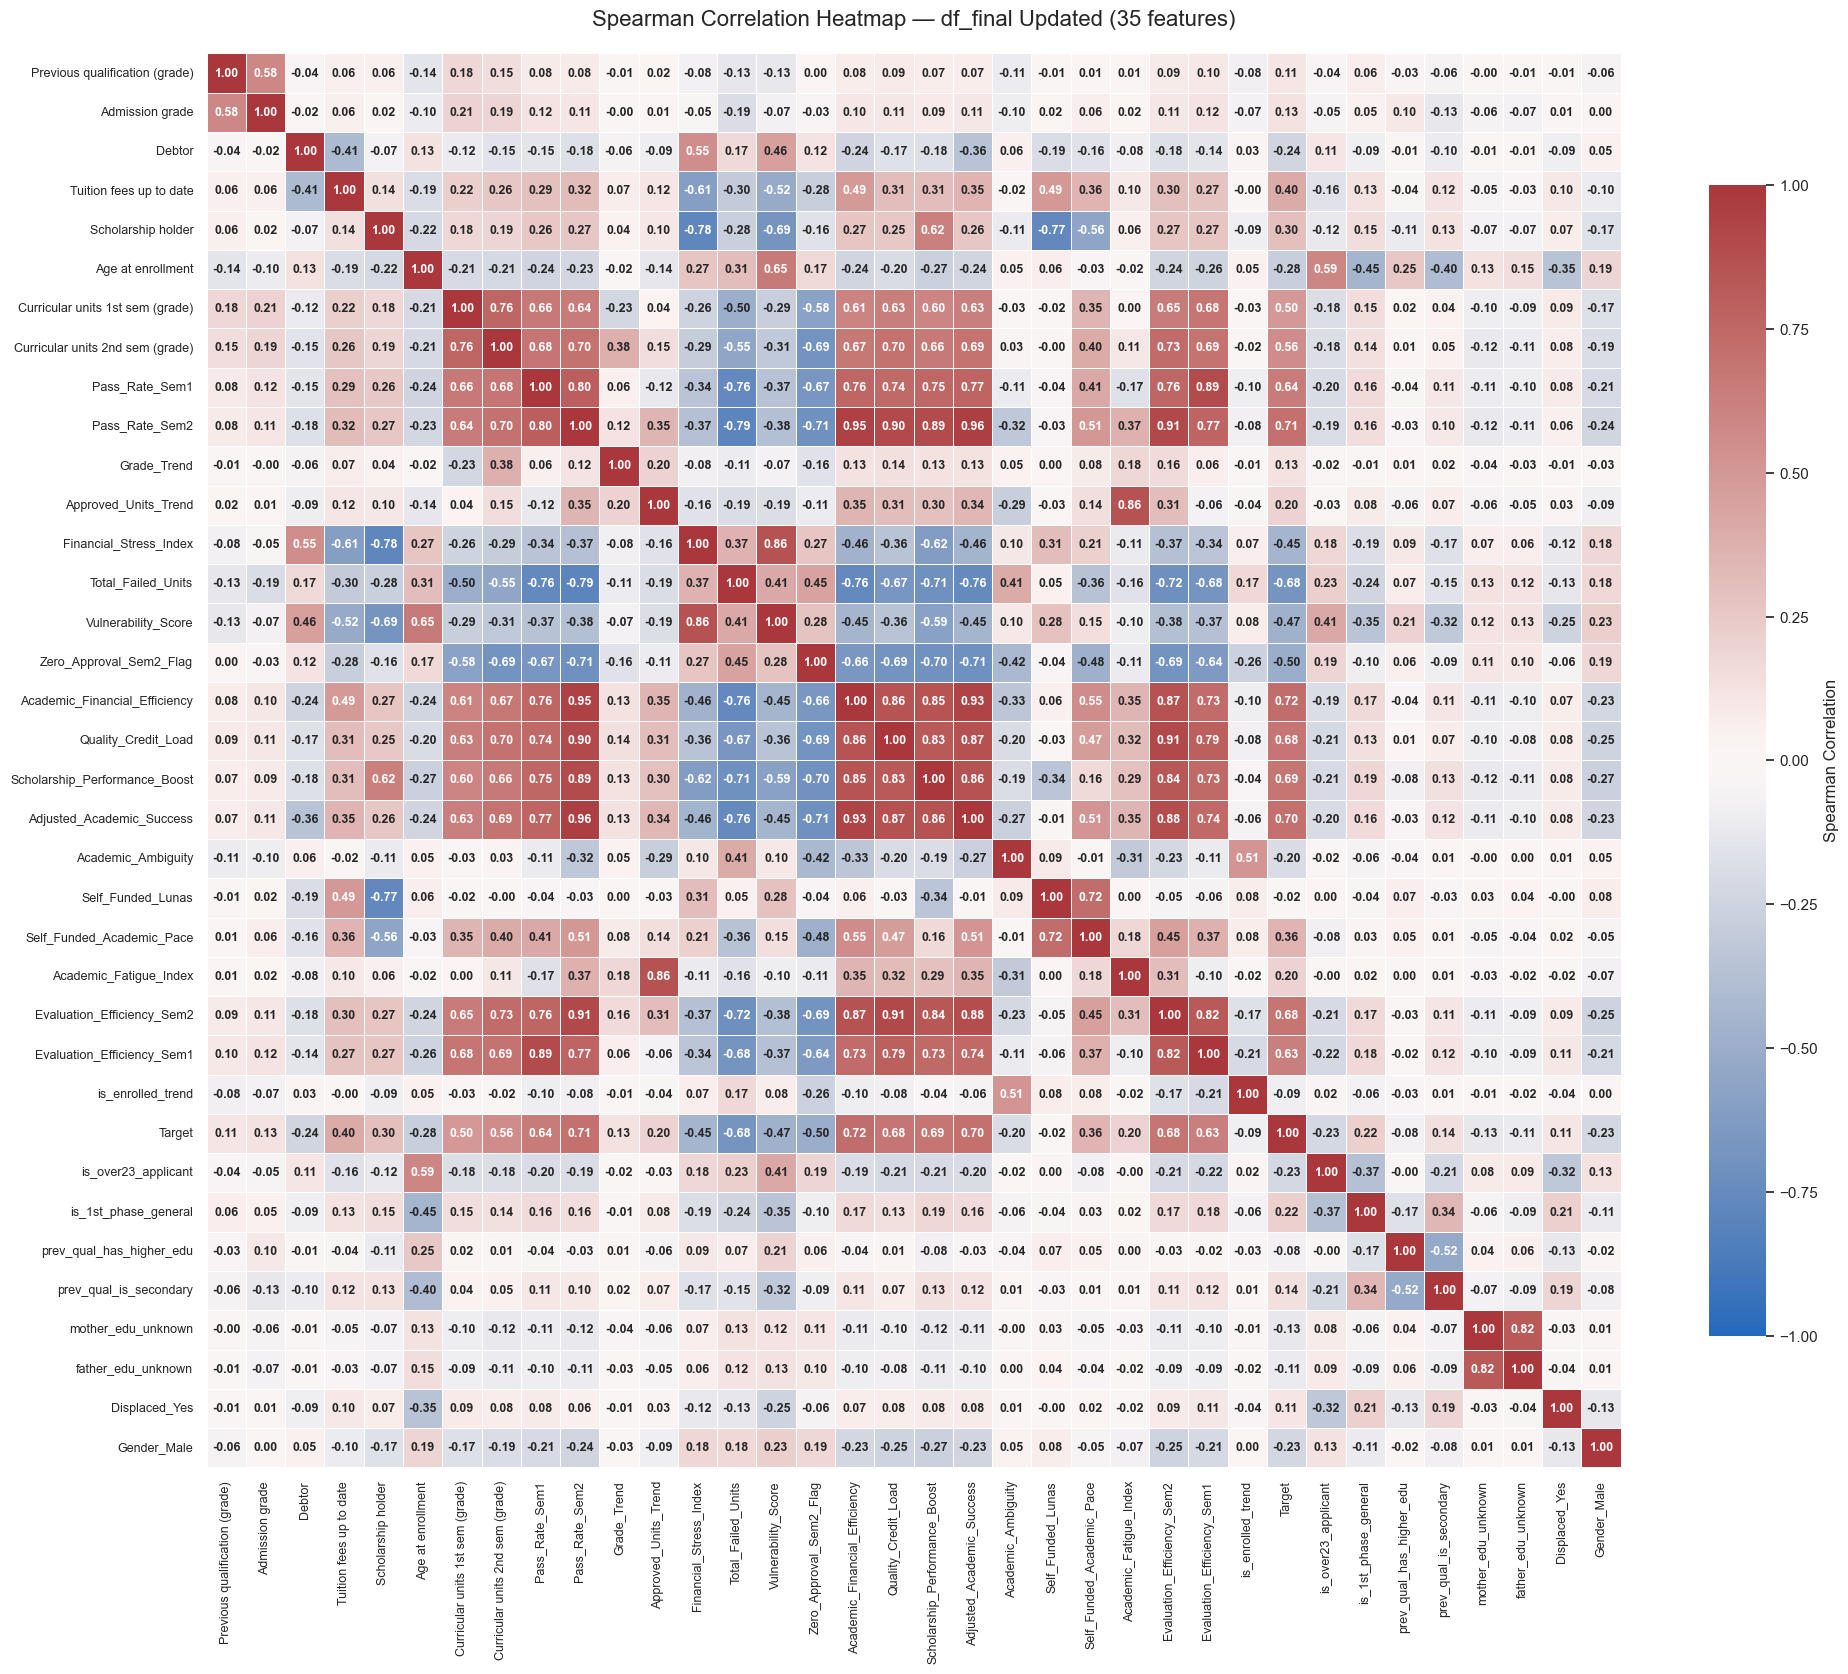


✓ Heatmap disimpan sebagai 'spearman_heatmap_updated.png'


In [169]:
# ============================================================
# 7. HEATMAP — ukuran adaptif berdasarkan jumlah fitur
# ============================================================
n = df_corr.shape[1]
fig_size = max(20, n * 0.55)  # scale otomatis

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"weight": "bold", "size": max(8, 12 - n // 10)},
    cmap="vlag",
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .6, "label": "Spearman Correlation"},
    ax=ax
)

ax.set_title(
    f'Spearman Correlation Heatmap — df_final Updated ({n_features} features)',
    fontsize=16, pad=20
)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('spearman_heatmap_updated.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Heatmap disimpan sebagai 'spearman_heatmap_updated.png'")

In [170]:
df_final.columns

Index(['Previous qualification (grade)', 'Admission grade', 'Displaced',
       'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (grade)', 'Pass_Rate_Sem1', 'Pass_Rate_Sem2',
       'Grade_Trend', 'Approved_Units_Trend', 'Financial_Stress_Index',
       'Total_Failed_Units', 'Vulnerability_Score', 'Zero_Approval_Sem2_Flag',
       'Academic_Financial_Efficiency', 'Quality_Credit_Load',
       'Scholarship_Performance_Boost', 'Adjusted_Academic_Success',
       'Academic_Ambiguity', 'Self_Funded_Lunas', 'Self_Funded_Academic_Pace',
       'Academic_Fatigue_Index', 'Evaluation_Efficiency_Sem2',
       'Evaluation_Efficiency_Sem1', 'is_enrolled_trend', 'Target',
       'is_over23_applicant', 'is_1st_phase_general',
       'prev_qual_has_higher_edu', 'prev_qual_is_secondary',
       'mother_edu_unknown', 'father_edu_unknown'],
      dtype='str')

In [171]:
gender_map = {'Male': 1, 'Female': 0}
df_final['Gender'] = df_final['Gender'].map(gender_map)

displace_map = {'Yes': 1, 'No': 0}
df_final['Displaced'] = df_final['Displaced'].map(displace_map) 

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_final['Target'] = df_final['Target'].map(target_map)

print(df_final[['Gender', 'Displaced', 'Target']].head())



   Gender  Displaced  Target
0       1          1       0
1       1          1       2
2       1          1       0
3       0          1       2
4       0          0       2


In [172]:

df_final.to_csv('df_final2.csv', index=False)
